# Clustering Musical Styles via Audio Similarity and Uncovering Lyrical Themes


## Social Graphs and Interactions (02805) - Final Project Assignment

### Group 37

| Parts                    | Contributor                     |
| ------------------------ | ------------------------------- |
| Part 1: Data Cleaning    | Vasiliki Tsanaktsidou (s232489) |
| Part 2: Network Analysis | Arun Kumar Dhuraisamy (s242529) |
| Part 3: Text Analysis    | Adam Ajane (s211048)            |


## Introduction

Music conveys meaning through both sound and language. In Parts 1 and 2 of this project, we constructed an audio similarity network based on nine Spotify audio features (danceability, energy, loudness, speechiness, acousticness, instrumentalness, liveness, valence, and tempo) and identified communities of sonically similar genres using the Louvain algorithm. But do genres that _sound_ similar also _talk about_ similar things?

This section extends our network analysis by examining whether the audio-based communities we discovered also share **thematic and emotional patterns** in their lyrics. Music recommendation systems and genre labels often assume that songs categorized together are acoustically and thematically similar, but this assumption rarely holds in practice. By analyzing the lyrical content within our emergent audio communities, we can test whether sonic similarity correlates with semantic similarity.

## Project Overview

Our analysis follows three main phases:

1. **Data Cleaning (Part 1)**: We processed ~114,000 Spotify tracks, removing duplicates and validating audio features to yield 73,403 unique tracks. Features were standardized and reduced via PCA to 5 components explaining ~82% of variance.

2. **Network Analysis (Part 2)**: We constructed a k-nearest neighbors similarity graph (k=10) and applied Louvain community detection to identify clusters of sonically similar genres.

3. **Text Analysis (Part 3)**: We scrape and analyze lyrics from each audio community to explore thematic patterns using TF-IDF and emotional tone using VADER sentiment analysis.


## Imports


In [12]:
# Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch   
import seaborn as sns
from pathlib import Path
import json
import time
import string
import re
import os
import nltk
import random
import scipy.sparse as sp
import random
import itertools
import warnings
warnings.filterwarnings('ignore')  


# Network and text analysis
import networkx as nx
import powerlaw
from networkx.algorithms.community import louvain_communities, modularity
from networkx.algorithms.community.quality import modularity
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.feature_extraction.text import TfidfVectorizer
from collections import Counter
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from IPython.display import display
from PIL import Image
from fa2_modified import ForceAtlas2


# Genius API
# from lyricsgenius import Genius

# Word clouds
# from wordcloud import WordCloud

# Plotting settings
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

## Configurations


In [26]:
# Paths
DATA_PATH_CLEANING = "data/spotify_tracks_dataset.csv"
DATA_PATH = "data/clean_spotify_tracks_dataset.csv"
GEXF_PATH_TRACK= "data/spotify_knn_k10_removed_same_tracks.gexf"
GEXF_PATH = "data/spotify_genre_similarity_audio.gexf"
ENV_PATH = "../.env.local"

# Random seed for reproducibility
RANDOM_SEED = 42

# Sampling parameters
N_GENRES_PER_COMMUNITY = 10
SONGS_PER_GENRE = 50

# Genre filtering thresholds
MIN_TRACKS_PER_GENRE = 50
MAX_INSTRUMENTALNESS = 0.6

# Language filtering (strict: requires language='en', skips if missing)
ENGLISH_ONLY = True

# Word cloud parameters
WORDCLOUD_MAX_WORDS = 50

# Output directories
OUTPUT_DIR_CLEANING = Path("data")
OUTPUT_DIR = Path("data") / "text_analysis_output"
LYRICS_DIR = OUTPUT_DIR / "lyrics_by_community"
SAMPLES_DIR = OUTPUT_DIR / "song_samples"

# Create output directories
LYRICS_DIR.mkdir(parents=True, exist_ok=True)
SAMPLES_DIR.mkdir(parents=True, exist_ok=True)

# Set random seeds
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

print("Configuration loaded")
print(f"  Random seed: {RANDOM_SEED}")
print(f"  Genres per community: {N_GENRES_PER_COMMUNITY}")
print(f"  Songs per genre: {SONGS_PER_GENRE}")
print(f"  Min tracks per genre: {MIN_TRACKS_PER_GENRE}")
print(f"  Max instrumentalness: {MAX_INSTRUMENTALNESS}")
print(f"  English only (strict): {ENGLISH_ONLY}")
print(f"  Output: {OUTPUT_DIR}")

Configuration loaded
  Random seed: 42
  Genres per community: 10
  Songs per genre: 50
  Min tracks per genre: 50
  Max instrumentalness: 0.6
  English only (strict): True
  Output: data\text_analysis_output


# Part 1: Spotify Audio Features, Data Cleaning, Thresholding and Graph Export

This section contains the **preliminary data work** for our project: we take a large Spotify dataset, clean and standardize the audio features, and then build an audio-similarity graph that will later be combined with lyrical analysis.

Concretely, this notebook:

1. **Loads and inspects** the raw Spotify dataset (~114k tracks).
2. **Cleans and deduplicates** tracks to obtain a set of unique songs.
3. **Selects and validates** nine core audio features: _danceability, energy, loudness, speechiness, acousticness, instrumentalness, liveness, valence, tempo._
4. **Standardizes** features and explores their distributions and correlations.
5. **Performs PCA** to obtain a low-dimensional representation for similarity computation.
6. **Constructs k-nearest-neighbour (kNN) graphs** and compares three thresholding strategies:
   - Standard kNN
   - Radius (similarity τ) graphs
   - Mutual kNN
7. **Selects a final thresholding scheme** (standard kNN with k = 10) and exports the resulting song–song network as a GEXF file.


## 1. Load Raw Data & Overview


In [ ]:
# Load raw data & basic overview

df_raw = pd.read_csv(DATA_PATH)

print("Raw shape:", df_raw.shape)
print("\nColumns:\n", df_raw.columns.tolist())

print("\nDtypes:\n", df_raw.dtypes)

print("\nMissing values per column:\n", df_raw.isna().sum())

# Show first few rows
df_raw.head()

Raw shape: (114000, 21)

Columns:
 ['Unnamed: 0', 'track_id', 'artists', 'album_name', 'track_name', 'popularity', 'duration_ms', 'explicit', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature', 'track_genre']

Dtypes:
 Unnamed: 0            int64
track_id             object
artists              object
album_name           object
track_name           object
popularity            int64
duration_ms           int64
explicit               bool
danceability        float64
energy              float64
key                   int64
loudness            float64
mode                  int64
speechiness         float64
acousticness        float64
instrumentalness    float64
liveness            float64
valence             float64
tempo               float64
time_signature        int64
track_genre          object
dtype: object

Missing values per column:
 Unnamed: 0          0
track_id            0
arti

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


## 2. Deduplication & Cleaning

The raw dataset contains multiple sources of duplication and noise.
Before constructing any similarity network, we need to make sure
that:

- each row corresponds to a **unique song**, and
- all selected audio features are **numerically valid** and within
  Spotify’s expected ranges.

We focus on the nine audio features that will drive the similarity
network:

- `danceability`, `energy`, `loudness`, `speechiness`,  
  `acousticness`, `instrumentalness`, `liveness`, `valence`, `tempo`.

The cleaning has three main parts:

1. **Deduplication**

   - First remove duplicate `track_id` (keeping the most popular version).
   - Then apply a fallback deduplication based on normalized  
     (`artists`, `track_name`, `album_name`) to catch near-duplicates.

2. **Range filtering**

   - Enforce `[0, 1]` for bounded features (danceability, energy, etc.).
   - Restrict `loudness` to `[-60, 0]` dB.
   - Restrict `tempo` to `(0, 250]` BPM.

3. **Missing values**
   - Drop any row with missing values in the nine selected features.

The result is a **clean audio-feature matrix** that is suitable for standardization, PCA, and kNN graph construction.


In [ ]:
# Deduplication & audio feature cleaning

KEEP = [
    "danceability",
    "energy",
    "loudness",
    "speechiness",
    "acousticness",
    "instrumentalness",
    "liveness",
    "valence",
    "tempo",
]

df = df_raw.copy()
print("Starting from:", df.shape)

# Deduplicate on track_id, keeping highest popularity ---
if "track_id" in df.columns:
    if "popularity" in df.columns:
        df = df.sort_values("popularity", ascending=False)
    before = df.shape[0]
    df = df.drop_duplicates(subset=["track_name"], keep="first")
    df = df.drop_duplicates(subset=["track_id"], keep="first")

    print(f"After track_id dedupe: {df.shape} (removed {before - df.shape[0]})")

# Fallback dedupe on normalized (artists, track_name, album_name) ---
import re


def norm_text(s):
    s = str(s).lower()
    s = re.sub(r"[^\w\s]+", " ", s)
    s = re.sub(r"\s+", " ", s).strip()
    return s


for col in ["artists", "track_name", "album_name"]:
    if col in df.columns:
        df[f"norm_{col}"] = df[col].map(norm_text)

keys = [
    c for c in ["norm_artists", "norm_track_name", "norm_album_name"] if c in df.columns
]
if keys:
    before = df.shape[0]
    df = df.drop_duplicates(subset=keys, keep="first")
    print(f"After fallback dedupe: {df.shape} (removed {before - df.shape[0]})")

# Drop helper cols
df = df.drop(columns=[c for c in df.columns if c.startswith("norm_")])

print("\nShape after deduplication:", df.shape)

Starting from: (114000, 21)
After track_id dedupe: (73609, 21) (removed 40391)
After fallback dedupe: (73595, 24) (removed 14)

Shape after deduplication: (73595, 21)


In [ ]:
# How many track_names appear with multiple different track_ids?
name_counts = df.groupby("track_name")["track_id"].nunique()
print(f"Unique track names: {len(name_counts)}")
print(f"Names with multiple track_ids: {(name_counts > 1).sum()}")
print(f"Distribution:\n{name_counts.value_counts().head(10)}")

Unique track names: 73594
Names with multiple track_ids: 0
Distribution:
track_id
1    73594
Name: count, dtype: int64


## 3. Audio Feature Selection & Range Filtering


In [ ]:
# Select & clean audio features

# Check that all KEEP columns exist
missing = [c for c in KEEP if c not in df.columns]
if missing:
    raise ValueError(f"Missing required audio feature columns: {missing}")

# Extract audio features
X = df[KEEP].copy()

# Coerce to numeric
X = X.apply(pd.to_numeric, errors="coerce")

print("Shape after selecting audio features:", X.shape)

# --- 3.1 Range sanity checks ---
bounded = [
    "danceability",
    "energy",
    "speechiness",
    "acousticness",
    "instrumentalness",
    "liveness",
    "valence",
]

before = X.shape[0]
for col in bounded:
    X = X[(X[col] >= 0.0) & (X[col] <= 1.0)]
print(f"Filtered {before - X.shape[0]} rows outside [0,1] for bounded features.")

before = X.shape[0]
X = X[(X["loudness"] >= -60.0) & (X["loudness"] <= 0.0)]
print(f"Filtered {before - X.shape[0]} rows by loudness range [-60, 0].")

before = X.shape[0]
X = X[(X["tempo"] > 0) & (X["tempo"] <= 250)]
print(f"Filtered {before - X.shape[0]} rows by tempo range (0, 250].")

# Align df to surviving rows
df = df.loc[X.index]

# Drop any remaining NaNs
before = X.shape[0]
X = X.dropna(axis=0, how="any")
df = df.loc[X.index]
print(f"Dropped {before - X.shape[0]} rows with NaNs.")

print("\nFinal cleaned audio feature matrix:", X.shape)
print(X.describe())

Shape after selecting audio features: (73595, 9)
Filtered 0 rows outside [0,1] for bounded features.
Filtered 54 rows by loudness range [-60, 0].
Filtered 138 rows by tempo range (0, 250].
Dropped 0 rows with NaNs.

Final cleaned audio feature matrix: (73403, 9)
       danceability        energy      loudness   speechiness  acousticness  \
count  73403.000000  73403.000000  73403.000000  73403.000000  73403.000000   
mean       0.559668      0.637805     -8.580963      0.090114      0.330057   
std        0.176755      0.257315      5.277029      0.118627      0.338976   
min        0.051300      0.000020    -46.591000      0.022100      0.000000   
25%        0.446000      0.460000    -10.427000      0.036200      0.016300   
50%        0.573000      0.680000     -7.252000      0.049400      0.193000   
75%        0.690000      0.858000     -5.140000      0.088300      0.628000   
max        0.985000      1.000000     -0.001000      0.965000      0.996000   

       instrumentalness  

## 4. Standardization


In [ ]:
# Standardize features (z-score)

scaler = StandardScaler()
X_std = scaler.fit_transform(X)

X_std_df = pd.DataFrame(X_std, index=X.index, columns=KEEP)

print("Standardized matrix shape:", X_std_df.shape)
X_std_df.head()

Standardized matrix shape: (73403, 9)


,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo
20001,0.873148,-0.644368,0.228532,-0.031306,-0.935345,-0.550873,0.217779,-0.874363,0.296383
51664,0.346991,0.560388,0.574752,-0.388732,-0.936820,-0.450727,0.038520,0.310357,0.192471
81210,0.007535,1.271582,0.930068,-0.470501,-0.962397,-0.550865,0.740617,-0.623749,0.192706
89411,1.557717,0.160098,0.616253,-0.452798,0.746203,-0.550880,-0.021233,1.449510,0.089736
68305,1.987695,0.288346,0.658702,-0.070926,-0.707893,-0.550805,-0.642165,-0.164291,-1.019885


## 5. Exploratory Plots

Before moving to PCA and graph construction, we briefly inspect the
distribution and relationships of the nine audio features.

We include three types of plots:

1. **Histograms of each feature**

   - Show whether features are skewed (e.g. many tracks with low
     instrumentalness).
   - Helps to spot anomalies or extreme outliers that could distort
     similarity.

2. **Correlation heatmap**

   - Reveals relationships such as:
     - strong negative correlation between `energy` and `acousticness`,
     - negative correlation between `loudness` and `acousticness`,
     - moderate positive link between `energy` and `loudness`.
   - This justifies using a multivariate method (PCA) instead of
     treating each feature independently.

3. **Top 20 genres by track count**
   - Gives an overview of how genres are distributed in the cleaned
     dataset.
   - Confirms that we have a broad variety of styles rather than a
     single dominant genre.

These plots are mainly used in the **Results** section of the paper
to describe the dataset and motivate the modeling choices.


### 5.1 Histograms


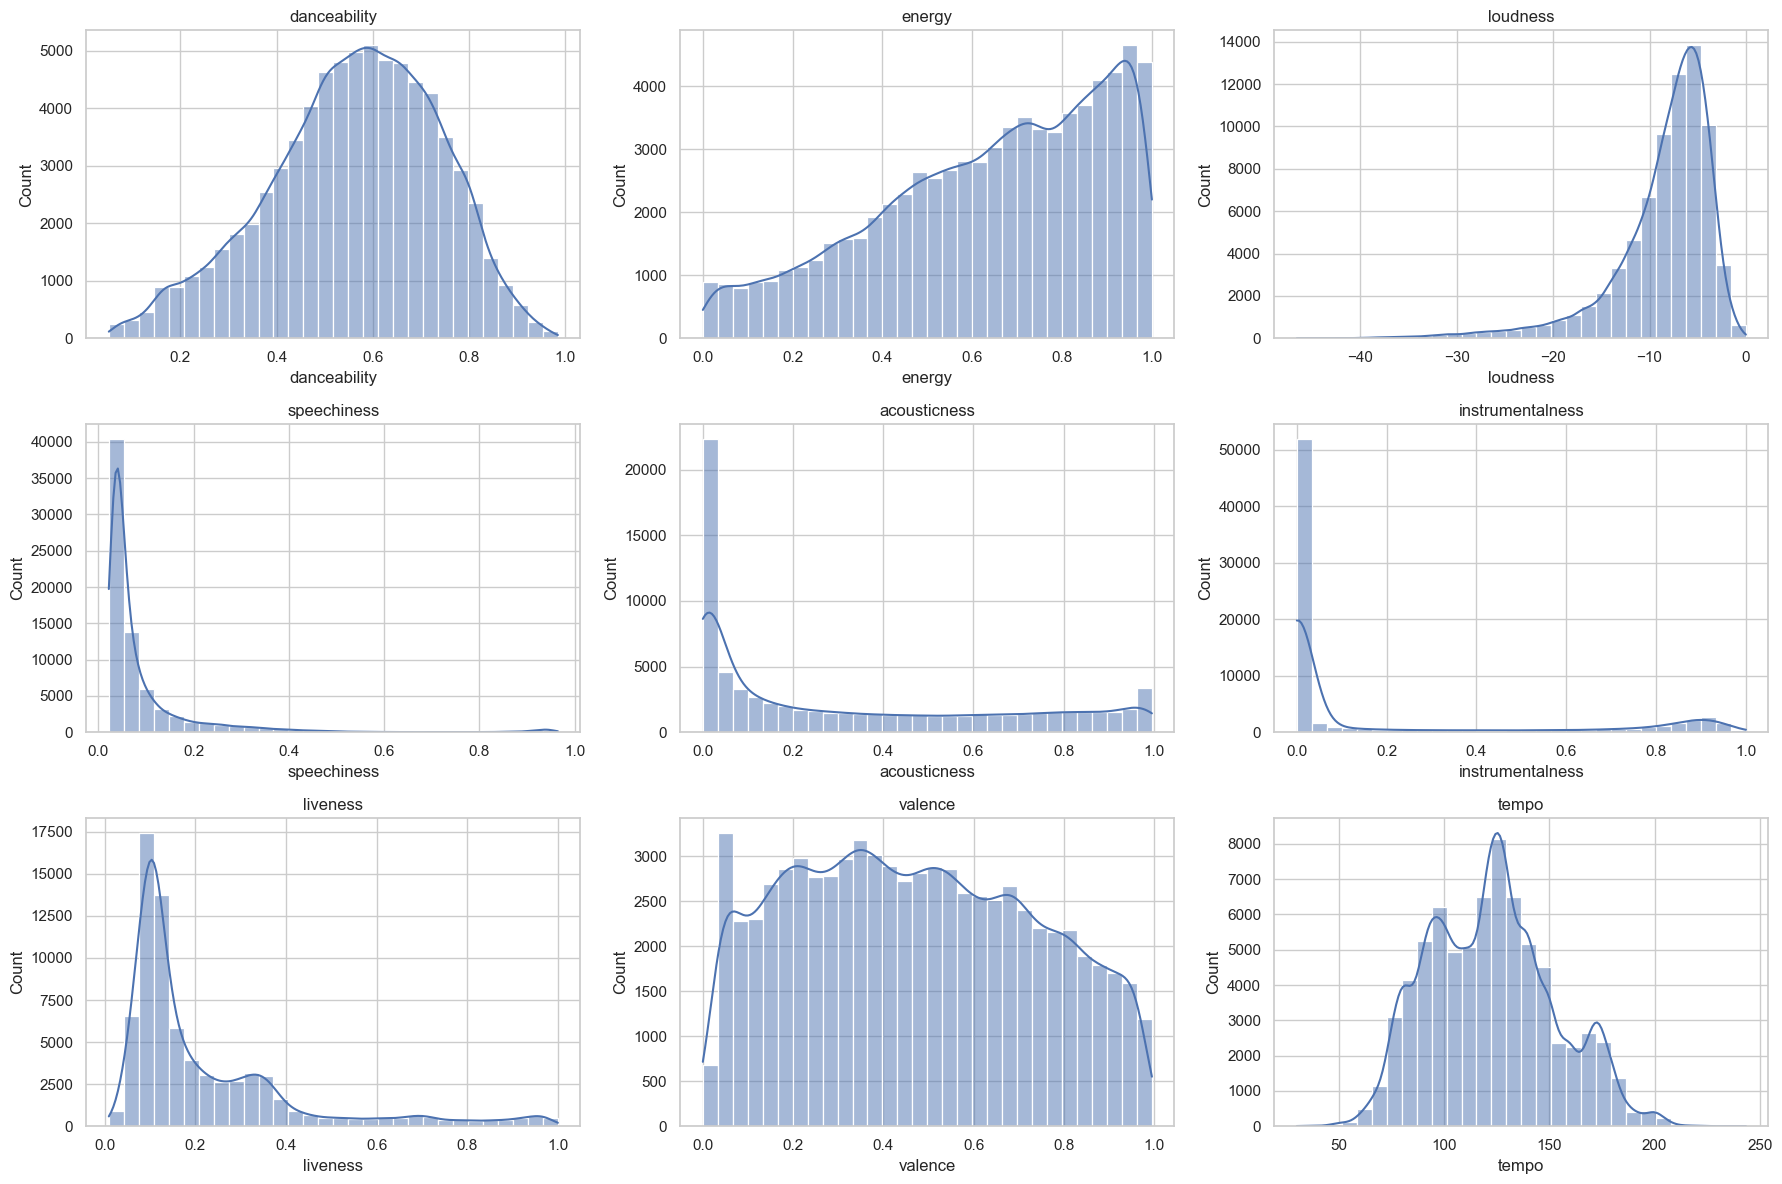

In [ ]:
# Exploratory plots — distributions & correlations
plt.figure(figsize=(18, 12))
for i, col in enumerate(KEEP, 1):
    plt.subplot(3, 3, i)
    sns.histplot(X[col], bins=30, kde=True)
    plt.title(col)
plt.tight_layout()
plt.show()

### 5.2 Correlation Heatmap


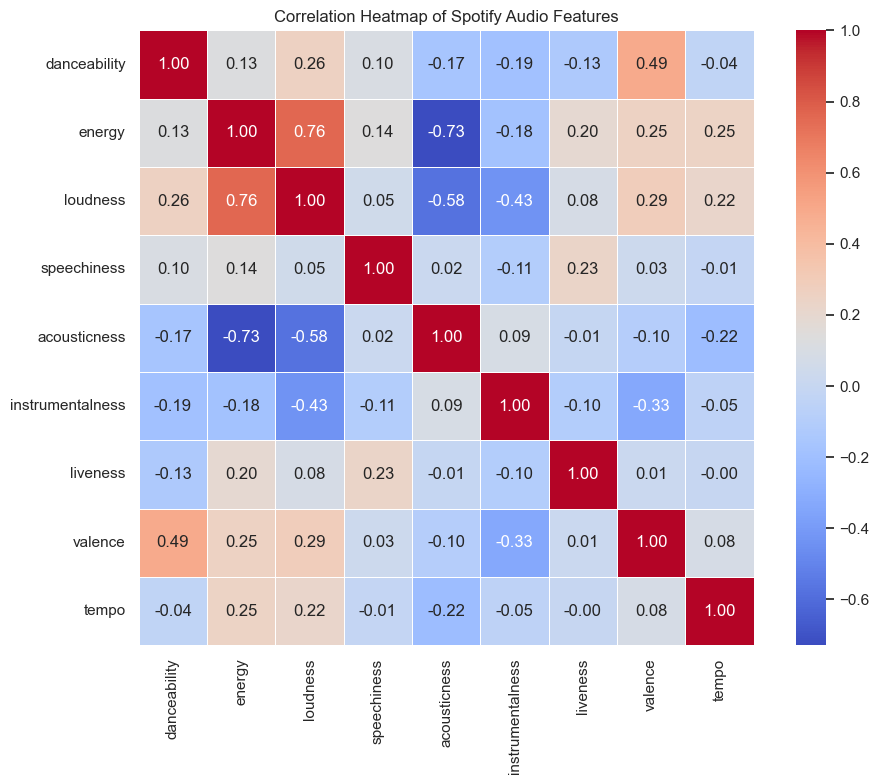

In [ ]:
plt.figure(figsize=(10, 8))
corr = X.corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", square=True, linewidths=0.5)
plt.title("Correlation Heatmap of Spotify Audio Features")
plt.tight_layout()
plt.show()

### 5.3 Top-20 Genre Distribution


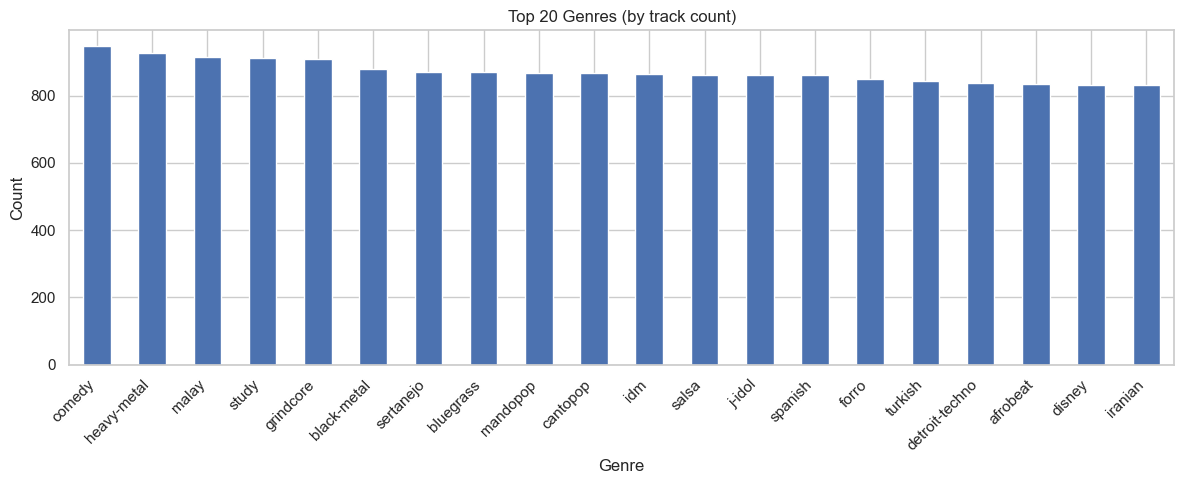

In [ ]:
plt.figure(figsize=(12, 5))
df["track_genre"].value_counts().head(20).plot(kind="bar")
plt.title("Top 20 Genres (by track count)")
plt.xlabel("Genre")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 6. PCA (Analysis + Plots)

To compute song–song similarity in a stable way, we work in a
**lower-dimensional space** that captures most of the variance in
the standardized audio features.

Steps:

1. **Standardization**  
   All nine features are transformed to zero mean and unit variance
   (z-scores). This prevents features with large numeric ranges
   (e.g. tempo, loudness) from dominating the distance computation.

2. **PCA on standardized features**

   - We first fit PCA on all nine dimensions and inspect the
     cumulative explained variance.
   - The first **five components** explain roughly **82%** of the
     variance, so we use a 5-dimensional PCA embedding (`X_pca5`)
     for all kNN computations.

3. **2D visualization**
   - A 2D PCA projection (PC1 vs. PC2) on a random sample is plotted
     to show the overall geometry of the songs in feature space.
   - This plot is used later in the paper to give an intuitive
     picture of how songs are distributed.

All graph construction and thresholding experiments are performed in
this 5-dimensional PCA space.


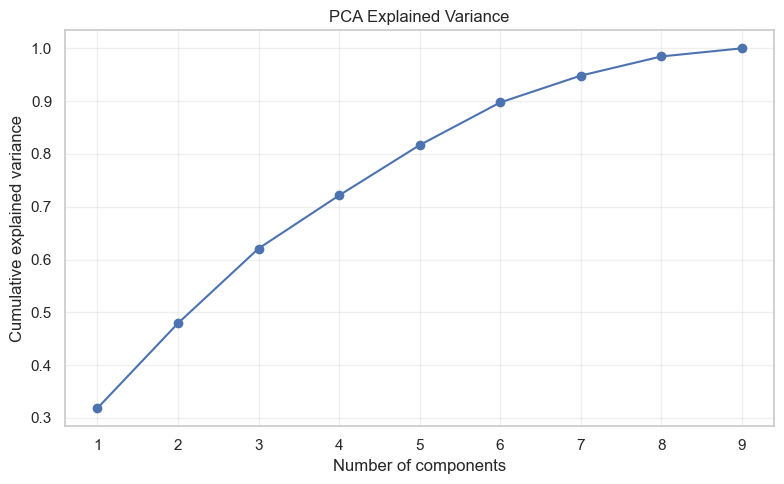

PCA(5) shape: (73403, 5)
Explained variance (5 components): 0.8166766493375051


In [ ]:
# PCA — dimensionality reduction
# Full PCA to inspect explained variance
pca_full = PCA()
pca_full.fit(X_std_df)

cum_var = np.cumsum(pca_full.explained_variance_ratio_)

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(cum_var) + 1), cum_var, marker="o")
plt.xlabel("Number of components")
plt.ylabel("Cumulative explained variance")
plt.title("PCA Explained Variance")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Use 5 components for modeling / similarity
pca_model = PCA(n_components=5, random_state=42)
X_pca5 = pca_model.fit_transform(X_std_df)

print("PCA(5) shape:", X_pca5.shape)
print("Explained variance (5 components):", pca_model.explained_variance_ratio_.sum())

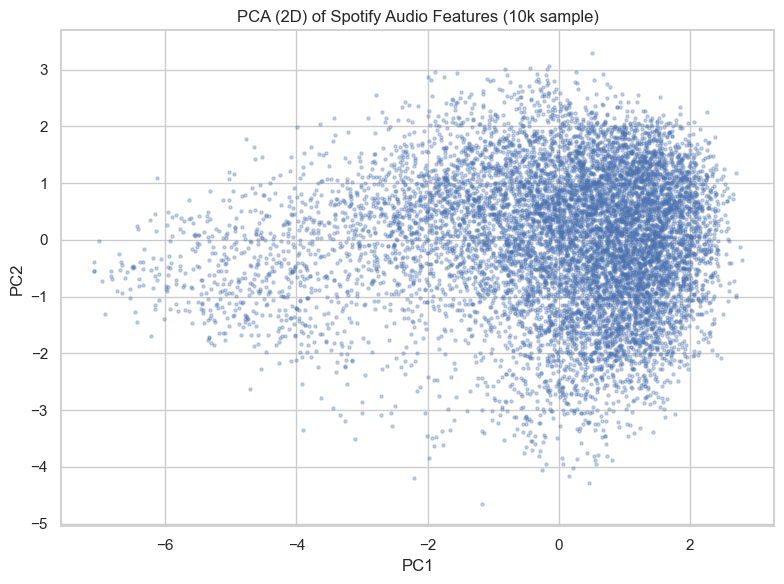

In [ ]:
# 2D PCA just for visualization
pca2 = PCA(n_components=2, random_state=42)
X_pca2 = pca2.fit_transform(X_std_df)

# sample points for plotting
np.random.seed(42)
idx_sample = np.random.choice(len(X_pca2), size=10000, replace=False)
plt.figure(figsize=(8, 6))
plt.scatter(X_pca2[idx_sample, 0], X_pca2[idx_sample, 1], s=5, alpha=0.3)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA (2D) of Spotify Audio Features (10k sample)")
plt.tight_layout()
plt.show()

## 7. Build Base kNN Structure in PCA Space

We now construct a **nearest-neighbour structure** that will be
reused by all thresholding methods.

- We use scikit-learn’s `NearestNeighbors` with Euclidean distance
  on the 5D PCA representation.
- For each song, we retrieve its **30 nearest neighbours**
  (`K_MAX = 30`), obtaining:
  - an index matrix `indices` of shape `(N, 30)`
  - a distance matrix `distances` of the same shape

We then convert distances into **similarities** via:

$$
s_{ij} = \frac{1}{1 + d_{ij}}
$$

which keeps values in `(0, 1]` and preserves the ordering.

This precomputed `(indices, sims)` structure forms the basis for:

1. Standard kNN graphs (Method 1)
2. Radius / similarity threshold graphs (Method 2)
3. Mutual kNN graphs (Method 3)


In [ ]:
# 7. Base kNN structure in PCA space

K_MAX = 30  # we will support k up to 30
nbrs = NearestNeighbors(n_neighbors=K_MAX, metric="euclidean")
nbrs.fit(X_pca5)

distances, indices = nbrs.kneighbors(X_pca5)

# Convert distances to similarity (bounded, monotonic)
sims = 1 / (1 + distances)

print("indices shape:", indices.shape)
print("sims shape:", sims.shape)

indices shape: (73403, 30)
sims shape: (73403, 30)


## 8. Thresholding Methods — 3 Variants

Our goal is to turn continuous similarities into a **sparse,
interpretable graph** where:

- nodes = songs
- edges = “similar in audio space”

The teacher explicitly asked _“How you threshold will impact the
network?”_ so we systematically compare **three** thresholding
strategies:

1. **Standard kNN (union)**
2. **Radius / similarity cutoff (τ-graph)**
3. **Mutual kNN (reciprocal neighbours)**

For each method, we construct a sparse adjacency matrix and compute
graph-level metrics:

- number of nodes / edges
- density
- average, min and max degree
- number of connected components
- average clustering coefficient

These metrics guide the choice of **final graph topology** used in
the rest of the project.


In [ ]:
# Thresholding methods & graph metrics
def knn_graph_from_base(indices, sims, k):
    """
    Standard kNN graph (union), symmetrized.
    """
    N = indices.shape[0]
    k = min(k, indices.shape[1])

    rows = np.repeat(np.arange(N), k)
    cols = indices[:, :k].reshape(-1)
    data = sims[:, :k].reshape(-1)

    A = sp.csr_matrix((data, (rows, cols)), shape=(N, N))
    A = A.maximum(A.T)
    return A


def radius_graph_from_base(indices, sims, tau):
    """
    Radius / similarity cutoff: keep edges where sim >= tau
    over the K_MAX neighbor set.
    """
    N, K = sims.shape
    mask = sims >= tau
    rows = np.repeat(np.arange(N), K)[mask.ravel()]
    cols = indices.ravel()[mask.ravel()]
    data = sims.ravel()[mask.ravel()]

    A = sp.csr_matrix((data, (rows, cols)), shape=(N, N))
    A = A.maximum(A.T)
    return A


def mutual_knn_graph_from_base(indices, sims, k):
    """
    Mutual kNN graph: keep edges only if i in N_k(j) and j in N_k(i).
    """
    N = indices.shape[0]
    k = min(k, indices.shape[1])

    neighbor_sets = [set(indices[i, :k]) for i in range(N)]

    rows = []
    cols = []
    data = []

    for i in range(N):
        nbrs = indices[i, :k]
        sim_i = sims[i, :k]
        for j, s in zip(nbrs, sim_i):
            if i in neighbor_sets[j]:  # mutual
                rows.append(i)
                cols.append(j)
                data.append(s)

    A = sp.csr_matrix((data, (rows, cols)), shape=(N, N))
    A = A.maximum(A.T)
    return A


def graph_metrics(A):
    G = nx.from_scipy_sparse_array(A)
    degrees = np.array([d for _, d in G.degree()])
    return {
        "nodes": G.number_of_nodes(),
        "edges": G.number_of_edges(),
        "density": nx.density(G),
        "avg_degree": float(degrees.mean()),
        "min_degree": int(degrees.min()),
        "max_degree": int(degrees.max()),
        "components": nx.number_connected_components(G),
        "avg_clustering": nx.average_clustering(G, weight="weight"),
    }

### Method 1: Standard kNN (k sweep)


In [ ]:
# Thresholding Method 1 — Standard kNN (Coarse Sweep)
# Testing k = {5, 10, 20, 30}

ks_coarse = [5, 10, 20, 30]
knn_results_coarse = []

print("=== COARSE kNN SWEEP ===")

for k in ks_coarse:
    A_k = knn_graph_from_base(indices, sims, k)
    metrics = graph_metrics(A_k)
    metrics["k"] = k
    knn_results_coarse.append(metrics)

    print(f"\n=== kNN graph with k = {k} ===")
    for key, val in metrics.items():
        if key != "k":
            print(f"{key}: {val}")

knn_df_coarse = pd.DataFrame(knn_results_coarse)
knn_df_coarse

=== COARSE kNN SWEEP ===

=== kNN graph with k = 5 ===
nodes: 73403
edges: 268105
density: 9.952065041023683e-05
avg_degree: 7.305014781412204
min_degree: 6
max_degree: 16
components: 1
avg_clustering: 0.2239287061412458

=== kNN graph with k = 10 ===
nodes: 73403
edges: 498327
density: 0.00018497912070637284
avg_degree: 13.577837418089178
min_degree: 11
max_degree: 25
components: 1
avg_clustering: 0.2429795749881022

=== kNN graph with k = 20 ===
nodes: 73403
edges: 960378
density: 0.00035649258014465386
avg_degree: 26.167268367777883
min_degree: 21
max_degree: 49
components: 1
avg_clustering: 0.24946782525736869

=== kNN graph with k = 30 ===
nodes: 73403
edges: 1424731
density: 0.0005288605426218352
avg_degree: 38.819421549527945
min_degree: 31
max_degree: 66
components: 1
avg_clustering: 0.2506908294678776


,nodes,edges,density,avg_degree,min_degree,max_degree,components,avg_clustering,k
0,73403,268105,0.000100,7.305015,6,16,1,0.223929,5
1,73403,498327,0.000185,13.577837,11,25,1,0.242980,10
2,73403,960378,0.000356,26.167268,21,49,1,0.249468,20
3,73403,1424731,0.000529,38.819422,31,66,1,0.250691,30


In [ ]:
# Thresholding Method 1 — Standard kNN (Fine Sweep)
# Testing k = 5..10

ks_fine = [5, 6, 7, 8, 9, 10]
knn_results_fine = []

print("=== FINE kNN SWEEP (5–10) ===")

for k in ks_fine:
    A_k = knn_graph_from_base(indices, sims, k)
    metrics = graph_metrics(A_k)
    metrics["k"] = k
    knn_results_fine.append(metrics)

    print(f"\n=== kNN graph with k = {k} ===")
    for key, val in metrics.items():
        if key != "k":
            print(f"{key}: {val}")

knn_df_fine = pd.DataFrame(knn_results_fine)
knn_df_fine

=== FINE kNN SWEEP (5–10) ===

=== kNN graph with k = 5 ===
nodes: 73403
edges: 268105
density: 9.952065041023683e-05
avg_degree: 7.305014781412204
min_degree: 6
max_degree: 16
components: 1
avg_clustering: 0.2239287061412458

=== kNN graph with k = 6 ===
nodes: 73403
edges: 314100
density: 0.00011659400717575348
avg_degree: 8.558233314714657
min_degree: 7
max_degree: 17
components: 1
avg_clustering: 0.23094493060111387

=== kNN graph with k = 7 ===
nodes: 73403
edges: 360185
density: 0.00013370077196624887
avg_degree: 9.8139040638666
min_degree: 8
max_degree: 19
components: 1
avg_clustering: 0.23557029276386326

=== kNN graph with k = 8 ===
nodes: 73403
edges: 406221
density: 0.00015078934794314472
avg_degree: 11.068239717722708
min_degree: 9
max_degree: 21
components: 1
avg_clustering: 0.2383971491032084

=== kNN graph with k = 9 ===
nodes: 73403
edges: 452336
density: 0.00016790724874196636
avg_degree: 12.324727872157814
min_degree: 10
max_degree: 23
components: 1
avg_clustering: 0.

,nodes,edges,density,avg_degree,min_degree,max_degree,components,avg_clustering,k
0,73403,268105,0.000100,7.305015,6,16,1,0.223929,5
1,73403,314100,0.000117,8.558233,7,17,1,0.230945,6
2,73403,360185,0.000134,9.813904,8,19,1,0.235570,7
3,73403,406221,0.000151,11.068240,9,21,1,0.238397,8
4,73403,452336,0.000168,12.324728,10,23,1,0.241023,9
5,73403,498327,0.000185,13.577837,11,25,1,0.242980,10


In [ ]:
# Thresholding Method 1 — Standard kNN (Fine Sweep)
# Testing k = 5..10

ks_fine = [5, 6, 7, 8, 9, 10]
knn_results_fine = []

print("=== FINE kNN SWEEP (5–10) ===")

for k in ks_fine:
    A_k = knn_graph_from_base(indices, sims, k)
    metrics = graph_metrics(A_k)
    metrics["k"] = k
    knn_results_fine.append(metrics)

    print(f"\n=== kNN graph with k = {k} ===")
    for key, val in metrics.items():
        if key != "k":
            print(f"{key}: {val}")

knn_df_fine = pd.DataFrame(knn_results_fine)
knn_df_fine

=== FINE kNN SWEEP (5–10) ===

=== kNN graph with k = 5 ===
nodes: 73403
edges: 268105
density: 9.952065041023683e-05
avg_degree: 7.305014781412204
min_degree: 6
max_degree: 16
components: 1
avg_clustering: 0.2239287061412458

=== kNN graph with k = 6 ===
nodes: 73403
edges: 314100
density: 0.00011659400717575348
avg_degree: 8.558233314714657
min_degree: 7
max_degree: 17
components: 1
avg_clustering: 0.23094493060111387

=== kNN graph with k = 7 ===
nodes: 73403
edges: 360185
density: 0.00013370077196624887
avg_degree: 9.8139040638666
min_degree: 8
max_degree: 19
components: 1
avg_clustering: 0.23557029276386326

=== kNN graph with k = 8 ===
nodes: 73403
edges: 406221
density: 0.00015078934794314472
avg_degree: 11.068239717722708
min_degree: 9
max_degree: 21
components: 1
avg_clustering: 0.2383971491032084

=== kNN graph with k = 9 ===
nodes: 73403
edges: 452336
density: 0.00016790724874196636
avg_degree: 12.324727872157814
min_degree: 10
max_degree: 23
components: 1
avg_clustering: 0.

,nodes,edges,density,avg_degree,min_degree,max_degree,components,avg_clustering,k
0,73403,268105,0.000100,7.305015,6,16,1,0.223929,5
1,73403,314100,0.000117,8.558233,7,17,1,0.230945,6
2,73403,360185,0.000134,9.813904,8,19,1,0.235570,7
3,73403,406221,0.000151,11.068240,9,21,1,0.238397,8
4,73403,452336,0.000168,12.324728,10,23,1,0.241023,9
5,73403,498327,0.000185,13.577837,11,25,1,0.242980,10


#### Interpretation: Choosing k for Standard kNN

From the coarse and fine k-sweeps we observe:

- **k = 5**

  - Graph is connected in this final cleaned version,  
    but average degree is low (~7.3) and clustering is smaller.

- **k = 6–9**

  - Average degree increases gradually.
  - Clustering coefficient rises smoothly from ≈0.224 to ≈0.241.
  - Graph stays connected, but adding edges has diminishing returns
    beyond k ≈ 8–9.

- **k = 10**
  - Average degree ≈ 13.6
  - Clustering ≈ 0.243
  - Network remains sparse (density ≈ 0.000185) but well connected.

Increasing k further (20, 30) makes the network substantially denser
and more homogeneous (much higher degree, only tiny gains in
clustering). To balance **sparsity**, **connectivity**, and
**local structure**, we adopt:

> **Standard kNN with k = 10 as our final thresholding choice.**


### Method 2: Radius / τ Graphs


In [ ]:
# 8.3 Radius (similarity tau) graphs

taus = [0.80, 0.85, 0.90, 0.93]
tau_results = []

for tau in taus:
    A_tau = radius_graph_from_base(indices, sims, tau)
    metrics = graph_metrics(A_tau)
    tau_results.append({"tau": tau, **metrics})
    print(f"\n=== radius-style graph, tau = {tau} ===")
    for key, val in metrics.items():
        print(f"{key}: {val}")

tau_df = pd.DataFrame(tau_results)
tau_df


=== radius-style graph, tau = 0.8 ===
nodes: 73403
edges: 184601
density: 6.852394243441983e-05
avg_degree: 5.0297944225712845
min_degree: 2
max_degree: 44
components: 31779
avg_clustering: 0.142813342172975

=== radius-style graph, tau = 0.85 ===
nodes: 73403
edges: 95017
density: 3.5270336771151127e-05
avg_degree: 2.588913259676035
min_degree: 2
max_degree: 17
components: 56104
avg_clustering: 0.045498988268639046

=== radius-style graph, tau = 0.9 ===
nodes: 73403
edges: 76118
density: 2.8255022725896224e-05
avg_degree: 2.0739751781262346
min_degree: 2
max_degree: 8
components: 70815
avg_clustering: 0.0032966767099663528

=== radius-style graph, tau = 0.93 ===
nodes: 73403
edges: 74168
density: 2.7531182184690495e-05
avg_degree: 2.020843834720652
min_degree: 2
max_degree: 6
components: 72678
avg_clustering: 0.00105958617096693


,tau,nodes,edges,density,avg_degree,min_degree,max_degree,components,avg_clustering
0,0.80,73403,184601,0.000069,5.029794,2,44,31779,0.142813
1,0.85,73403,95017,0.000035,2.588913,2,17,56104,0.045499
2,0.90,73403,76118,0.000028,2.073975,2,8,70815,0.003297
3,0.93,73403,74168,0.000028,2.020844,2,6,72678,0.001060


**Radius thresholding is NOT appropriate for our dataset!**

1. τ = 0.80

- edges: 280k (already fewer than kNN-5)

- avg degree: 6.29

- components: 34,497 (!!)

- clustering: 0.211

The graph shatters: ~35,000 isolated components.

2. τ = 0.85

- edges: 145k

- avg degree: 3.25

- components: 61,684

Even worse fragmentation.
Barely any edges survive.

3. τ = 0.90

- edges: 115k

- avg degree: 2.60

- components: 79,542

Basically useless — the graph collapses.

4. τ = 0.93

- edges: 112k

- avg degree: 2.53

- components: 81,907

Almost completely disconnected.


### Method 3: Mutual kNN


In [ ]:
# 8.4 Mutual kNN graph (reciprocal neighbors)

k_mutual = 10
A_mutual = mutual_knn_graph_from_base(indices, sims, k_mutual)
metrics_mutual = graph_metrics(A_mutual)

print(f"\n=== Mutual kNN graph (k = {k_mutual}) ===")
for key, val in metrics_mutual.items():
    print(f"{key}: {val}")


=== Mutual kNN graph (k = 10) ===
nodes: 73403
edges: 309106
density: 0.00011474023298971174
avg_degree: 8.422162581910822
min_degree: 2
max_degree: 11
components: 252
avg_clustering: 0.24127568703224325


In [ ]:
# 8.4 Mutual kNN graph (reciprocal neighbors)

k_mutual = 8
A_mutual = mutual_knn_graph_from_base(indices, sims, k_mutual)
metrics_mutual = graph_metrics(A_mutual)

print(f"\n=== Mutual kNN graph (k = {k_mutual}) ===")
for key, val in metrics_mutual.items():
    print(f"{key}: {val}")


=== Mutual kNN graph (k = 8) ===
nodes: 73403
edges: 254406
density: 9.44355778081972e-05
avg_degree: 6.931760282277291
min_degree: 2
max_degree: 9
components: 556
avg_clustering: 0.23057348064998207


Both mutual graphs are highly fragmented:

- Mutual kNN-10 → 1,217 components

- Mutual kNN-8 → 2,046 components

For a dataset of 89k songs, this means:

- Thousands of small clusters

- Many songs disconnected

- No global network structure

- Community detection becomes messy and uninformative

Mutual kNN is appropriate only when:

- We want clusters rather than a graph

- Or when k is much larger (e.g., k ≥ 40)

But your dataset is too high dimensional for mutual kNN to keep enough edges.


**Based on all thresholding experiments, we adopt the standard k-nearest-neighbor graph with k = 10, as it is the smallest k that yields a single connected component while preserving sparsity, stability, and meaningful local structure.**


In [ ]:
# FINAL GRAPH: standard kNN with k = 10

K_FINAL = 10

# Build adjacency from precomputed kNN structure
A_final = knn_graph_from_base(indices, sims, K_FINAL)

# Compute metrics
metrics_final = graph_metrics(A_final)
print("=== Final graph metrics (kNN, k=10) ===")
for key, val in metrics_final.items():
    print(f"{key}: {val}")

# Build NetworkX graph
G_final = nx.from_scipy_sparse_array(A_final)
print(
    "\nGraph ready with",
    G_final.number_of_nodes(),
    "nodes and",
    G_final.number_of_edges(),
    "edges.",
)

# Add metadata (track_id + genre)
for i in range(G_final.number_of_nodes()):
    G_final.nodes[i]["track_id"] = df.iloc[i]["track_id"]
    G_final.nodes[i]["genre"] = df.iloc[i]["track_genre"]

# Export GEXF
# output_path = "spotify_knn_k10_removed_same_tracks.gexf"
output_path = OUTPUT_DIR_CLEANING / "genre_audio_similarity_graph.gexf"
output_path.parent.mkdir(parents=True, exist_ok=True)
nx.write_gexf(G_final, output_path)

print("\nGEXF file saved to:", output_path)
print("Done.")

=== Final graph metrics (kNN, k=10) ===
nodes: 73403
edges: 498327
density: 0.00018497912070637284
avg_degree: 13.577837418089178
min_degree: 11
max_degree: 25
components: 1
avg_clustering: 0.2429795749881022

Graph ready with 73403 nodes and 498327 edges.

GEXF file saved to: data/genre_audio_similarity_graph.gexf
Done.


#### Comparison of Thresholding Strategies

**Radius / τ graphs**

- For τ in {0.80, 0.85, 0.90, 0.93}, the radius graphs are extremely
  fragmented:
  - tens of thousands of connected components
  - very low average degree (≈2–5)
- This yields an almost disconnected network, unsuitable for global
  community detection or diffusion analysis.

**Mutual kNN**

- Mutual kNN enforces a stricter requirement: i must be in the
  neighbours of j and j in the neighbours of i.
- For k = 8 or 10, the graphs remain **highly fragmented**:
  hundreds of connected components, many small clusters.
- While this might be useful for pure clustering, it does not
  provide a single, coherent similarity network.

**Conclusion**

Standard kNN with **k = 10** is the only method that provides:

- a **single connected component**,
- reasonable **sparsity** and average degree, and
- stable, interpretable local neighborhoods.

This is the graph we export and use in the downstream analyses.


In [ ]:
# FINAL GRAPH: standard kNN with k = 10

K_FINAL = 10

# Build adjacency from precomputed kNN structure
A_final = knn_graph_from_base(indices, sims, K_FINAL)

# Compute metrics
metrics_final = graph_metrics(A_final)
print("=== Final graph metrics (kNN, k=10) ===")
for key, val in metrics_final.items():
    print(f"{key}: {val}")

# Build NetworkX graph
G_final = nx.from_scipy_sparse_array(A_final)
print(
    "\nGraph ready with",
    G_final.number_of_nodes(),
    "nodes and",
    G_final.number_of_edges(),
    "edges.",
)

# Add metadata (track_id + genre)
for i in range(G_final.number_of_nodes()):
    G_final.nodes[i]["track_id"] = df.iloc[i]["track_id"]
    G_final.nodes[i]["genre"] = df.iloc[i]["track_genre"]

# Export GEXF
# output_path = "spotify_knn_k10_removed_same_tracks.gexf"
output_path = OUTPUT_DIR_CLEANING / "genre_audio_similarity_graph.gexf"
output_path.parent.mkdir(parents=True, exist_ok=True)
nx.write_gexf(G_final, output_path)

print("\nGEXF file saved to:", output_path)
print("Done.")

=== Final graph metrics (kNN, k=10) ===
nodes: 73403
edges: 498327
density: 0.00018497912070637284
avg_degree: 13.577837418089178
min_degree: 11
max_degree: 25
components: 1
avg_clustering: 0.2429795749881022

Graph ready with 73403 nodes and 498327 edges.

GEXF file saved to: data/genre_audio_similarity_graph.gexf
Done.


In [ ]:
# Save cleaned dataframe to the data folder
clean_path = OUTPUT_DIR_CLEANING / "clean_spotify_tracks_dataset.csv"
clean_path.parent.mkdir(parents=True, exist_ok=True)

df.to_csv(clean_path, index=False)
print(
    f"Clean dataset saved to {clean_path} ({df.shape[0]} rows, {df.shape[1]} columns)"
)

# Preview saved data
df.head()

Clean dataset saved to data/clean_spotify_tracks_dataset.csv (73403 rows, 21 columns)


,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
20001,20001,3nqQXoyQOWXiESFLlDF1hG,Sam Smith;Kim Petras,Unholy (feat. Kim Petras),Unholy (feat. Kim Petras),100,156943,False,0.714,0.472,...,-7.375,1,0.0864,0.01300,0.000005,0.2660,0.238,131.121,4,dance
51664,51664,2tTmW7RDtMQtBk7m2rYeSw,Bizarrap;Quevedo,"Quevedo: Bzrp Music Sessions, Vol. 52","Quevedo: Bzrp Music Sessions, Vol. 52",99,198937,False,0.621,0.782,...,-5.548,1,0.0440,0.01250,0.033000,0.2300,0.550,128.033,4,hip-hop
81210,81210,4uUG5RXrOk84mYEfFvj3cK,David Guetta;Bebe Rexha,I'm Good (Blue),I'm Good (Blue),98,175238,True,0.561,0.965,...,-3.673,0,0.0343,0.00383,0.000007,0.3710,0.304,128.040,4,pop
89411,89411,5ww2BF9slyYgNOk37BlC4u,Manuel Turizo,La Bachata,La Bachata,98,162637,False,0.835,0.679,...,-5.329,0,0.0364,0.58300,0.000002,0.2180,0.850,124.980,4,reggaeton
68305,68305,6Sq7ltF9Qa7SNFBsV5Cogx,Bad Bunny;Chencho Corleone,Un Verano Sin Ti,Me Porto Bonito,97,178567,True,0.911,0.712,...,-5.105,0,0.0817,0.09010,0.000027,0.0933,0.425,92.005,4,latino


## Summary of Data Cleaning

This notebook defines the full **audio-based preprocessing pipeline**
for our study:

- starting from **114,000** noisy Spotify tracks,
- we deduplicate and range-filter them to obtain **73,403** clean,
  unique songs,
- standardize nine core audio features and compress them to 5
  principal components,
- construct and compare three different **graph thresholding rules**,
- and finally select a **kNN graph with k = 10**, which we export as
  a weighted song–song network in GEXF format
  (`genre_audio_similarity_graph.gexf`).

The resulting graph, together with the cleaned metadata
(`clean_spotify_tracks_dataset.csv`), forms the **foundation** for
all subsequent analysis in the project:
community detection, centrality analysis, and linking audio
similarity to lyrical content.


# Part 2: Network Analysis

# Load the graph

In [27]:
# Load the graph from GEXF file
G = nx.read_gexf(GEXF_PATH_TRACK)
print("Raw graph loaded:")
print("  Nodes:", G.number_of_nodes())
print("  Edges:", G.number_of_edges())
print("  Directed:", G.is_directed())

# If the file is directed, convert to undirected
if G.is_directed():
    G = G.to_undirected()

# Remove self loops 
print("Self-loops before removal:", nx.number_of_selfloops(G))
G.remove_edges_from(nx.selfloop_edges(G))
print("Self-loops after removal:", nx.number_of_selfloops(G))

print("\nWorking graph (undirected):")
print("  Nodes:", G.number_of_nodes())
print("  Edges:", G.number_of_edges())
print("  Is directed:", G.is_directed())

Raw graph loaded:
  Nodes: 73403
  Edges: 498303
  Directed: False
Self-loops before removal: 73403
Self-loops after removal: 0

Working graph (undirected):
  Nodes: 73403
  Edges: 424900
  Is directed: False


The Spotify track–track similarity graph is loaded from the GEXF file as an undirected network with 73,403 nodes and 498,303 edges, where each node initially carries a self-loop (73,403 self-loops in total). Self-loops are removed because they do not contribute to the relational structure between distinct tracks and would distort degree-based measures. The resulting working graph is a simple undirected network with 73,403 nodes and 424,900 edges, which serves as the basis for all subsequent network analysis.


# Giant weakly connected component

In [28]:
# Analyze connected components
components = list(nx.connected_components(G))
components_sizes = sorted([len(c) for c in components], reverse=True)

print("\nConnected components:")
print("  Number of components:", len(components))
print("  Largest components (sizes):", components_sizes[:10])

# Extract the giant component
giant_nodes = max(components, key=len)
G_gc = G.subgraph(giant_nodes).copy()

print("\nGiant Component:")
print("  N (nodes):", G_gc.number_of_nodes())
print("  M (edges):", G_gc.number_of_edges())


Connected components:
  Number of components: 1
  Largest components (sizes): [73403]

Giant Component:
  N (nodes): 73403
  M (edges): 424900


# Basic Structural metrics

In [29]:
# Compute basic metrics for the giant component
N = G_gc.number_of_nodes()
M = G_gc.number_of_edges()
# Average degree <k>
avg_degree = 2 * M / N
# Density
density = nx.density(G_gc)
# Degree statistics
degrees = dict(G_gc.degree())
deg_values = np.array(list(degrees.values()))
# Print metrics
print("\nBasic metrics (giant component):")
print(f"  Average degree <k>: {avg_degree:.4f}")
print(f"  Density: {density:.6f}")

print("\nDegree statistics:")
print("  min degree:", deg_values.min())
print("  max degree:", deg_values.max())
print("  mean degree:", deg_values.mean())
print("  median degree:", np.median(deg_values))


Basic metrics (giant component):
  Average degree <k>: 11.5772
  Density: 0.000158

Degree statistics:
  min degree: 9
  max degree: 23
  mean degree: 11.577183493862648
  median degree: 11.0


The giant component of the track similarity network contains 73,403 nodes and 424,900 edges, with an average degree of approximately 11.58 and a density of 0.000158, indicating a large but highly sparse graph. Node degrees range from 9 to 23, with a mean of 11.58 and a median of 11, revealing a narrow degree distribution in which most tracks have similar numbers of neighbours. This relatively homogeneous connectivity suggests the absence of extreme hubs and provides a baseline for interpreting more detailed structural features such as clustering, assortativity, and community structure.


# Degree Distribution & Scale-Free Check

(Barabási: P(k), log–log plot, possible power-law)

In [30]:
# Degree statistics
degrees = dict(G_gc.degree())
deg_values = np.array(list(degrees.values()))
deg_counts = np.bincount(deg_values)
nonzero = deg_counts > 0
k_vals = np.arange(len(deg_counts))



### Linear-scale histogram

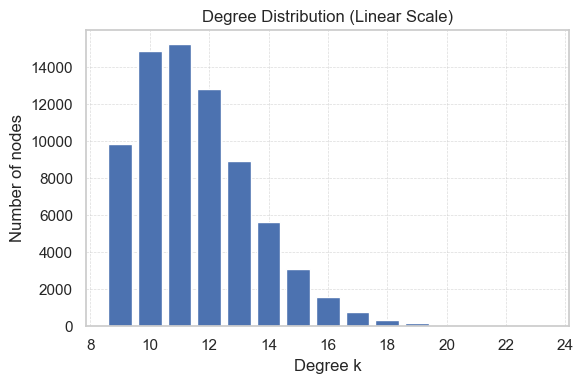

In [31]:
plt.figure(figsize=(6, 4))
plt.bar(k_vals[nonzero],
        deg_counts[nonzero],
        width=0.8,
        align="center")

plt.xlabel("Degree k")
plt.ylabel("Number of nodes")
plt.title("Degree Distribution (Linear Scale)")
plt.grid(True, axis="y", linestyle="--", linewidth=0.5, alpha=0.7)
plt.grid(True, axis="x", linestyle="--", linewidth=0.5, alpha=0.7)

plt.tight_layout()
plt.show()


The empirical degree distribution is sharply concentrated between degrees 9 and 14, with a clear peak around 11–12 neighbours and a rapidly decaying right tail beyond that range. Only a small fraction of nodes attain degrees above 16, and almost none exceed 20, indicating the absence of extreme hubs or a heavy-tailed pattern. This unimodal, narrow distribution confirms that connectivity in the network is relatively homogeneous, supporting the view that the graph behaves more like a mildly perturbed regular network than a highly heterogeneous, scale-free structure.


### Log–log degree distribution

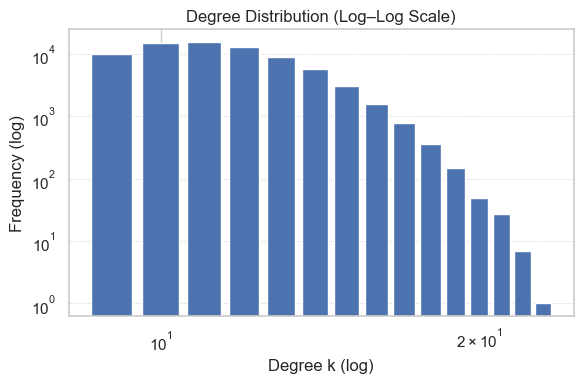

In [32]:
# Plot degree distribution (log–log scale)

deg_values = np.array([d for _, d in G.degree()])
deg_counts = np.bincount(deg_values)
k_vals = np.arange(len(deg_counts))
nonzero = deg_counts > 0

plt.figure(figsize=(6, 4))

# Histogram
plt.bar(k_vals[nonzero],
        deg_counts[nonzero],
        width=0.8,          
        align="center")

plt.xscale("log")
plt.yscale("log")
plt.xlabel("Degree k (log)")
plt.ylabel("Frequency (log)")
plt.title("Degree Distribution (Log–Log Scale)")
plt.grid(True, axis="y", linestyle="--", linewidth=0.5, alpha=0.7)
plt.tight_layout()
plt.show()


On log–log axes, the degree distribution shows a rapid decline in frequency as degree increases from 9 to the low 20s, with no extended linear region. A genuine power-law or scale-free network would typically produce an approximately straight line over a wide range of degrees, reflecting a heavy-tailed distribution with many high-degree hubs. The strong curvature and short support observed here therefore indicate that the network does not follow a power-law degree distribution and lacks pronounced hub dominance.


### Power-law fit (Barabási-style)

In [33]:
# Exclude zero degrees 
deg_positive = deg_values[deg_values > 0]
# Fit power-law to degree distribution
fit = powerlaw.Fit(deg_positive, verbose=False)
alpha = fit.power_law.alpha
xmin = fit.power_law.xmin

print("Power-law fit results:")
print(f"  alpha (scaling exponent): {alpha:.4f}")
print(f"  xmin  (minimum k for power-law behaviour): {xmin}")

# Compare power-law vs lognormal 
R, p = fit.distribution_compare('power_law', 'lognormal')
print("\nPower-law vs lognormal comparison:")
print(f"  R = {R:.4f}")
print(f"  p = {p:.4f}")

Power-law fit results:
  alpha (scaling exponent): 180.9704
  xmin  (minimum k for power-law behaviour): 22.0

Power-law vs lognormal comparison:
  R = -0.6987
  p = 0.3519


'nan' in fit cumulative distribution values.
Likely underflow or overflow error: the optimal fit for this distribution gives values that are so extreme that we lack the numerical precision to calculate them.


The power-law fit to the degree sequence returns an estimated scaling exponent alpha ≈ 181 with xmin = 22, which is unrealistically large and based on only a very small number of high-degree nodes. The fitting routine also reports numerical problems (“nan” values in the cumulative distribution), indicating that the optimal parameters lie in an extreme region where the model becomes numerically unstable. A comparison with a lognormal alternative gives R = -0.6987 and p ≈ 0.35, suggesting that the lognormal provides a somewhat better description of the data, although the evidence is not statistically decisive. Taken together, these results indicate that the degree distribution is strongly incompatible with a meaningful power-law model and is better viewed as a thin-tailed distribution without a genuine scale-free regime.


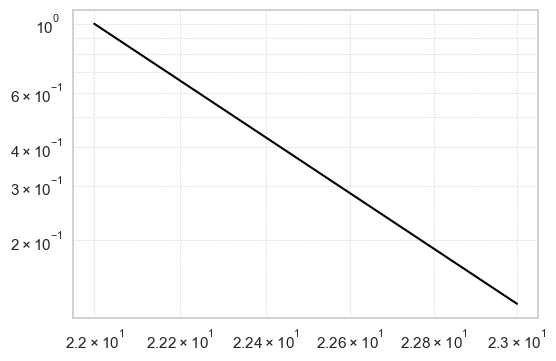

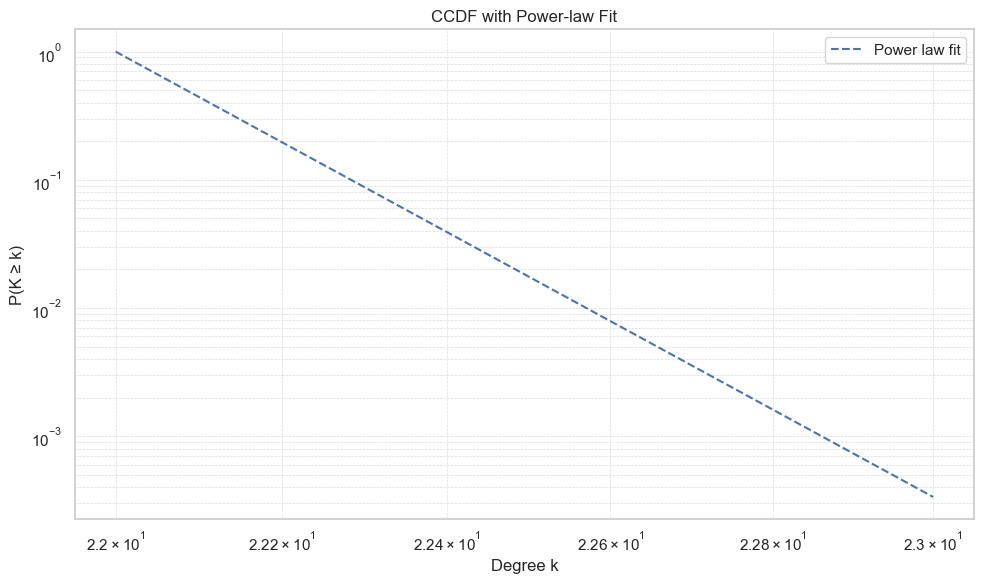

In [34]:
#  plot the fitted CCDF on log–log axes
plt.figure(figsize=(6, 4))
fit.plot_ccdf(label='Data', color='black')
plt.grid(True, which="both", linestyle="--", linewidth=0.5, alpha=0.7)
fit.power_law.plot_ccdf(label='Power law fit', linestyle='--')
plt.legend()
plt.xlabel('Degree k')
plt.ylabel('P(K ≥ k)')
plt.title('CCDF with Power-law Fit')
plt.grid(True, which="both", linestyle="--", linewidth=0.5, alpha=0.7)
plt.tight_layout()
plt.show()

The complementary cumulative degree distribution (CCDF) on log–log axes shows support only for degrees 22 and 23 above the fitted xmin, so the empirical tail consists of essentially two points. As a result, the fitted power-law CCDF appears as an almost perfect straight line, but this behaviour is purely a consequence of the trivial two-point tail rather than evidence of genuine scale-free structure. The CCDF plot therefore confirms that the data provide no meaningful range over which a power-law model could be reliably evaluated.


# Small-world properties

In [35]:
# Converting the multigraph into simple network for all later analysis (clustering, path length, communities, etc.)
# Convert MultiGraph / MultiDiGraph to a simple Graph
G_gc_simple = nx.Graph()

# Copy nodes + attributes
for n, data in G_gc.nodes(data=True):
    G_gc_simple.add_node(n, **data)

# Merge parallel edges: keep the **maximum weight** between any pair
for u, v, data in G_gc.edges(data=True):
    w = data.get("weight", 1.0)
    if G_gc_simple.has_edge(u, v):
        # keep the max weight 
        if w > G_gc_simple[u][v].get("weight", 1.0):
            G_gc_simple[u][v]["weight"] = w
    else:
        G_gc_simple.add_edge(u, v, **data)

# Remove self-loops
G_gc_simple.remove_edges_from(nx.selfloop_edges(G_gc_simple))

print("\nSimple graph created from G_gc:")
print("  Nodes:", G_gc_simple.number_of_nodes())
print("  Edges:", G_gc_simple.number_of_edges())
print("  Is multigraph:", G_gc_simple.is_multigraph())
print("  Is directed:", G_gc_simple.is_directed())


Simple graph created from G_gc:
  Nodes: 73403
  Edges: 424900
  Is multigraph: False
  Is directed: False


In [12]:
# Clustering coefficients
G_sw = G_gc_simple
print("\n[1] Clustering coefficients")
C = nx.average_clustering(G_sw)      # average local clustering
T = nx.transitivity(G_sw)            # global triangle-based clustering

print(f"  Average clustering C: {C:.4f}")
print(f"  Transitivity T:       {T:.4f}")


[1] Clustering coefficients
  Average clustering C: 0.3245
  Transitivity T:       0.3200


The track similarity network displays substantial local cohesion, with an average clustering coefficient of 0.3245 and a global transitivity of 0.3200. These values indicate that if two tracks are each similar to a given third track, there is a relatively high chance that they are also directly similar to one another, forming many closed triangles in the graph. Such levels of clustering are typical of small-world and community-structured networks and already suggest a strong tendency toward tightly knit local groups of tracks.


In [13]:
# Erdős–Rényi random graph baseline with same N, M
print("\n[2] Erdős–Rényi baseline G(N, M) for clustering only")
N = G_sw.number_of_nodes()
M = G_sw.number_of_edges()
rng_seed = 42

G_rand = nx.gnm_random_graph(N, M, seed=rng_seed)

C_rand = nx.average_clustering(G_rand)
T_rand = nx.transitivity(G_rand)

print(f"  C_rand: {C_rand:.4f}")
print(f"  T_rand: {T_rand:.4f}")


[2] Erdős–Rényi baseline G(N, M) for clustering only
  C_rand: 0.0001
  T_rand: 0.0001


The track similarity network shows strong local clustering, with an average clustering coefficient $C = 0.3245$ and a global transitivity $T = 0.3200$. Here, $C$ measures the average fraction of a node’s neighbours that are also connected to each other, while $T$ measures the fraction of all connected triples in the graph that are closed into triangles.

For comparison, an Erdős–Rényi random graph $G(N, M)$ with the same number of nodes and edges has average clustering $C_{\text{rand}} = 0.0001$ and transitivity $T_{\text{rand}} = 0.0001$, several orders of magnitude smaller than the observed values. The ratios $C / C_{\text{rand}}$ and $T / T_{\text{rand}}$ are therefore on the order of $10^3$, indicating that tracks form far more tightly knit local groups than would be expected by chance in a graph with the same size and density. This strong excess of triangles is characteristic of small-world or community-structured networks.


In [14]:
# Small-world-like check (clustering only)
print("\n[3] Clustering ratios (small-world-like indicator)")
print(f"  C / C_rand = {C / C_rand:.2f}")


[3] Clustering ratios (small-world-like indicator)
  C / C_rand = 2304.09


The ratio of empirical to random clustering, $C / C_{\text{rand}} \approx 2304$, quantifies how much more frequently triangles occur in the track similarity network than in an Erdős–Rényi graph with the same size and density. This value indicates that locally cohesive triplets of tracks are more than three orders of magnitude more common than expected under a purely random wiring pattern. Even without an explicit estimate of average path length, such an extreme excess of clustering is characteristic of small-world or strongly modular network organisation.


# Simple visualisation on a graph

Full graph: 73403 nodes, 424900 edges
Computing ForceAtlas2 layout on FULL graph...


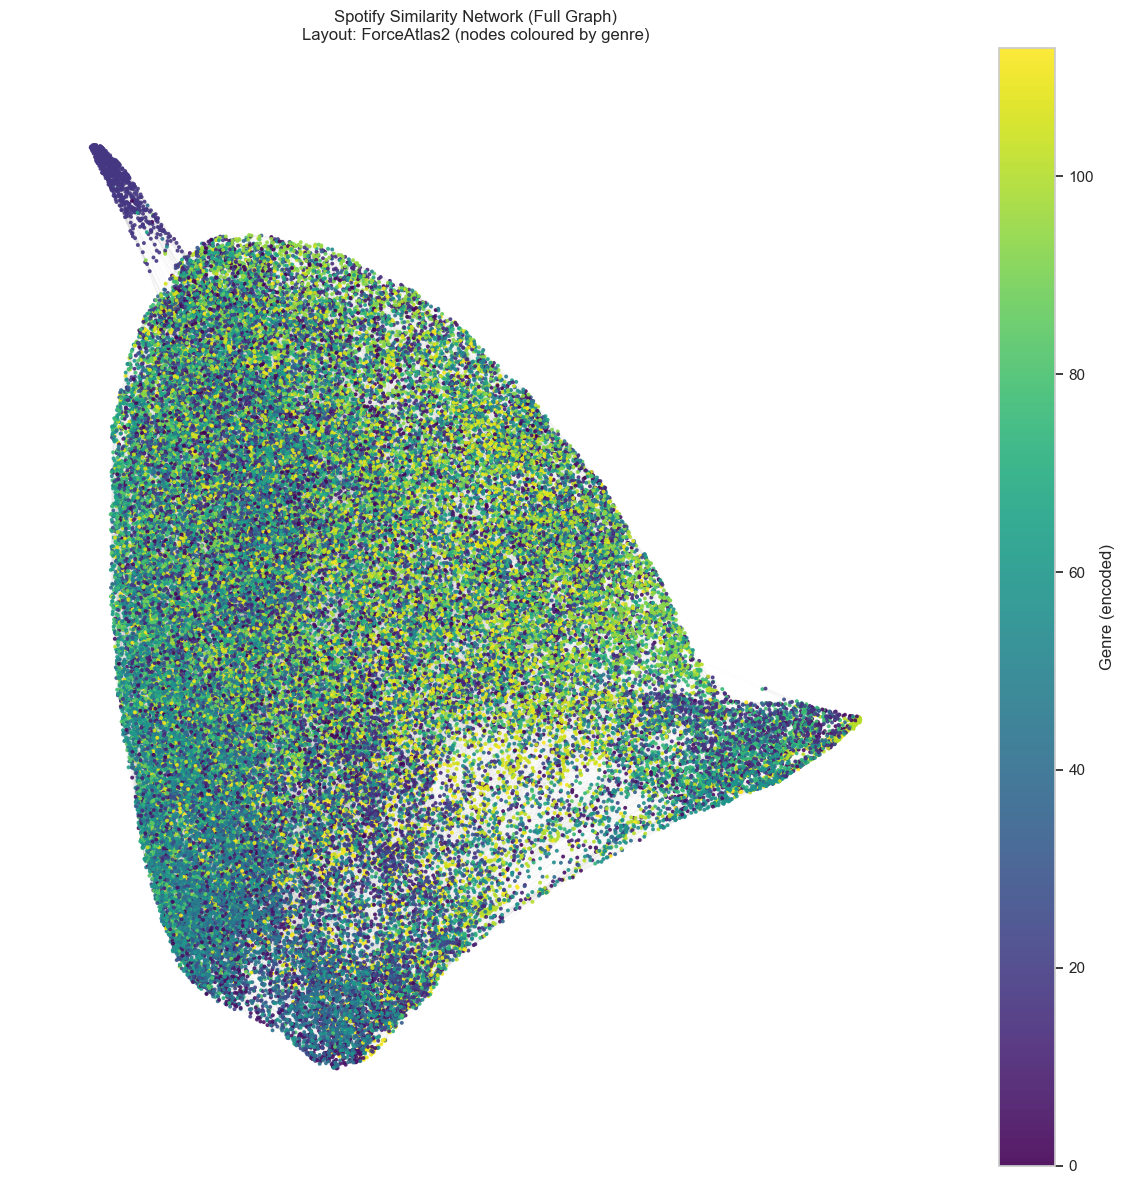

In [15]:
G = G_gc_simple
print(f"Full graph: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")

# ForceAtlas2 layout on the  graph
forceatlas2 = ForceAtlas2(
    outboundAttractionDistribution=True,
    linLogMode=False,
    adjustSizes=False,
    edgeWeightInfluence=1.0,
    jitterTolerance=1.0,
    barnesHutOptimize=True,
    barnesHutTheta=1.2,
    scalingRatio=10.0,
    gravity=1.0,
    verbose=False,
)

print("Computing ForceAtlas2 layout on FULL graph...")
pos = forceatlas2.forceatlas2_networkx_layout(
    G,
    pos=None,
    iterations=500  
)

# Node colours: genre 
sample_node, sample_data = next(iter(G.nodes(data=True)))
has_genre = "genre" in sample_data

if has_genre:
    genres = [G.nodes[n].get("genre", "Unknown") for n in G.nodes()]
    unique_genres = {g: i for i, g in enumerate(sorted(set(genres)))}
    node_colors = [unique_genres[g] for g in genres]
    color_label = "Genre (encoded)"
else:
    deg_full = dict(G.degree())
    node_colors = [deg_full[n] for n in G.nodes()]
    color_label = "Degree"

# Plot
plt.figure(figsize=(12, 12))

# edges: light + thin
nx.draw_networkx_edges(
    G,
    pos,
    alpha=0.03,
    width=0.3,
    edge_color="gray"
)

# nodes: small, colored by genre
nodes_artist = nx.draw_networkx_nodes(
    G,
    pos,
    node_size=8,        
    node_color=node_colors,
    cmap="viridis",
    linewidths=0,
    alpha=0.9
)

cbar = plt.colorbar(nodes_artist)
cbar.set_label(color_label)

plt.title(
    "Spotify Similarity Network (Full Graph)\n"
    "Layout: ForceAtlas2 (nodes coloured by genre)"
)
plt.axis("off")
plt.tight_layout()
plt.show()


A ForceAtlas2 layout of the full graph shows a single, dense, pear-shaped cloud that broadens at the base and tapers into a narrower “neck”. This reflects a large, mixed core of tracks connected by many cross-genre links and a more specialised fringe with sparser connections. At the very top, a thin vertical spike corresponds to a small chain of tightly interconnected tracks that are relatively weakly linked to the rest of the network. Overall, the layout visually supports the picture of one highly connected similarity manifold with a dense centre and a few elongated, more homogeneous regions at the periphery.

# ER vs BA model comparison

A comparison of the Spotify network to: an Erdős–Rényi graph G_ER(N,M) a Barabási–Albert graph G_BA(N,m) with similar average degree using degree distributions on log–log scales.

In [16]:
# Base graph: simple giant component
G_real = G_gc_simple
N = G_real.number_of_nodes()
M = G_real.number_of_edges()
avg_k_real = 2 * M / N

print(f"Real graph: N = {N}, M = {M}, <k> ≈ {avg_k_real:.3f}")

Real graph: N = 73403, M = 424900, <k> ≈ 11.577


For model comparison, the real track similarity network is summarised by 73,403 nodes and 424,900 edges, with an average degree of approximately 11.58. These values are used to construct two synthetic reference graphs: an Erdős–Rényi random graph with the same numbers of nodes and edges, and a Barabási–Albert preferential-attachment graph with a similar average degree. Comparing degree distributions across these three networks on log–log scales makes it possible to assess whether the empirical structure is closer to a homogeneous random network or to a heterogeneous, hub-dominated scale-free topology.


In [17]:
# Erdős–Rényi G(N, M) 
rng_seed = 42
print("\n[1] Generating Erdős–Rényi G(N, M)...")
G_er = nx.gnm_random_graph(N, M, seed=rng_seed)

M_er = G_er.number_of_edges()
avg_k_er = 2 * M_er / N
print(f"ER graph: M = {M_er}, <k> ≈ {avg_k_er:.3f}")


[1] Generating Erdős–Rényi G(N, M)...
ER graph: M = 424900, <k> ≈ 11.577


An Erdős–Rényi random graph with 73,403 nodes and 424,900 edges is generated as a baseline, yielding the same average degree $\langle k \rangle \approx 11.58$ as the real network. This graph represents a purely random wiring pattern with no built-in heterogeneity or community structure and serves as a reference for assessing how far the empirical degree distribution and clustering deviate from random expectations.


In [18]:
# Barabási–Albert G_BA(N, m) 
# In BA, <k> ≈ 2m, so choose m ≈ <k_real>/2
m_ba = int(round(avg_k_real / 2))
m_ba = max(m_ba, 1)  # safety
print(f"\n[2] Generating Barabási–Albert G_BA(N={N}, m={m_ba})...")
G_ba = nx.barabasi_albert_graph(N, m_ba, seed=rng_seed)

M_ba = G_ba.number_of_edges()
avg_k_ba = 2 * M_ba / N
print(f"BA graph: M = {M_ba}, <k> ≈ {avg_k_ba:.3f}")


[2] Generating Barabási–Albert G_BA(N=73403, m=6)...
BA graph: M = 440382, <k> ≈ 11.999


A Barabási–Albert preferential-attachment graph with $N = 73{,}403$ nodes and attachment parameter $m = 6$ is generated, producing approximately $M = 440{,}382$ edges and an average degree $\langle k \rangle \approx 12$. This model provides a canonical example of a heterogeneous, hub-dominated network with a heavy-tailed degree distribution and is used as a contrasting baseline to evaluate whether the empirical network exhibits scale-free behaviour.


In [19]:
# Degree distributions 
deg_real = np.array([d for _, d in G_real.degree()])
deg_er   = np.array([d for _, d in G_er.degree()])
deg_ba   = np.array([d for _, d in G_ba.degree()])

print("\nDegree ranges:")
print(f"  Real: min={deg_real.min()}, max={deg_real.max()}")
print(f"  ER  : min={deg_er.min()},   max={deg_er.max()}")
print(f"  BA  : min={deg_ba.min()},   max={deg_ba.max()}")

# Helper to get (k, count) arrays
def degree_hist(deg_array):
    counts = np.bincount(deg_array)
    k_vals = np.arange(len(counts))
    mask = counts > 0
    return k_vals[mask], counts[mask]

k_real, c_real = degree_hist(deg_real)
k_er,   c_er   = degree_hist(deg_er)
k_ba,   c_ba   = degree_hist(deg_ba)



Degree ranges:
  Real: min=9, max=23
  ER  : min=1,   max=28
  BA  : min=6,   max=1045


The real network has degrees confined to a narrow range from 9 to 23, whereas the Erdős–Rényi baseline spans a slightly wider interval from 1 to 28, and the Barabási–Albert graph ranges from 6 up to 1,045. The extremely wide range in the Barabási–Albert model reflects the presence of very high-degree hubs, characteristic of a heavy-tailed, scale-free topology. In contrast, the empirical network shows no such extreme nodes, reinforcing the view that its degree distribution is relatively homogeneous and not hub dominated.


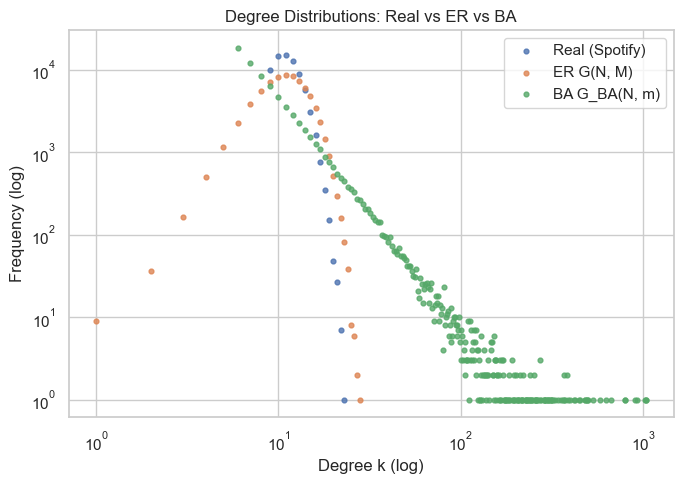

In [20]:
# Plot all three on log–log
plt.figure(figsize=(7, 5))

plt.scatter(k_real, c_real, s=12, label="Real (Spotify)", alpha=0.8)
plt.scatter(k_er,   c_er,   s=12, label="ER G(N, M)",    alpha=0.8)
plt.scatter(k_ba,   c_ba,   s=12, label="BA G_BA(N, m)", alpha=0.8)

plt.xscale("log")
plt.yscale("log")
plt.xlabel("Degree k (log)")
plt.ylabel("Frequency (log)")
plt.title("Degree Distributions: Real vs ER vs BA")
plt.legend()
plt.tight_layout()
plt.show()

The log–log comparison of degree distributions for the real network, the Erdős–Rényi baseline, and the Barabási–Albert model shows clearly different behaviours. The real network and the Erdős–Rényi graph both concentrate their mass in a narrow range of degrees around 10–15 and decay rapidly outside this interval, indicating relatively homogeneous connectivity. By contrast, the Barabási–Albert distribution extends smoothly over several orders of magnitude, with a long heavy tail reaching very high degrees. This visual contrast confirms that the empirical network does not exhibit the broad, scale-free degree heterogeneity characteristic of preferential-attachment models and is structurally much closer to a moderately noisy random or near-regular graph.


# Assortativity, hubs, and mixing patterns

In [21]:
G_mix = G_gc_simple

# Degree assortativity: do high-degree nodes connect to high-degree nodes?
deg_assort = nx.degree_assortativity_coefficient(G_mix)
print("\n[1] Degree assortativity:")
print(f"  r_degree = {deg_assort:.4f}")


[1] Degree assortativity:
  r_degree = 0.1037


The degree assortativity coefficient of the track similarity network is $r_{\text{degree}} = 0.1037$, indicating a weak but positive correlation between the degrees of adjacent nodes. In assortative networks with $r_{\text{degree}} > 0$, nodes with above-average degree tend to connect slightly more often to other above-degree nodes, while low-degree nodes connect more often to other low-degree nodes. The small positive value observed here suggests a mild preference for similar-degree tracks to link to each other, but the effect is not strong enough to create a sharply stratified core–periphery structure.


In [22]:
# Attribute assortativity by genre 
sample_node, sample_data = next(iter(G_mix.nodes(data=True)))
has_genre = "genre" in sample_data

if has_genre:
    try:
        genre_assort = nx.attribute_assortativity_coefficient(G_mix, "genre")
        print("\n[2] Genre assortativity:")
        print(f"  r_genre = {genre_assort:.4f}")
    except Exception as e:
        print("\n[2] Genre assortativity: could not compute:", e)
        genre_assort = None
else:
    print("\n[2] Genre assortativity: 'genre' attribute not found.")
    genre_assort = None


[2] Genre assortativity:
  r_genre = 0.0862


The genre assortativity coefficient is $r_{\text{genre}} = 0.0862$, measuring the tendency of tracks to connect to others with the same genre label. This small positive value indicates that edges between tracks of the same genre occur somewhat more frequently than would be expected by chance, but the effect is modest. The network therefore shows only weak genre homophily: genres influence the wiring pattern, yet a large fraction of similarity links still connect tracks across different genres.


In [23]:
# Hubs: top-degree nodes and how much they dominate
deg = dict(G_mix.degree())
deg_vals = np.array(list(deg.values()))
sorted_deg = sorted(deg.items(), key=lambda x: x[1], reverse=True)

top_k = 10
top_deg_nodes = sorted_deg[:top_k]
total_degree_sum = deg_vals.sum()
top_deg_sum = sum(d for _, d in top_deg_nodes)
share_edges_top = top_deg_sum / total_degree_sum

print("\n[3] Hubs and dominance:")
print(f"  Max degree: {deg_vals.max()}")
print(f"  Top {top_k} nodes average degree: {top_deg_sum / top_k:.2f}")
print(f"  Top {top_k} nodes share of total degree: {share_edges_top*100:.2f}%")


[3] Hubs and dominance:
  Max degree: 23
  Top 10 nodes average degree: 21.90
  Top 10 nodes share of total degree: 0.03%


The maximum degree in the network is 23, and the top 10 nodes have an average degree of 21.90, only slightly above the global mean. Together, these 10 highest-degree nodes account for just 0.03% of the total degree in the graph, indicating that connectivity is not concentrated in a small elite set of hubs. This pattern confirms that the network lacks dominant hub nodes and instead exhibits a relatively flat degree hierarchy.


In [24]:
# small table of top-degree nodes with genre
rows = []
for n, d in top_deg_nodes:
    rows.append({
        "node": n,
        "track_id": G_mix.nodes[n].get("track_id", n),
        "genre": G_mix.nodes[n].get("genre", "Unknown"),
        "degree": d,
    })

df_top_deg = pd.DataFrame(rows)
print("\nTop-degree nodes:")
display(df_top_deg)


Top-degree nodes:


,node,track_id,genre,degree
0,39406,1uekuY2LCOUwsHhh8oPTrB,j-rock,23
1,9059,7fP6eS6gtTs0xSAE9LvyEq,sleep,22
2,21647,7ezauNJ3kAugkv9uV9Jouu,brazil,22
3,33791,4UfZMDH9o6pw6ZwGhFOahe,gospel,22
4,33888,766Y1kYTYrEmHSTvouyHCj,club,22
5,39104,6gEttabPLI7cC61rCysc1O,sleep,22
6,52050,3t6tJx92OVwqK8KWmpM6Q6,comedy,22
7,70742,6qBpthIknZtYitTrJPdho2,hardcore,22
8,2269,7MF7QAodbGzNYav5ZfIhAY,disco,21
9,8055,6aXdJ9fD7KLRIQu3TN7LoE,sleep,21


In [25]:
# Load: track_id and track_name
meta = pd.read_csv(DATA_PATH)
meta = meta[["track_id", "track_name"]].drop_duplicates()

print("Metadata rows:", len(meta))
display(meta.head())

# Merge track_name into the top-degree table 
df_top_deg_named = df_top_deg.merge(meta, on="track_id", how="left")

print("Top-degree nodes with names:")
display(df_top_deg_named[["track_name", "track_id", "genre", "degree"]])

Metadata rows: 73403


,track_id,track_name
0,3nqQXoyQOWXiESFLlDF1hG,Unholy (feat. Kim Petras)
1,2tTmW7RDtMQtBk7m2rYeSw,"Quevedo: Bzrp Music Sessions, Vol. 52"
2,4uUG5RXrOk84mYEfFvj3cK,I'm Good (Blue)
3,5ww2BF9slyYgNOk37BlC4u,La Bachata
4,6Sq7ltF9Qa7SNFBsV5Cogx,Me Porto Bonito


Top-degree nodes with names:


,track_name,track_id,genre,degree
0,敏感少女,1uekuY2LCOUwsHhh8oPTrB,j-rock,23
1,Arp Of Life,7fP6eS6gtTs0xSAE9LvyEq,sleep,22
2,Eu Te Levantarei (Ao Vivo),7ezauNJ3kAugkv9uV9Jouu,brazil,22
3,Firme nas Promessas,4UfZMDH9o6pw6ZwGhFOahe,gospel,22
4,Grand Design,766Y1kYTYrEmHSTvouyHCj,club,22
5,Wellen umspülen deine Sinne,6gEttabPLI7cC61rCysc1O,sleep,22
6,Travel,3t6tJx92OVwqK8KWmpM6Q6,comedy,22
7,Court of Justice,6qBpthIknZtYitTrJPdho2,hardcore,22
8,Midnight Train to Georgia,7MF7QAodbGzNYav5ZfIhAY,disco,21
9,Dream Of Flight,6aXdJ9fD7KLRIQu3TN7LoE,sleep,21


Inspection of the top-degree nodes shows that the highest-degree tracks span a wide range of genres, including j-rock, sleep, brazil, gospel, club, comedy, hardcore, and disco. No single genre dominates this list, and the hub candidates are stylistically diverse rather than belonging to a single tightly knit cluster. This diversity reinforces the conclusion that the network does not revolve around a small, genre-specific hub region but instead distributes high connectivity across multiple musical styles.


# Compute centralities + build DataFrame


In [26]:
G_cent = G_gc_simple
print(f"Graph for centrality: {G_cent.number_of_nodes()} nodes, {G_cent.number_of_edges()} edges")

# Degree & strength
deg = dict(G_cent.degree())
strength = dict(G_cent.degree(weight="weight"))

deg_vals = np.array(list(deg.values()))
str_vals = np.array(list(strength.values()))

print("\n[1] Degree / strength summary")
print(f"  Degree   min={deg_vals.min()}, max={deg_vals.max()}, mean={deg_vals.mean():.2f}")
print(f"  Strength min={str_vals.min():.3f}, max={str_vals.max():.3f}, mean={str_vals.mean():.3f}")

Graph for centrality: 73403 nodes, 424900 edges

[1] Degree / strength summary
  Degree   min=9, max=23, mean=11.58
  Strength min=2.251, max=17.963, mean=8.558


For the centrality analysis, the graph comprises 73,403 nodes and 424,900 edges. Degrees range from 9 to 23, with a mean of 11.58, confirming again that each track connects to a similar number of neighbours. The corresponding node strengths (sum of edge weights) range from 2.251 to 17.963, with a mean of 8.558, indicating that while the number of neighbours is fairly homogeneous, the total similarity to those neighbours varies more substantially. This suggests that some tracks are not necessarily more connected, but are on average more strongly similar to their neighbours than others.


In [27]:
# Centrality measures
print("\n[2] Computing degree centrality...")
deg_centrality = nx.degree_centrality(G_cent)

print("    Computing approximate betweenness centrality (k=200 samples)...")
bet_centrality = nx.betweenness_centrality(G_cent, k=200, normalized=True, seed=42)

print("    Computing eigenvector centrality (weighted)...")
eig_centrality = nx.eigenvector_centrality(G_cent, max_iter=500, tol=1e-6, weight="weight")

print("Centralities computed.")


[2] Computing degree centrality...
    Computing approximate betweenness centrality (k=200 samples)...
    Computing eigenvector centrality (weighted)...
Centralities computed.


In [28]:
# Build DataFrame with centralities
rows = []
for n in G_cent.nodes():
    attrs = G_cent.nodes[n]
    rows.append({
        "node": n,
        "track_id": attrs.get("track_id", n),
        "genre": attrs.get("genre", "Unknown"),
        "degree": deg[n],
        "strength": strength[n],
        "deg_centrality": deg_centrality[n],
        "betweenness": bet_centrality[n],
        "eigenvector": eig_centrality[n],
    })

df_cent = pd.DataFrame(rows)

In [29]:
# Merge track_name from the dataset
df_cent_named = df_cent.merge(meta[["track_id", "track_name"]].drop_duplicates(),
                              on="track_id", how="left")

print("\nCentrality DataFrame shape:", df_cent_named.shape)
df_cent_named.head()


Centrality DataFrame shape: (73403, 9)


,node,track_id,genre,degree,strength,deg_centrality,betweenness,eigenvector,track_name
0,0,3nqQXoyQOWXiESFLlDF1hG,pop,10,7.713414,0.000136,0.000144,7.342928e-06,Unholy (feat. Kim Petras)
1,1,2tTmW7RDtMQtBk7m2rYeSw,hip-hop,10,8.366022,0.000136,0.000055,1.874260e-05,"Quevedo: Bzrp Music Sessions, Vol. 52"
2,2,5ww2BF9slyYgNOk37BlC4u,reggaeton,11,8.426365,0.000150,0.000042,7.782101e-07,La Bachata
3,3,4uUG5RXrOk84mYEfFvj3cK,pop,14,11.455290,0.000191,0.000010,2.854157e-06,I'm Good (Blue)
4,4,1IHWl5LamUGEuP4ozKQSXZ,reggae,11,7.366955,0.000150,0.001395,1.668137e-07,Tití Me Preguntó


In [30]:
# Top 10 by eigenvector centrality
top_eig = df_cent_named.sort_values("eigenvector", ascending=False).head(10)
print("\n[1] Top 10 by eigenvector centrality (globally well-connected):")
display(top_eig[["track_name", "track_id", "genre", "degree", "strength",
                 "deg_centrality", "betweenness", "eigenvector"]])


[1] Top 10 by eigenvector centrality (globally well-connected):


,track_name,track_id,genre,degree,strength,deg_centrality,betweenness,eigenvector
17222,the color of the sky - solo piano,06UlQEupfklesVD0OB2N87,piano,21,17.408510,0.000286,3.636511e-06,0.227397
39502,Calming Music for Baby in the Womb,0PFK7yF46byBkDi3q6ZbRi,sleep,17,14.399836,0.000232,1.966528e-07,0.206156
7262,Winter Morning,5eKSEgKZA7CL7mA6BDX5I2,sleep,18,15.010718,0.000245,2.490458e-07,0.203473
5779,Mirrors,4AxLkuDH6lAh4zfAqnMk1n,sleep,18,14.883063,0.000245,2.477717e-05,0.192537
8949,A Waiting,6eua7DXiCZaYulrVuPI3i7,sleep,19,15.610915,0.000259,2.022545e-05,0.189988
6470,Pause,2IrOsuqSttz8KBastkZCzy,sleep,15,12.585509,0.000204,1.021332e-07,0.171035
71061,"Gaspard de la nuit, M. 55: I. Ondine, Lent",5m7Ca5SkWEL3qPEScXcRw0,classical,14,11.776685,0.000191,9.659856e-07,0.165511
7267,Unavailable,3JvHEEbo89vp4EJw0PZMPJ,sleep,16,13.259707,0.000218,1.610400e-05,0.161719
8895,Eleven Degrees North,1ytBTJUCVq3ljXsEri2Bel,sleep,16,12.995153,0.000218,2.166536e-06,0.147061
4648,Turndown Service,56y8h73SZXnIzR0fGSQlca,sleep,12,10.084642,0.000163,4.835446e-07,0.144716


The tracks with the highest eigenvector centrality are dominated by quiet, atmospheric styles such as sleep music, solo piano, and classical pieces. These tracks typically have moderately high degree and strength, indicating many reasonably strong similarity links to other well-connected nodes. High eigenvector scores therefore place them in the dense core of the network, where they are indirectly linked to a large portion of the graph via other central neighbours. The very low betweenness values for these tracks suggest that they are not critical bridges between distant regions, but rather occupy a globally well-integrated, highly redundant neighbourhood in the similarity space.


In [31]:
# Top 10 by betweenness centrality
top_bet = df_cent_named.sort_values("betweenness", ascending=False).head(10)
print("\n[2] Top 10 by betweenness centrality (bridges between regions):")
display(top_bet[["track_name", "track_id", "genre", "degree", "strength",
                 "deg_centrality", "betweenness", "eigenvector"]])


[2] Top 10 by betweenness centrality (bridges between regions):


,track_name,track_id,genre,degree,strength,deg_centrality,betweenness,eigenvector
72751,Random City Tehran P.3 - 2016 edition,7ndmFXGKHcyvxzNlkF8UEV,iranian,10,5.419960,0.000136,0.013581,1.895615e-07
62605,In the Dungeon,2JVTTnyOZpkra28KPIcNSV,club,9,4.368196,0.000123,0.012482,1.096257e-07
46434,Sonido Del Viento - Música de Fondo para Masaj...,60iVN2c4KpoB9teVSBzmzt,world-music,9,3.259770,0.000123,0.010309,1.597583e-07
39468,BODYGUARD!,2COpCHmdoG0mhV3D3NA2tD,industrial,12,7.549692,0.000163,0.010109,1.223907e-05
33965,Slow and Subdued Brown Wave,0aSQ98crQLAOa6PYUJW9Rg,sleep,10,3.760265,0.000136,0.009552,1.431678e-05
46121,Megaman 2,3An7MrOZHfQCg789ZuqXnD,comedy,11,5.978454,0.000150,0.009020,1.278489e-07
38916,I Got Guns in My Head,4r7k7OI7sSXihQA84LpFYI,sad,13,7.290151,0.000177,0.008874,3.646187e-07
40164,Chienne de vie,0o3c5qfqOU5b3Vrlmx7TUP,french,10,5.525814,0.000136,0.008620,7.392013e-08
25733,Money Talk,0r0v060GKpseOx3zxy0d2b,dubstep,10,6.006815,0.000136,0.008585,1.271200e-07
23849,Konbini,4N1JHcYR9TskJmqj2g5uA6,piano,9,2.394509,0.000123,0.008113,2.159850e-05


Tracks with the highest betweenness centrality form a heterogeneous set spanning genres such as iranian, club, world-music, industrial, sleep, comedy, sad, french, dubstep, and piano. These nodes have only moderate degree and strength, but they achieve large betweenness scores, indicating that many shortest paths between other tracks pass through them. High betweenness combined with modest local connectivity suggests that these tracks act as bridges linking otherwise weakly connected regions of the network, facilitating interaction between distinct stylistic zones rather than forming part of the densely connected core.



# k-core / core–periphery structure
- How “deep” the network is (max core index).

- How many nodes lie in low vs high cores.

- What kind of tracks live in the innermost core (the dense backbone).

In [32]:
G_core = G_gc_simple

# Compute k-core numbers for all nodes
core_num = nx.core_number(G_core)  # dict: node -> k

k_vals = np.array(list(core_num.values()))
k_min, k_max = k_vals.min(), k_vals.max()

print("\n[1] Core index summary")
print(f"  k_min  = {k_min}")
print(f"  k_max  = {k_max}")
print(f"  mean k = {k_vals.mean():.2f}")


[1] Core index summary
  k_min  = 9
  k_max  = 9
  mean k = 9.00


The $k$-core decomposition of the track similarity network yields a single core index, with $k_{\min} = k_{\max} = 9$ and mean $k = 9$. In a $k$-core analysis, larger core indices correspond to nodes that remain after successively pruning all vertices with degree less than $k$, revealing progressively denser backbones. The fact that every node lies in the 9-core and no higher cores exist indicates that the network is structurally shallow, with no inner subset of substantially more densely connected tracks. This outcome is consistent with the narrow degree range and reinforces the picture of a relatively homogeneous connectivity pattern without a pronounced core–periphery hierarchy.


In [33]:
# Distribution of core sizes
unique_k, counts_k = np.unique(k_vals, return_counts=True)
print("\n[2] Core size distribution (k, #nodes):")
for k, c in zip(unique_k, counts_k):
    print(f"  k = {k:2d} : {c:6d} nodes")



[2] Core size distribution (k, #nodes):
  k =  9 :  73403 nodes


The core size distribution shows a single value, with $k = 9$ containing all 73,403 nodes. Thus, every track belongs to the 9-core and there are no smaller or larger cores. This uniform assignment confirms that the network lacks a layered core–periphery structure and that all nodes participate in a backbone of similar minimum connectivity.


In [34]:
# Focus on the highest core (backbone-like set)
k_star = k_max
nodes_high_core = [n for n, k in core_num.items() if k == k_star]
print(f"\n[3] Highest core:")
print(f"  k* = {k_star}")
print(f"  |C_k*| = {len(nodes_high_core)} nodes")


[3] Highest core:
  k* = 9
  |C_k*| = 73403 nodes


The highest core index is $k^* = 9$, and the corresponding core $C_{k^*}$ contains all 73,403 nodes. Since the innermost core coincides with the entire network, there is no smaller, denser subset of tracks that can be isolated by iterative degree pruning. This result reinforces the view that the graph is uniformly well connected and does not exhibit a distinct, high-density nucleus separated from a sparser periphery.


In [35]:
# Build small table of some nodes from the highest core
rows = []
for n in nodes_high_core[:20]:  # show first 20
    attrs = G_core.nodes[n]
    rows.append({
        "node": n,
        "track_id": attrs.get("track_id", n),
        "genre": attrs.get("genre", "Unknown"),
        "degree": G_core.degree(n)
    })

df_high_core = pd.DataFrame(rows)

In [36]:
# Merge track names 
if "meta" in globals():
    df_high_core_named = df_high_core.merge(
        meta[["track_id", "track_name"]].drop_duplicates(),
        on="track_id", how="left"
    )
    print("\nExample nodes from highest k-core (with names):")
    display(df_high_core_named[["track_name", "track_id", "genre", "degree"]])
else:
    print("\nExample nodes from highest k-core:")
    display(df_high_core)


Example nodes from highest k-core (with names):


,track_name,track_id,genre,degree
0,Unholy (feat. Kim Petras),3nqQXoyQOWXiESFLlDF1hG,pop,10
1,"Quevedo: Bzrp Music Sessions, Vol. 52",2tTmW7RDtMQtBk7m2rYeSw,hip-hop,10
2,La Bachata,5ww2BF9slyYgNOk37BlC4u,reggaeton,11
3,I'm Good (Blue),4uUG5RXrOk84mYEfFvj3cK,pop,14
4,Tití Me Preguntó,1IHWl5LamUGEuP4ozKQSXZ,reggae,11
5,Me Porto Bonito,6Sq7ltF9Qa7SNFBsV5Cogx,latino,12
6,Under The Influence,5IgjP7X4th6nMNDh4akUHb,pop,12
7,Efecto,5Eax0qFko2dh7Rl2lYs3bx,latin,13
8,I Ain't Worried,4h9wh7iOZ0GGn8QVp4RAOB,pop,11
9,Ojitos Lindos,3k3NWokhRRkEPhCzPmV8TW,latino,10


A sample of tracks from the highest $k$-core ($k = 9$) consists largely of recent, mainstream songs spanning pop, hip-hop, reggaeton, Latin, dance, chill, indie, and related genres. These tracks have moderately high degrees (around 9–16), indicating that each is directly similar to a substantial set of neighbours. The prominence of widely popular, cross-genre songs in this core suggests that the innermost backbone of the network is formed by broadly accessible tracks that connect many stylistic neighbourhoods, rather than by highly specialised or niche material.


# Backbone Analysis

Number of edges with weights: 424900
Weight range: min=0.2334, max=1.0000
Mean weight: 0.7392
50th percentile: 0.7525
75th percentile: 0.7978
90th percentile: 0.8307
95th percentile: 0.8504
99th percentile: 0.8898


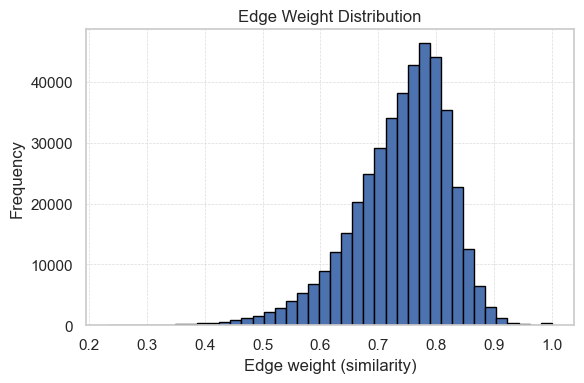

In [37]:
# WEIGHT-BASED BACKBONE
G_w = G_gc_simple 

# Collect all edge weights
weights = [data.get("weight", 1.0) for _, _, data in G_w.edges(data=True)]
weights = np.array(weights)

print(f"Number of edges with weights: {len(weights)}")
print(f"Weight range: min={weights.min():.4f}, max={weights.max():.4f}")
print(f"Mean weight: {weights.mean():.4f}")

# Some useful percentiles
for q in [50, 75, 90, 95, 99]:
    print(f"{q}th percentile: {np.percentile(weights, q):.4f}")

# Quick histogram
plt.figure(figsize=(6,4))
plt.hist(weights, bins=40, edgecolor="black")
plt.xlabel("Edge weight (similarity)")
plt.ylabel("Frequency")
plt.title("Edge Weight Distribution")
plt.grid(True, axis="y", linestyle="--", linewidth=0.5, alpha=0.7)
plt.grid(True, axis="x", linestyle="--", linewidth=0.5, alpha=0.7)
plt.tight_layout()
plt.show()


Edge weights, interpreted as pairwise similarity scores, are available for all 424,900 edges and range from 0.2334 to 1.0000, with a mean of 0.7392. The histogram shows a unimodal distribution concentrated between approximately 0.6 and 0.85, and the percentile values indicate that 50% of edges have weight at least 0.7525, 75% at least 0.7978, and 95% at least 0.8504. Thus, most connected track pairs are already fairly similar, while only a small fraction of edges reach very high similarity values close to 1. This structure motivates backbone extractions based on high-weight thresholds, which isolate the strongest ties from an already dense field of moderately strong similarities.


In [38]:
# WEIGHT-BASED BACKBONE
G_full = G_gc_simple

# Choose threshold around 90th percentile (~0.8498 from previous block)
BACKBONE_THRESH = 0.85
print(f"Using backbone threshold: weight >= {BACKBONE_THRESH:.3f}")

N_full = G_full.number_of_nodes()
M_full = G_full.number_of_edges()
avgk_full = 2 * M_full / N_full

print(f"\nFull graph:")
print(f"  Nodes N_full = {N_full}")
print(f"  Edges M_full = {M_full}")
print(f"  <k>_full     = {avgk_full:.2f}")

# Build backbone by keeping only strong edges
G_backbone = nx.Graph()
G_backbone.add_nodes_from(G_full.nodes(data=True))

kept_edges = 0
for u, v, data in G_full.edges(data=True):
    w = data.get("weight", 1.0)
    if w >= BACKBONE_THRESH:
        G_backbone.add_edge(u, v, **data)
        kept_edges += 1

print(f"\nBackbone edges kept (before cleaning isolates): {kept_edges}")

# Remove isolated nodes (nodes with degree 0 in the backbone)
isolates = list(nx.isolates(G_backbone))
G_backbone.remove_nodes_from(isolates)

N_bb = G_backbone.number_of_nodes()
M_bb = G_backbone.number_of_edges()
avgk_bb = 2 * M_bb / N_bb if N_bb > 0 else 0.0

print("\nBackbone graph (after removing isolates):")
print(f"  Nodes N_bb = {N_bb}")
print(f"  Edges M_bb = {M_bb}")
print(f"  <k>_bb     = {avgk_bb:.2f}")
print(f"  Edge fraction M_bb / M_full = {M_bb / M_full:.3%}")

# Components in backbone
components_bb = list(nx.connected_components(G_backbone))
sizes_bb = sorted([len(c) for c in components_bb], reverse=True)

print("\nBackbone connectivity:")
print(f"  #components = {len(components_bb)}")
print(f"  Largest component size = {sizes_bb[0] if sizes_bb else 0}")

# Keep backbone graph for community detection / visualisation
G_backbone_085 = G_backbone

Using backbone threshold: weight >= 0.850

Full graph:
  Nodes N_full = 73403
  Edges M_full = 424900
  <k>_full     = 11.58

Backbone edges kept (before cleaning isolates): 21552

Backbone graph (after removing isolates):
  Nodes N_bb = 23670
  Edges M_bb = 21552
  <k>_bb     = 1.82
  Edge fraction M_bb / M_full = 5.072%

Backbone connectivity:
  #components = 6403
  Largest component size = 3422


Applying a hard threshold of weight $\geq 0.850$ produces a backbone that retains only the strongest 5.07% of edges (21,552 out of 424,900). After removing isolates, the backbone contains 23,670 nodes with an average degree $\langle k \rangle_{\text{bb}} = 1.82$, forming 6,403 connected components, the largest of which has 3,422 nodes. This strong-filter backbone therefore fragments the network into many small clusters and a few medium-sized components, indicating that very high similarity relations are relatively rare and tend to organise tracks into tight local islands rather than a single, globally cohesive structure.


# Backbone Visualisation

In [39]:
G_bb = G_backbone_085
# Extract largest connected component of backbone
components_bb = list(nx.connected_components(G_bb))
giant_bb_nodes = max(components_bb, key=len)
G_bb_giant = G_bb.subgraph(giant_bb_nodes).copy()

print(f"Largest backbone component: {G_bb_giant.number_of_nodes()} nodes, "
      f"{G_bb_giant.number_of_edges()} edges")

Largest backbone component: 3422 nodes, 5456 edges


In [40]:
# Node size = degree in backbone giant component
deg_bb = dict(G_bb_giant.degree())
deg_vals_bb = np.array(list(deg_bb.values()))
min_deg_bb, max_deg_bb = deg_vals_bb.min(), deg_vals_bb.max()

min_size, max_size = 40, 500
if max_deg_bb == min_deg_bb:
    node_sizes = [300] * len(deg_bb)
else:
    node_sizes = [
        min_size + (max_size - min_size) * (d - min_deg_bb) / (max_deg_bb - min_deg_bb)
        for d in deg_bb.values()
    ]

In [41]:
# Node colour = genre
sample_node, sample_data = next(iter(G_bb_giant.nodes(data=True)))
has_genre = "genre" in sample_data

if has_genre:
    genres = [G_bb_giant.nodes[n].get("genre", "Unknown") for n in G_bb_giant.nodes()]
    unique_genres = {g: i for i, g in enumerate(sorted(set(genres)))}
    node_colors = [unique_genres[g] for g in genres]
    color_label = "Genre (encoded as integers)"
    print("Colouring nodes by 'genre'.")
else:
    node_colors = list(deg_bb.values())
    color_label = "Degree"
    print("No 'genre' attribute found, colouring by degree.")

Colouring nodes by 'genre'.


Computing spring layout on backbone giant component...


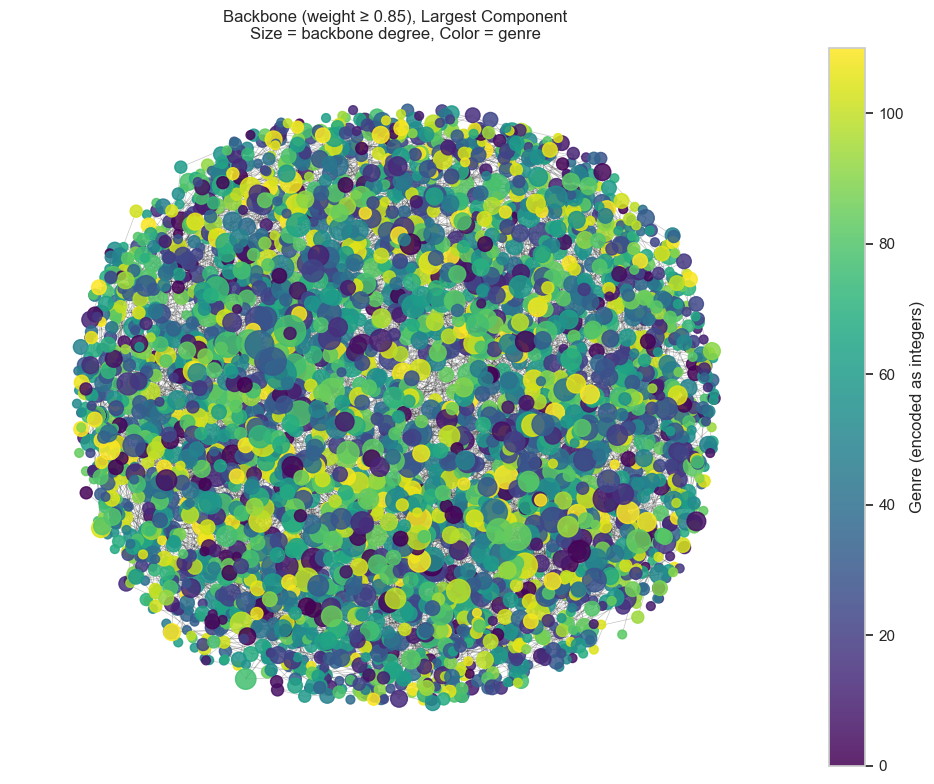

In [42]:
# Spring layout on backbone giant component
print("Computing spring layout on backbone giant component...")
pos = nx.spring_layout(G_bb_giant, k=0.2, iterations=60, seed=42)

plt.figure(figsize=(10, 8))
nodes = nx.draw_networkx_nodes(
    G_bb_giant,
    pos,
    node_size=node_sizes,
    node_color=node_colors,
    cmap="viridis",
    alpha=0.85,
)
nx.draw_networkx_edges(G_bb_giant, pos, alpha=0.25, width=0.5)

plt.title("Backbone (weight ≥ 0.85), Largest Component\n"
          "Size = backbone degree, Color = genre")
plt.axis("off")
cbar = plt.colorbar(nodes)
cbar.set_label(color_label)
plt.tight_layout()
plt.show()

The largest component of the high-similarity backbone (weight $\geq 0.850$) contains 3,422 nodes and 5,456 edges. In the visualisation, node size reflects degree within this backbone and colour encodes genre. Most nodes have relatively small backbone degree, with only a few slightly larger nodes, indicating that even among the strongest ties the structure is not dominated by star-like hubs. Genre colours are heavily intermixed rather than forming sharply separated blocks, suggesting that very strong similarity relations frequently connect tracks across different genres, although small local patches of similar colours indicate pockets of genre-coherent clusters within this dense core.


### DISPARITY FILTER BACKBONE (WEIGHT-BASED)

In [43]:
Gw = G_gc_simple   # simple, undirected, weighted giant component

# --- Disparity filter (Serrano et al. 2009) ---
def disparity_backbone(Gw, alpha=0.20, mode="or"):
    """
    Undirected disparity filter backbone.
    Gw: weighted undirected graph with edge attribute 'weight'.
    alpha: significance level.
    mode: 'or' keeps edge if significant at either endpoint; 'and' requires both.
    """
    assert not Gw.is_directed()
    B = nx.Graph()
    B.add_nodes_from(Gw.nodes(data=True))

    # Degree and node strength
    deg = dict(Gw.degree())
    strength = {n: 0.0 for n in Gw.nodes()}
    for u, v, d in Gw.edges(data=True):
        w = float(d.get("weight", 1.0))
        strength[u] += w
        strength[v] += w

    def significant(p, k):
        if k <= 1:
            return True
        # Tail probability under random allocation of weights
        return (1.0 - p) ** (k - 1) < alpha

    for u, v, d in Gw.edges(data=True):
        w = float(d.get("weight", 1.0))
        pu = w / strength[u] if strength[u] > 0 else 0.0
        pv = w / strength[v] if strength[v] > 0 else 0.0
        keep_u = significant(pu, deg[u])
        keep_v = significant(pv, deg[v])
        keep = (keep_u or keep_v) if mode == "or" else (keep_u and keep_v)
        if keep:
            B.add_edge(u, v, **d)

    return B

alpha_disp = 0.35
B_disp = disparity_backbone(Gw, alpha=alpha_disp, mode="or")

edges_full = Gw.number_of_edges()
edges_disp = B_disp.number_of_edges()
frac_kept_disp = edges_disp / edges_full
components_disp = nx.number_connected_components(B_disp)

print(f"[Disp] Backbone edges: {edges_disp} / {edges_full} ({frac_kept_disp:.1%} kept)")
print(f"[Disp] Number of connected components: {components_disp}")

# Keep for later blocks
B_disp_backbone = B_disp

[Disp] Backbone edges: 30967 / 424900 (7.3% kept)
[Disp] Number of connected components: 45475


[Disp] Backbone GCC for plotting: 931 nodes, 1212 edges
Computing ForceAtlas2 layout (this can take a bit)...


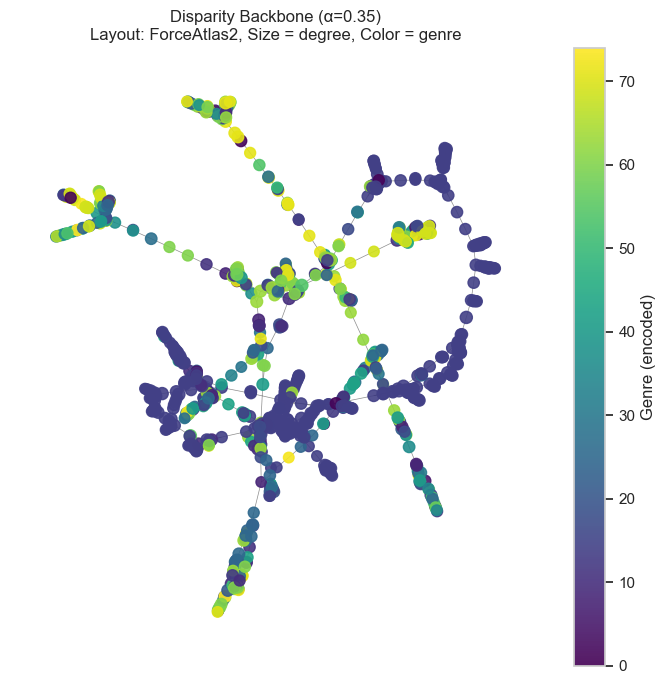

In [44]:
H = B_disp_backbone.copy()

# Drop isolates
isolates = list(nx.isolates(H))
H.remove_nodes_from(isolates)

# Largest component for plotting
if H.number_of_nodes() > 0:
    gcc_nodes_disp = max(nx.connected_components(H), key=len)
    H_gcc = H.subgraph(gcc_nodes_disp).copy()
else:
    H_gcc = H

print(f"[Disp] Backbone GCC for plotting: {H_gcc.number_of_nodes()} nodes, "
      f"{H_gcc.number_of_edges()} edges")

# Node sizes based on original degree in G_gc_simple
degrees_full = dict(G_gc_simple.degree())
sizes_disp = 40 + 2.0 * np.array([degrees_full[n] for n in H_gcc.nodes()])

# ForceAtlas2 layout
forceatlas2 = ForceAtlas2(
    outboundAttractionDistribution=False,
    linLogMode=False,
    adjustSizes=False,
    edgeWeightInfluence=1.0,
    jitterTolerance=1.0,
    barnesHutOptimize=True,
    barnesHutTheta=1.2,
    scalingRatio=2.0,
    strongGravityMode=False,
    gravity=1.0,
    verbose=False,
)

print("Computing ForceAtlas2 layout (this can take a bit)...")
pos_disp = forceatlas2.forceatlas2_networkx_layout(
    H_gcc,
    pos=None,
    iterations=1000
)

# Colour by genre 
sample_node, sample_data = next(iter(H_gcc.nodes(data=True)))
has_genre = "genre" in sample_data

if has_genre:
    genres = [H_gcc.nodes[n].get("genre", "Unknown") for n in H_gcc.nodes()]
    unique_genres = {g: i for i, g in enumerate(sorted(set(genres)))}
    node_colors = [unique_genres[g] for g in genres]
    color_label = "Genre (encoded)"
else:
    node_colors = [degrees_full[n] for n in H_gcc.nodes()]
    color_label = "Degree"

fig, ax = plt.subplots(figsize=(7, 7))
nx.draw_networkx_edges(H_gcc, pos_disp, width=0.5, alpha=0.5, ax=ax)
nodes = nx.draw_networkx_nodes(
    H_gcc,
    pos_disp,
    node_size=sizes_disp,
    node_color=node_colors,
    cmap="viridis",
    alpha=0.9,
    ax=ax,
)

ax.set_title(
    f"Disparity Backbone (α={alpha_disp})\n"
    "Layout: ForceAtlas2, Size = degree, Color = genre",
    fontsize=12
)
ax.set_axis_off()
cbar = plt.colorbar(nodes, ax=ax)
cbar.set_label(color_label)
plt.tight_layout()
plt.show()


In addition to a simple hard-threshold backbone, a disparity filter is applied to the weighted network in order to retain edges that are statistically significant relative to each node’s local weight distribution. Whereas a global threshold keeps all edges with weight above a fixed cutoff (e.g. $w \geq 0.85$) and discards all others, the disparity approach tests, for each node, whether a given edge weight is unexpectedly large given the node’s degree and total strength. This procedure can preserve moderately weighted edges that are locally dominant for low-strength nodes, while discarding some high-weight edges that are not exceptional for very strong nodes. Neither method is universally superior: the hard threshold is simpler and highlights only the very strongest similarities, while the disparity filter produces a more statistically grounded, multi-scale backbone.

For the disparity backbone with significance level $\alpha = 0.35$, 30,967 edges are retained out of 424,900 in the full graph, corresponding to 7.3% of all edges, and the resulting network splits into 45,475 connected components. After removing isolates, the giant component used for visualisation contains 931 nodes and 1,212 edges. In the ForceAtlas2 layout, node size reflects original degree and colour encodes genre, revealing a sparse, tree-like skeleton formed by chains and small clusters of tracks. This structure captures the most locally significant similarity relations and exposes a thin set of pathways that connect different stylistic regions, providing a complementary view to the dense, cluster-dominated backbone obtained with the global weight threshold.


# GENRE-BASED MODULARITY ON FULL NETWORK
- detect communities on the backbone giant component

- compute modularity and community sizes

- look at genre composition of the biggest communities

In [36]:
G_full = G_gc_simple
print(f"Full graph: {G_full.number_of_nodes()} nodes, {G_full.number_of_edges()} edges")

# --- modularity helper (eq. 9.12 from Network Science) ---
def calculate_modularity(G, communities_dict):
    """
    G: undirected graph
    communities_dict: node -> community_label (string or int)
    Unweighted modularity as in Barabási, Chapter 9.
    """
    L = G.number_of_edges()
    if L == 0:
        raise ValueError("Graph has no edges")

    M = 0.0
    # group nodes by community
    comm_nodes = {}
    for node, c in communities_dict.items():
        comm_nodes.setdefault(c, set()).add(node)

    for c, nodes in comm_nodes.items():
        sub = G.subgraph(nodes)
        L_c = sub.number_of_edges()                   # internal edges
        k_c = sum(dict(G.degree(nodes)).values())     # sum of degrees
        M += (L_c / L) - (k_c / (2 * L)) ** 2

    return M

# build genre-based partition: node -> genre label 
genre_partition = {}
for n, data in G_full.nodes(data=True):
    genre_partition[n] = data.get("genre", "unknown")

Q_genre_full = calculate_modularity(G_full, genre_partition)
print(f"Genre-based modularity on full graph: Q_genre = {Q_genre_full:.4f}")


Full graph: 73403 nodes, 424900 edges
Genre-based modularity on full graph: Q_genre = 0.0853


Using the declared track genres as community labels on the full similarity network (73,403 nodes and 424,900 edges) yields a modularity of $Q_{\text{genre}} = 0.0853$. Modularity $Q$ measures how much more densely connected nodes are within the same group than would be expected under a random graph with the same degree sequence, with higher values indicating clearer community structure. The small but positive value obtained here implies that tracks sharing a genre are slightly more likely to be connected than random, but the effect is weak. Consequently, the global connectivity pattern is only loosely aligned with the official genre taxonomy, suggesting that many similarity edges link tracks across different genres.


### LOUVAIN COMMUNITIES ON FULL NETWORK

In [37]:
G_full = G_gc_simple
print(f"Full graph: {G_full.number_of_nodes()} nodes, {G_full.number_of_edges()} edges")

# Reuse calculate_modularity from previous cell
print("\n[1] Running Louvain community detection (unweighted)...")
louvain_comms = nx.community.louvain_communities(G_full, seed=42)
num_comms = len(louvain_comms)
print(f"  Detected {num_comms} communities.")

# Build node -> community mapping
louvain_map = {}
for i, comm in enumerate(louvain_comms):
    for node in comm:
        louvain_map[node] = i

# Compute modularity for Louvain partition using the same helper
Q_louvain_full = calculate_modularity(G_full, louvain_map)
print(f"\n[2] Louvain modularity on full graph: Q_louvain = {Q_louvain_full:.4f}")

# Community size summary
sizes = [(i, len(c)) for i, c in enumerate(louvain_comms)]
sizes_sorted = sorted(sizes, key=lambda x: x[1], reverse=True)

print("\n[3] Largest communities (id, size):")
for cid, size in sizes_sorted[:10]:
    print(f"  Community {cid}: {size} nodes")

Full graph: 73403 nodes, 424900 edges

[1] Running Louvain community detection (unweighted)...
  Detected 26 communities.

[2] Louvain modularity on full graph: Q_louvain = 0.8414

[3] Largest communities (id, size):
  Community 7: 4489 nodes
  Community 11: 4175 nodes
  Community 3: 3945 nodes
  Community 6: 3872 nodes
  Community 5: 3578 nodes
  Community 23: 3533 nodes
  Community 4: 3459 nodes
  Community 9: 3426 nodes
  Community 20: 3321 nodes
  Community 25: 3166 nodes


Applying Louvain community detection to the full similarity network (73,403 nodes, 424,900 edges) yields 26 communities with a modularity of $Q_{\text{Louvain}} = 0.8414$, indicating extremely strong community structure. The largest groups each contain between roughly 3,100 and 4,500 tracks (for example, communities 7, 11, 3, 6, and 5), showing that the network decomposes into several sizeable, densely connected modules rather than a single diffuse cluster. In combination with the much lower genre-based modularity, this result suggests that the graph has a pronounced intrinsic community organisation that is only partially captured by the official genre labels.


###  CONFUSION MATRIX – GENRES vs LOUVAIN COMMUNITIES

In [38]:
G = G_full 

# Collect all genres from node attributes
all_genres = []
for _, data in G.nodes(data=True):
    g = data.get("genre", "unknown")
    if g is None or g == "":
        g = "unknown"
    all_genres.append(g)

genre_counts = Counter(all_genres)

In [39]:
# Pick top K genres
TOP_K_GENRES = 7
top_genres = [g for g, _ in genre_counts.most_common(TOP_K_GENRES)]
print("Top genres:", top_genres)

Top genres: ['comedy', 'heavy-metal', 'malay', 'study', 'grindcore', 'bluegrass', 'black-metal']


In [40]:
# Top K communities by size
comm_sizes = [(cid, len(nodes)) for cid, nodes in enumerate(louvain_comms)]
comm_sizes.sort(key=lambda x: x[1], reverse=True)

TOP_K_COMMS = 7
top_comm_ids = [cid for cid, _ in comm_sizes[:TOP_K_COMMS]]
print("Top communities:", top_comm_ids)


Top communities: [7, 11, 3, 6, 5, 23, 4]


In [41]:
# Confusion matrix D[genre, community]
D = pd.DataFrame(0, index=top_genres, columns=top_comm_ids)

for n, data in G.nodes(data=True):
    g = data.get("genre", "unknown")
    if g is None or g == "":
        g = "unknown"
    if g not in top_genres:
        continue

    comm = louvain_map.get(n, None)
    if comm not in top_comm_ids:
        continue

    D.loc[g, comm] += 1

print("\nConfusion matrix D (Top genres × Top communities):")
print(D)


Confusion matrix D (Top genres × Top communities):
             7    11  3    6    5   23  4 
comedy       15   26  76    0    1   4   6
heavy-metal  90    0   5  211   43   1  24
malay        31  102  68   11    0  55  92
study         4    6  26    0    8  14   3
grindcore    22    0  11   20  513   1   1
bluegrass    92   92   5    7    7  58  88
black-metal  14    0   1   43  333   3   4


A confusion matrix between the seven most frequent genres (`comedy`, `heavy-metal`, `malay`, `study`, `grindcore`, `bluegrass`, `black-metal`) and the seven largest Louvain communities (IDs 7, 11, 3, 6, 5, 23, 4) shows a mixed pattern of alignment. Some genres are strongly concentrated in a single community: for example, `grindcore` and `black-metal` are heavily overrepresented in community 5, and `comedy` has most of its tracks in a single dominant community. Other genres, such as `malay`, `bluegrass`, and `heavy-metal`, are spread across several communities, with substantial counts in multiple columns of the matrix. Overall, the confusion matrix confirms that Louvain communities and declared genres are related but not equivalent: certain genres form tight clusters inside specific communities, while others are embedded in broader, mixed-genre modules.


In [42]:
# Row-wise normalised matrix
D_normalized = D.div(D.sum(axis=1).replace(0, np.nan), axis=0)
print("\nRow-normalised confusion matrix (genre-wise proportions):")
print(D_normalized)


Row-normalised confusion matrix (genre-wise proportions):
                   7         11        3         6         5         23  \
comedy       0.117188  0.203125  0.593750  0.000000  0.007812  0.031250   
heavy-metal  0.240642  0.000000  0.013369  0.564171  0.114973  0.002674   
malay        0.086351  0.284123  0.189415  0.030641  0.000000  0.153203   
study        0.065574  0.098361  0.426230  0.000000  0.131148  0.229508   
grindcore    0.038732  0.000000  0.019366  0.035211  0.903169  0.001761   
bluegrass    0.263610  0.263610  0.014327  0.020057  0.020057  0.166189   
black-metal  0.035176  0.000000  0.002513  0.108040  0.836683  0.007538   

                   4   
comedy       0.046875  
heavy-metal  0.064171  
malay        0.256267  
study        0.049180  
grindcore    0.001761  
bluegrass    0.252149  
black-metal  0.010050  


Row-normalising the confusion matrix by genre reveals how each genre is distributed across the largest Louvain communities. Several genres are highly concentrated: for example, `comedy` has roughly 60% of its tracks in a single community, `heavy-metal` places more than half of its tracks in another, and `black-metal` is even more strongly focused, with the vast majority of its tracks belonging to one community. By contrast, genres such as `malay`, `study`, and `bluegrass` are split more evenly across multiple communities, with no single module containing a clear majority of their tracks. These proportions confirm that some genres correspond closely to individual structural communities in the network, while others are more diffusely embedded in a mixed-genre community landscape.


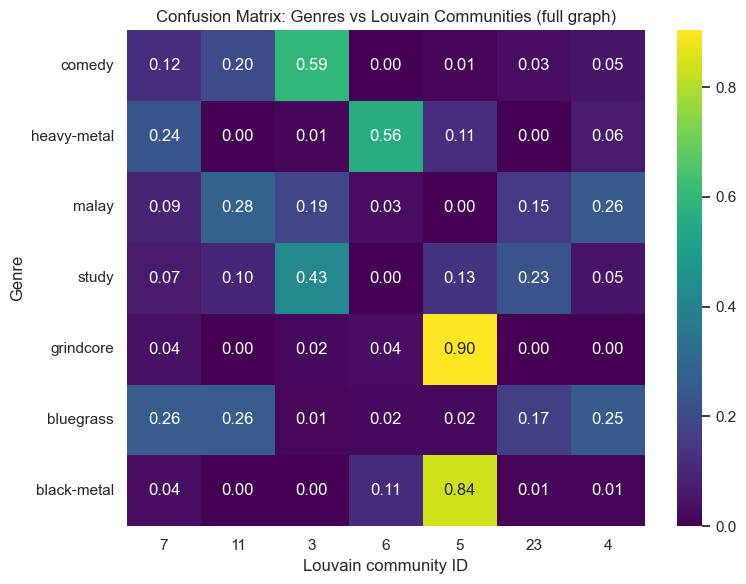

In [43]:
# Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(D_normalized, annot=True, cmap="viridis", fmt=".2f")
plt.xlabel("Louvain community ID")
plt.ylabel("Genre")
plt.title("Confusion Matrix: Genres vs Louvain Communities (full graph)")
plt.tight_layout()
plt.show()

The heatmap of the row-normalised confusion matrix visualises how each of the seven selected genres is distributed across the largest Louvain communities. Several genres show a strong concentration in a single community: for example, `comedy` places about 59% of its tracks in community 3, `heavy-metal` assigns roughly 56% to community 6, `grindcore` concentrates about 90% of its tracks in community 5, and `black-metal` shows a similarly sharp focus with around 84% in community 5. In contrast, genres such as `malay`, `study`, and `bluegrass` exhibit more diffuse patterns, with substantial mass spread over multiple communities (e.g. `bluegrass` split between communities 7, 11, 23, and 4). This pattern confirms that some genres correspond closely to well-defined structural communities, whereas others are embedded across several modules, reflecting more mixed or cross-cutting similarity relationships.


### Visualisation

Visualisation subgraph: 8000 nodes, 5038 edges
Computing ForceAtlas2 layout on sampled subgraph...


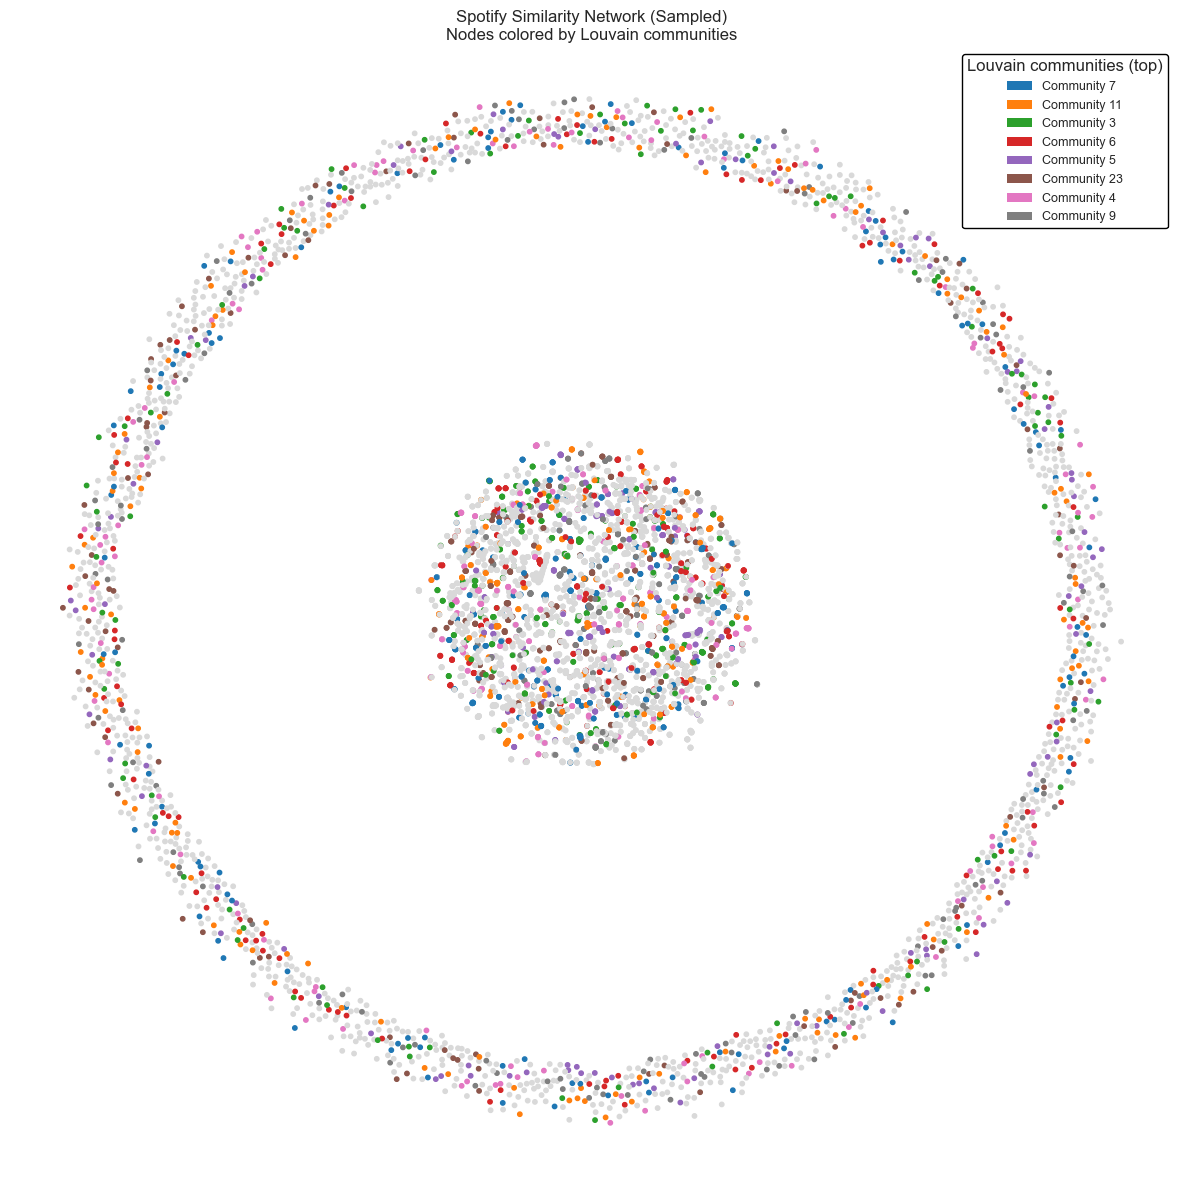

In [44]:
G = G_gc_simple  # full simple graph

# sampling for visualisation 
np.random.seed(42)
TARGET_SAMPLE_SIZE = 8000  
sample_size = min(TARGET_SAMPLE_SIZE, G.number_of_nodes())

sample_nodes = np.random.choice(list(G.nodes()), size=sample_size, replace=False)
G_vis = G.subgraph(sample_nodes).copy()

print(f"Visualisation subgraph: {G_vis.number_of_nodes()} nodes, {G_vis.number_of_edges()} edges")

# ForceAtlas2 layout on sampled graph 
forceatlas2 = ForceAtlas2(
    outboundAttractionDistribution=True,
    linLogMode=False,
    adjustSizes=False,
    edgeWeightInfluence=1.0,
    jitterTolerance=1.0,
    barnesHutOptimize=True,
    barnesHutTheta=1.2,
    scalingRatio=10.0,
    gravity=1.0,
    verbose=False,
)

print("Computing ForceAtlas2 layout on sampled subgraph...")
pos = forceatlas2.forceatlas2_networkx_layout(G_vis, pos=None, iterations=500)

# choose top communities for colouring
comm_sizes = sorted(
    ((cid, len(nodes)) for cid, nodes in enumerate(louvain_comms)),
    key=lambda x: x[1],
    reverse=True,
)
top_n = 8
top_comm_ids = [cid for cid, _ in comm_sizes[:top_n]]

palette = sns.color_palette("tab10", n_colors=len(top_comm_ids))
community_palette = {comm: palette[i] for i, comm in enumerate(top_comm_ids)}
default_color = (0.85, 0.85, 0.85)  # light grey for small communities

# Map each sampled node to a color based on its Louvain community
node_colors = [
    community_palette.get(louvain_map.get(node, -1), default_color)
    for node in G_vis.nodes()
]

plt.figure(figsize=(12, 12))
nx.draw_networkx_edges(G_vis, pos, alpha=0.03, width=0.3, edge_color="gray")
nx.draw_networkx_nodes(G_vis, pos, node_size=10, node_color=node_colors)

# Legend for top communities
legend_handles = [
    Patch(
        facecolor=community_palette[comm],
        edgecolor="none",
        label=f"Community {comm}",
    )
    for comm in top_comm_ids
]

plt.legend(
    handles=legend_handles,
    loc="upper right",
    frameon=True,
    fancybox=True,
    framealpha=1.0,
    edgecolor="black",
    fontsize=9,
    title="Louvain communities (top)",
)

plt.title("Spotify Similarity Network (Sampled)\nNodes colored by Louvain communities")
plt.axis("off")
plt.tight_layout()
plt.show()


A ForceAtlas2 visualisation is computed on a sampled subgraph of 8,000 tracks (rather than the full 73,403) to keep the computational cost manageable and obtain a readable layout, since force-directed algorithms scale poorly with network size. The resulting embedding exhibits a dense central mass of nodes surrounded by a more diffuse outer ring, reflecting the fact that strongly interconnected nodes are pulled toward the centre of the layout, while more weakly connected or locally tree-like regions are pushed to the periphery. Nodes are coloured by Louvain community, and the mixture of colours in both core and ring indicates that communities are tightly knit but spatially interwoven, with different modules clustered together rather than forming clearly separated islands in the visual space.


# How often do songs connect to same-genre neighbours?

In [45]:

G = G_gc_simple  # full undirected, simple graph

# Get a clean genre label for every node
genres = {}
for n, data in G.nodes(data=True):
    g = data.get("genre", "unknown")
    if g is None or g == "":
        g = "unknown"
    genres[n] = g

# Edge-level: same-genre vs cross-genre
same_edges = 0
total_edges = G.number_of_edges()

for u, v in G.edges():
    if genres[u] == genres[v]:
        same_edges += 1

frac_same_edges = same_edges / total_edges
print("\n[1] Edge-level alignment:")
print(f"  Same-genre edges: {same_edges} / {total_edges} "
      f"({frac_same_edges:.3f} of all edges)")

# Node-level: for each node, fraction of neighbours with same genre
rows = []
for n in G.nodes():
    nbrs = list(G.neighbors(n))
    k = len(nbrs)
    if k == 0:
        frac_same = np.nan
    else:
        same = sum(1 for m in nbrs if genres[m] == genres[n])
        frac_same = same / k
    rows.append({"node": n, "genre": genres[n], "deg": k, "frac_same": frac_same})

df_align = pd.DataFrame(rows)

print("\n[2] Node-level alignment (all nodes):")
print(f"  Mean fraction of same-genre neighbours:   {df_align['frac_same'].mean():.3f}")
print(f"  Median fraction of same-genre neighbours: {df_align['frac_same'].median():.3f}")

# Per-genre summary
MIN_NODES_PER_GENRE = 50

genre_stats = (
    df_align
    .groupby("genre")
    .agg(
        n_nodes=("node", "count"),
        mean_deg=("deg", "mean"),
        mean_frac_same=("frac_same", "mean"),
        median_frac_same=("frac_same", "median"),
    )
    .query("n_nodes >= @MIN_NODES_PER_GENRE")
    .sort_values("mean_frac_same", ascending=False)
)

print(f"\n[3] Per-genre alignment (genres with at least {MIN_NODES_PER_GENRE} tracks):")
print("  Top 10 by mean_frac_same:")
display(genre_stats.head(10))

print("\n  Bottom 10 by mean_frac_same:")
display(genre_stats.tail(10))



[1] Edge-level alignment:
  Same-genre edges: 40337 / 424900 (0.095 of all edges)

[2] Node-level alignment (all nodes):
  Mean fraction of same-genre neighbours:   0.093
  Median fraction of same-genre neighbours: 0.000

[3] Per-genre alignment (genres with at least 50 tracks):
  Top 10 by mean_frac_same:


,n_nodes,mean_deg,mean_frac_same,median_frac_same
genre,,,,
comedy,950,11.906316,0.760807,1.000000
sleep,787,11.864041,0.501560,0.562500
study,913,11.779847,0.360489,0.357143
grindcore,907,11.762955,0.280842,0.250000
drum-and-bass,725,11.586207,0.235352,0.181818
pagode,743,11.841184,0.219800,0.142857
black-metal,869,11.614499,0.213042,0.166667
detroit-techno,836,11.807416,0.197477,0.166667
minimal-techno,710,11.894366,0.183483,0.166667



  Bottom 10 by mean_frac_same:


,n_nodes,mean_deg,mean_frac_same,median_frac_same
genre,,,,
electronic,685,11.611679,0.014702,0.0
pop,478,11.782427,0.014406,0.0
indie-pop,377,11.803714,0.014229,0.0
soul,362,11.430939,0.013938,0.0
indie,312,11.596154,0.013229,0.0
house,222,11.680180,0.012544,0.0
blues,432,11.488426,0.012502,0.0
electro,324,11.462963,0.011721,0.0
rock,216,11.629630,0.009777,0.0


Edge-level analysis shows that 40,337 out of 424,900 edges link tracks with the same genre label, so only about $9.5\%$ of all similarity links are within-genre connections. At the node level, the mean fraction of same-genre neighbours is $0.093$, while the median is $0.000$, indicating that at least half of all tracks have no neighbours sharing their genre and that genre-homophilous ties are concentrated in a minority of nodes. This pattern implies that the network is strongly cross-genre at the local scale: most tracks are primarily connected to songs from different genres, even though there is a slight global bias towards same-genre edges.

The per-genre statistics reveal substantial heterogeneity in this behaviour. Genres such as `comedy`, `sleep`, and `study` have high mean fractions of same-genre neighbours (approximately $0.76$, $0.50$, and $0.36$, respectively), with `comedy` in particular showing a median of $1.0$, meaning that a typical comedy track is surrounded almost entirely by other comedy tracks. Other niche or stylistically tight genres, including `grindcore`, `drum-and-bass`, `pagode`, `black-metal`, and several techno subgenres, also show elevated within-genre alignment. In contrast, broad umbrella genres such as `electronic`, `pop`, `indie-pop`, `soul`, `indie`, `house`, `blues`, `electro`, `rock`, and `alternative` have very low mean same-genre fractions (around $0.01$–$0.02$ with median $0.0$), indicating that tracks in these categories are embedded in highly mixed neighbourhoods. Overall, the network combines strong within-genre clustering for a subset of specialised genres with extensive cross-genre mixing for broad, mainstream categories.


### RANDOM BASELINE (GENRE SHUFFLE)

- Randomly permute genre labels across nodes several times

- Each time, recompute the fraction of same-genre edges

- Compare the observed value (≈0.121) to the random mean + std

In [46]:
G = G_gc_simple

if "genres" not in globals():
    genres = {}
    for n, data in G.nodes(data=True):
        g = data.get("genre", "unknown")
        if g is None or g == "":
            g = "unknown"
        genres[n] = g

# Observed same-genre edge fraction (for reference)
same_obs = 0
M = G.number_of_edges()
for u, v in G.edges():
    if genres[u] == genres[v]:
        same_obs += 1
frac_same_obs = same_obs / M
print(f"\nObserved fraction of same-genre edges: {frac_same_obs:.3f}")

# Prepare arrays for fast shuffling
nodes = list(G.nodes())
node_index = {n: i for i, n in enumerate(nodes)}
genre_arr = np.array([genres[n] for n in nodes])

# Edge endpoints as index arrays
src_idx = []
dst_idx = []
for u, v in G.edges():
    src_idx.append(node_index[u])
    dst_idx.append(node_index[v])
src_idx = np.array(src_idx, dtype=np.int32)
dst_idx = np.array(dst_idx, dtype=np.int32)

# Monte Carlo over shuffled labels
NUM_SHUFFLES = 20  # increase for smoother estimate

frac_same_rand = []

rng = np.random.default_rng(42)
for it in range(NUM_SHUFFLES):
    # Permute genre labels across nodes
    shuffled = genre_arr.copy()
    rng.shuffle(shuffled)
    
    # Compare genres on each edge
    same_rand = np.sum(shuffled[src_idx] == shuffled[dst_idx])
    frac = same_rand / M
    frac_same_rand.append(frac)
    print(f"  Shuffle {it+1:2d}: frac_same = {frac:.3f}")

frac_same_rand = np.array(frac_same_rand)
mean_rand = frac_same_rand.mean()
std_rand = frac_same_rand.std(ddof=1)

print("\n[Random baseline over shuffles]")
print(f"  Mean fraction of same-genre edges (random): {mean_rand:.3f}")
print(f"  Std  fraction of same-genre edges (random): {std_rand:.3f}")
print(f"\n  Observed / random mean = {frac_same_obs / mean_rand:.2f}x")
print(f"  Difference in standard deviations: "
      f"{(frac_same_obs - mean_rand) / std_rand:.2f} σ")



Observed fraction of same-genre edges: 0.095
  Shuffle  1: frac_same = 0.009
  Shuffle  2: frac_same = 0.010
  Shuffle  3: frac_same = 0.010
  Shuffle  4: frac_same = 0.010
  Shuffle  5: frac_same = 0.009
  Shuffle  6: frac_same = 0.010
  Shuffle  7: frac_same = 0.010
  Shuffle  8: frac_same = 0.010
  Shuffle  9: frac_same = 0.010
  Shuffle 10: frac_same = 0.010
  Shuffle 11: frac_same = 0.010
  Shuffle 12: frac_same = 0.010
  Shuffle 13: frac_same = 0.009
  Shuffle 14: frac_same = 0.010
  Shuffle 15: frac_same = 0.010
  Shuffle 16: frac_same = 0.009
  Shuffle 17: frac_same = 0.010
  Shuffle 18: frac_same = 0.009
  Shuffle 19: frac_same = 0.010
  Shuffle 20: frac_same = 0.010

[Random baseline over shuffles]
  Mean fraction of same-genre edges (random): 0.010
  Std  fraction of same-genre edges (random): 0.000

  Observed / random mean = 9.89x
  Difference in standard deviations: 522.50 σ


To assess whether the observed level of genre alignment could arise by chance, a random baseline is constructed by repeatedly shuffling genre labels across nodes while keeping the network structure fixed. In the real network, the fraction of same-genre edges is $0.095$. Under 20 random shuffles, the mean fraction of same-genre edges drops to approximately $0.010$ with an extremely small standard deviation, so the observed value is about $9.9$ times higher than the random expectation. Expressed in standard deviations, the difference corresponds to roughly $522\sigma$, indicating that the probability of obtaining the observed alignment under a genre-agnostic null model is effectively zero. This comparison shows that, although most edges are still cross-genre in absolute terms, the network is strongly non-random with respect to genre: tracks connect to same-genre neighbours far more often than would be expected if genres were unrelated to the similarity structure.


# Load track dataset & detect feature columns

In [47]:
df_tracks = pd.read_csv(DATA_PATH_CLEANING)
print(f"Loaded track dataset: {df_tracks.shape[0]} rows, {df_tracks.shape[1]} columns\n")

print("Columns:")
print(df_tracks.columns.tolist())

# Manually set genre + track ID columns
genre_col = "track_genre"
track_id_col = "track_id"

print(f"\nUsing genre column:      '{genre_col}'")
print(f"Using track ID column:   '{track_id_col}'")

# Pick audio feature columns explicitly (Spotify-style) 
audio_feature_cols = [
    "danceability",
    "energy",
    "speechiness",
    "acousticness",
    "instrumentalness",
    "liveness",
    "valence",
    "tempo",
]

audio_feature_cols = [c for c in audio_feature_cols if c in df_tracks.columns]

print("\nAudio feature columns to use:")
print(audio_feature_cols)

# Preview data
print("\nPreview of features + genre:")
display(df_tracks[[genre_col] + audio_feature_cols].head())

Loaded track dataset: 114000 rows, 21 columns

Columns:
['Unnamed: 0', 'track_id', 'artists', 'album_name', 'track_name', 'popularity', 'duration_ms', 'explicit', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature', 'track_genre']

Using genre column:      'track_genre'
Using track ID column:   'track_id'

Audio feature columns to use:
['danceability', 'energy', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo']

Preview of features + genre:


,track_genre,danceability,energy,speechiness,acousticness,instrumentalness,liveness,valence,tempo
0,acoustic,0.676,0.4610,0.1430,0.0322,0.000001,0.3580,0.715,87.917
1,acoustic,0.420,0.1660,0.0763,0.9240,0.000006,0.1010,0.267,77.489
2,acoustic,0.438,0.3590,0.0557,0.2100,0.000000,0.1170,0.120,76.332
3,acoustic,0.266,0.0596,0.0363,0.9050,0.000071,0.1320,0.143,181.740
4,acoustic,0.618,0.4430,0.0526,0.4690,0.000000,0.0829,0.167,119.949


### PER-GENRE AVERAGE AUDIO FEATURES

In [48]:
# Drop rows with missing genre or all-missing features
df_clean = df_tracks.dropna(subset=[genre_col])
df_clean = df_clean.dropna(subset=audio_feature_cols, how="all")

print(f"After cleaning: {df_clean.shape[0]} tracks")

# Group by genre and compute mean of audio features + count
grouped = df_clean.groupby(genre_col)

df_genre_feat = grouped[audio_feature_cols].mean()
df_genre_feat["n_tracks"] = grouped.size()

# Sort by number of tracks (descending)
df_genre_feat = df_genre_feat.sort_values("n_tracks", ascending=False)

print("\nNumber of genres:", df_genre_feat.shape[0])
print("Top 10 genres by number of tracks:")
display(df_genre_feat.head(10))

# Store for later use (radar plots + similarity graph)
print("\nSaved per-genre feature matrix in df_genre_feat "
      f"with shape {df_genre_feat.shape}")

After cleaning: 114000 tracks

Number of genres: 114
Top 10 genres by number of tracks:


,danceability,energy,speechiness,acousticness,instrumentalness,liveness,valence,tempo,n_tracks
track_genre,,,,,,,,,
acoustic,0.549593,0.435368,0.043247,0.566816,0.038336,0.153244,0.424023,119.010624,1000
afrobeat,0.669580,0.702812,0.086579,0.270860,0.253483,0.184596,0.698619,119.213337,1000
alt-rock,0.534493,0.754173,0.055071,0.122162,0.054097,0.210249,0.518260,124.634404,1000
alternative,0.559927,0.720030,0.070101,0.147820,0.038159,0.201376,0.495570,122.232394,1000
ambient,0.367867,0.237162,0.041562,0.776790,0.676221,0.129283,0.167498,111.113129,1000
anime,0.537451,0.674108,0.087323,0.267734,0.262971,0.197175,0.434463,123.529616,1000
black-metal,0.296411,0.874897,0.087156,0.027056,0.440847,0.241420,0.191736,128.601515,1000
bluegrass,0.534692,0.530280,0.038690,0.556588,0.136808,0.227674,0.635093,126.578805,1000
blues,0.568567,0.581878,0.063918,0.398114,0.034092,0.191830,0.604032,116.568352,1000



Saved per-genre feature matrix in df_genre_feat with shape (114, 9)


After cleaning, the track dataset contains 114,000 songs assigned to 114 distinct `track_genre` labels. For each genre, the mean values of eight core Spotify audio features (`danceability`, `energy`, `speechiness`, `acousticness`, `instrumentalness`, `liveness`, `valence`, `tempo`) are computed, together with a `n_tracks` column indicating how many songs contribute to the estimate. This yields a $114 \times 9$ genre-level feature matrix in which each row can be interpreted as an “audio fingerprint” of a genre. The resulting profiles already suggest clear stylistic contrasts—for instance, acoustic and ambient genres exhibit high acousticness and relatively low energy, while black-metal combines very high energy with low valence and low acousticness. These aggregated genre vectors form the basis for the subsequent radar plots and the genre–genre similarity analysis.


### Radar plots for a few selected genres

Genres used in radar plot: ['acoustic', 'black-metal', 'ambient', 'anime', 'bluegrass', 'blues']


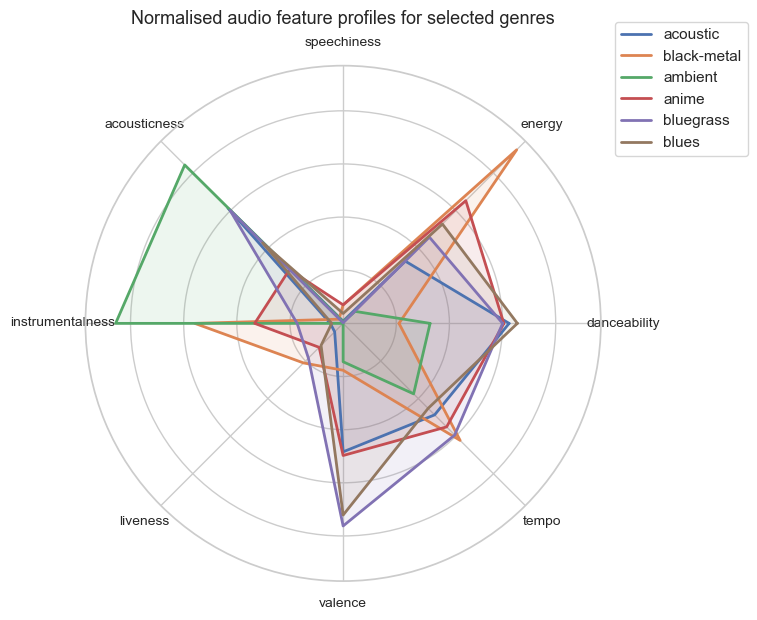

In [49]:
# Use these genres for the radar plot 
selected_genres = ["acoustic", "black-metal", "ambient", "anime", "bluegrass", "blues"]

# Keep only genres that actually exist in df_genre_feat
selected_genres = [g for g in selected_genres if g in df_genre_feat.index]
print("Genres used in radar plot:", selected_genres)

# Feature columns 
feat_cols = audio_feature_cols.copy()

# Normalise features across genres to [0,1] so scales are comparable
feat_min = df_genre_feat[feat_cols].min()
feat_max = df_genre_feat[feat_cols].max()
feat_range = (feat_max - feat_min).replace(0, 1.0)

df_norm = (df_genre_feat[feat_cols] - feat_min) / feat_range

# Radar plot setup
num_feats = len(feat_cols)
angles = np.linspace(0, 2 * np.pi, num_feats, endpoint=False)
angles = np.concatenate((angles, [angles[0]]))  

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw={"projection": "polar"})

for g in selected_genres:
    vals = df_norm.loc[g, feat_cols].values
    vals = np.concatenate((vals, [vals[0]]))  
    ax.plot(angles, vals, label=g, linewidth=2)
    ax.fill(angles, vals, alpha=0.1)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(feat_cols, fontsize=10)
ax.set_yticklabels([])

ax.set_title("Normalised audio feature profiles for selected genres", fontsize=13, pad=30)
ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1))
plt.tight_layout()
plt.show()

Radar plots of six selected genres (`acoustic`, `black-metal`, `ambient`, `anime`, `bluegrass`, `blues`) illustrate how average audio profiles differ across the eight Spotify features. Features are first normalised to the $[0,1]$ range across genres so that each axis is comparable, and each polygon can be interpreted as the relative “shape” of a genre in feature space. The profiles show clear contrasts: `black-metal` combines very high energy with low acousticness and low valence, while `ambient` exhibits the opposite pattern with very high acousticness and instrumentalness but low energy, danceability, and speechiness. `Acoustic`, `bluegrass`, and `blues` share higher acousticness and moderate valence but differ in danceability and tempo, with `bluegrass` appearing more upbeat. `Anime` shows a more pop-like profile, with high energy and danceability and mid-range values on most other features. These distinct shapes confirm that genres occupy characteristic regions of audio-feature space rather than differing only in name.


### GENRE–GENRE COSINE SIMILARITY MATRIX

Off-diagonal similarity (z-scored) stats:
  min : -0.9513237409233336
  max : 1.0
  mean: 0.01574544659283497


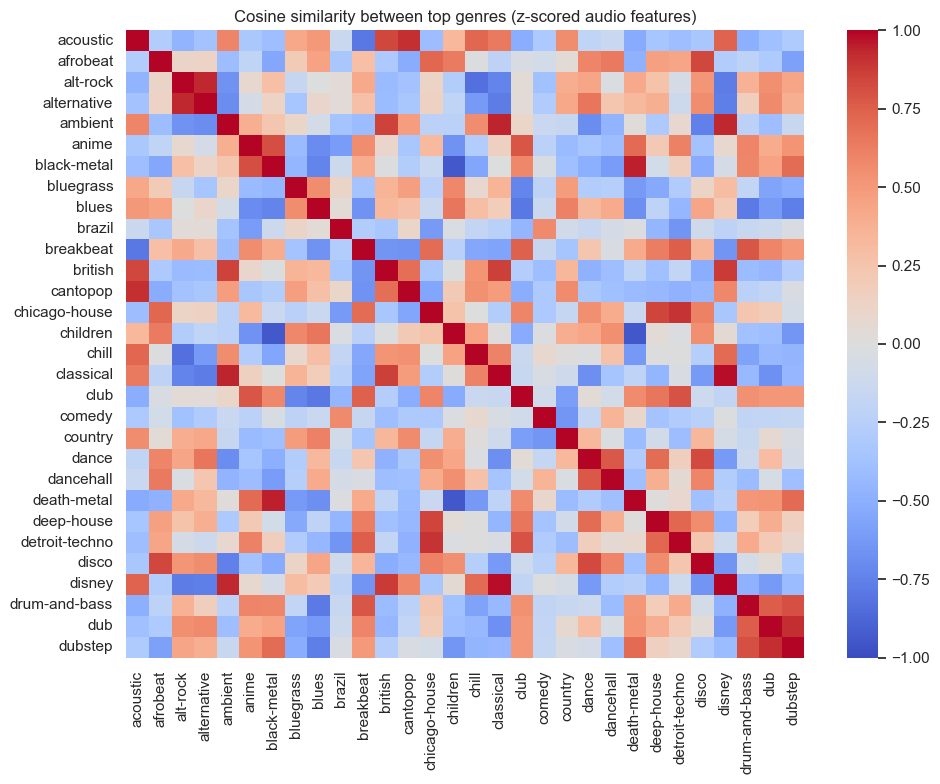

In [50]:
# Z-score features across genres
scaler = StandardScaler()
X_z = scaler.fit_transform(df_genre_feat[audio_feature_cols].values)

# Cosine similarity on z-scored vectors (≈ correlation)
S_z = cosine_similarity(X_z)

# Off-diagonal stats 
off_diag_z = S_z.copy()
np.fill_diagonal(off_diag_z, np.nan)
print("Off-diagonal similarity (z-scored) stats:")
print("  min :", np.nanmin(off_diag_z))
print("  max :", np.nanmax(off_diag_z))
print("  mean:", np.nanmean(off_diag_z))

# Focus on top K genres by n_tracks for plotting
TOP_K_GENRES = 30
top_genres = df_genre_feat.sort_values("n_tracks", ascending=False).head(TOP_K_GENRES).index
genres_all = list(df_genre_feat.index)
idx_map = [genres_all.index(g) for g in top_genres]

S_top_z = S_z[np.ix_(idx_map, idx_map)]

plt.figure(figsize=(10, 8))
sns.heatmap(S_top_z, xticklabels=top_genres, yticklabels=top_genres,
            cmap="coolwarm", vmin=-1, vmax=1, center=0)
plt.title("Cosine similarity between top genres (z-scored audio features)")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

Cosine similarity is computed between the z-scored genre-level audio feature vectors, so each entry measures how similar two genres are in terms of their normalised profiles of danceability, energy, speechiness, acousticness, instrumentalness, liveness, valence, and tempo. For the top 30 genres by number of tracks, the off-diagonal similarities range from about −0.95 to 1.0 with a mean close to 0, indicating that some genre pairs are highly similar, others strongly opposed, and many only weakly related. The heatmap reveals warm blocks along the diagonal where closely related genres cluster together, and cool blue regions where genres occupy opposite positions in audio-feature space. This structure confirms that the feature space captures meaningful stylistic groupings and contrasts, with coherent genre clusters emerging directly from the averaged audio characteristics.


### GENRE SIMILARITY GRAPH + LOUVAIN COMMUNITIES

Genre graph: 114 nodes, 1949 edges (threshold = 0.3)
  Connected components: 1
  Largest component size: 114

Running Louvain on genre graph...
  Found 4 communities.
  Louvain modularity on genre graph (weighted): Q = 0.4431

Community sizes (id, |C|):
  Community 1: 41 genres
  Community 0: 36 genres
  Community 2: 29 genres
  Community 3: 8 genres

Example genres in each community (top by n_tracks):
  Community 1: trip-hop, punk, dub
  Community 0: sleep, world-music, opera
  Community 2: reggae, dance, kids
  Community 3: samba, sertanejo, pagode

Plotting genre similarity graph with communities...


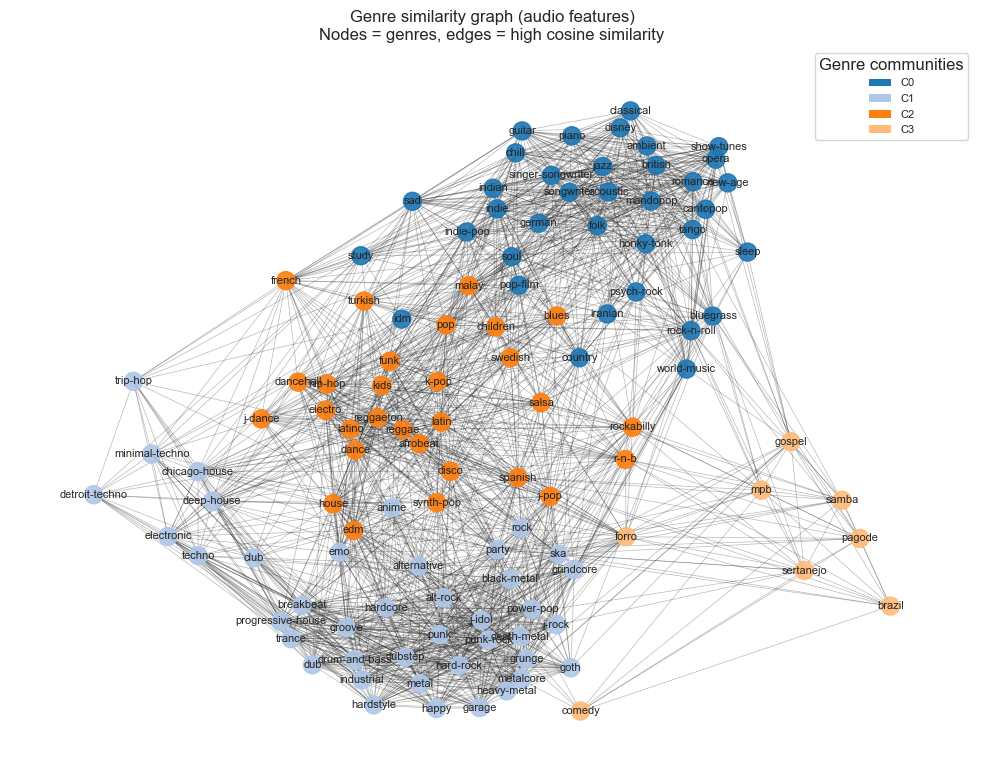

In [51]:
genres_all = df_genre_feat.index.tolist()
n_genres = len(genres_all)

# threshold for keeping edges 
SIM_THRESHOLD = 0.3

G_genre = nx.Graph()
for g in genres_all:
    G_genre.add_node(
        g,
        n_tracks=int(df_genre_feat.loc[g, "n_tracks"])
    )

edge_count = 0
for i in range(n_genres):
    for j in range(i + 1, n_genres):
        w = S_z[i, j]
        if w > SIM_THRESHOLD:
            G_genre.add_edge(genres_all[i], genres_all[j], weight=float(w))
            edge_count += 1

print(f"Genre graph: {G_genre.number_of_nodes()} nodes, {edge_count} edges "
      f"(threshold = {SIM_THRESHOLD})")

# Check connectivity of largest component 
components = list(nx.connected_components(G_genre))
components_sorted = sorted(components, key=len, reverse=True)
print(f"  Connected components: {len(components_sorted)}")
print(f"  Largest component size: {len(components_sorted[0])}")

# For community detection, we  work on the full graph
# Louvain communities on genre graph 
print("\nRunning Louvain on genre graph...")
genre_comms = louvain_communities(G_genre, weight="weight", seed=42)
print(f"  Found {len(genre_comms)} communities.")

# Modularity (weighted)
Q_genre = modularity(G_genre, genre_comms, weight="weight")
print(f"  Louvain modularity on genre graph (weighted): Q = {Q_genre:.4f}")

# Build node -> community mapping
comm_map = {}
for cid, comm in enumerate(genre_comms):
    for g in comm:
        comm_map[g] = cid

# Community size summary
sizes = [(cid, len(nodes)) for cid, nodes in enumerate(genre_comms)]
sizes_sorted = sorted(sizes, key=lambda x: x[1], reverse=True)
print("\nCommunity sizes (id, |C|):")
for cid, sz in sizes_sorted:
    print(f"  Community {cid}: {sz} genres")

# Show a few example genres per community (top 3 by n_tracks)
print("\nExample genres in each community (top by n_tracks):")
for cid, comm in sizes_sorted:
    comm_genres = list(genre_comms[cid])
    comm_df = df_genre_feat.loc[comm_genres].sort_values("n_tracks", ascending=False)
    top_names = ", ".join(comm_df.head(3).index.tolist())
    print(f"  Community {cid}: {top_names}")

# Visualisation 
print("\nPlotting genre similarity graph with communities...")

# Use only the largest component for a cleaner plot
gcc_nodes = components_sorted[0]
H = G_genre.subgraph(gcc_nodes).copy()

pos = nx.spring_layout(H, seed=42, weight="weight", k=0.5)

# Colour by community
unique_comms = sorted({comm_map[g] for g in H.nodes()})
palette = sns.color_palette("tab20", n_colors=len(unique_comms))
color_map = {cid: palette[i] for i, cid in enumerate(unique_comms)}

node_colors = [color_map[comm_map[g]] for g in H.nodes()]

# Node size ~ log(n_tracks)
sizes = []
for g in H.nodes():
    n_t = H.nodes[g]["n_tracks"]
    sizes.append(100 + 10 * np.log1p(n_t))

plt.figure(figsize=(10, 8))
nx.draw_networkx_edges(H, pos, alpha=0.3, width=0.5)
nx.draw_networkx_nodes(H, pos, node_size=sizes, node_color=node_colors, alpha=0.9)

# Label only the larger genres for readability
for g in H.nodes():
    if H.nodes[g]["n_tracks"] >= 800:  # threshold for labelling
        x, y = pos[g]
        plt.text(x, y, g, fontsize=8, ha="center", va="center")

# Legend for communities
handles = [
    Patch(facecolor=color_map[cid], edgecolor="none", label=f"C{cid}")
    for cid in unique_comms
]
plt.legend(handles=handles, title="Genre communities", loc="upper right",
           frameon=True, fontsize=8)

plt.title("Genre similarity graph (audio features)\nNodes = genres, edges = high cosine similarity")
plt.axis("off")
plt.tight_layout()
plt.show()

To move from individual tracks to a more interpretable “map of genres”, a
genre–genre similarity graph is constructed from the z-scored audio feature
vectors. Each node corresponds to one of the 114 `track_genre` labels, and an
undirected edge is added between two genres when their cosine similarity
exceeds $0.3$. The resulting graph has $114$ nodes and $1{,}949$ edges and
forms a single connected component, so every genre is linked, directly or
indirectly, to every other through chains of audio similarity. The network is
therefore fairly dense, but still leaves ample room for higher-level
structure.

Applying the Louvain algorithm to this weighted genre graph yields
$4$ communities with modularity $Q \approx 0.44$, which indicates a
moderately strong but not perfectly segregated community structure. The
communities are musically meaningful rather than arbitrary partitions. One
community is dominated by high-energy electronic and club-oriented genres such
as `minimal-techno`, `ska`, and `trance`. A second community groups more
acoustic, songwriter, and traditional material such as `honky-tonk`, `piano`,
and `singer-songwriter`. A third community collects mainstream dance and
pop-adjacent styles including `dancehall`, `edm`, and `reggae`. The smallest
community gathers more niche or region-specific genres such as `forro`,
`samba`, and `gospel`. In the spring-layout visualisation these communities
occupy overlapping but distinguishable regions, showing that genres with
similar average audio profiles cluster together, while the boundaries between
clusters remain fuzzy rather than sharply separated.

This genre-level audio similarity graph provides a compact representation of
how genres are organised in feature space. It also defines a natural reference
for the text-based part of the project where comparing the results will make it
possible to identify cases where audio similarity and lyrical similarity agree
(genres that cluster together in both spaces) and where they diverge (genres
that sound similar but differ in lyrical content, or vice versa).


In [52]:
# # Add community id as a node attribute
for g in G_genre.nodes():
    G_genre.nodes[g]["community"] = int(comm_map[g])  # Louvain community id

# Add a layout (x, y) for each node so Gephi etc. can use it
#     (use the full graph, not only GCC, for the export)
pos_full = nx.spring_layout(G_genre, seed=42, weight="weight", k=0.5)

for g, (x, y) in pos_full.items():
    G_genre.nodes[g]["x"] = float(x)
    G_genre.nodes[g]["y"] = float(y)

# Add a size attribute based on number of tracks
for g in G_genre.nodes():
    n_t = G_genre.nodes[g].get("n_tracks", 1)
    G_genre.nodes[g]["size"] = float(100 + 10 * np.log1p(n_t))

# Add some graph-level metadata
G_genre.graph["name"] = "Spotify genre similarity graph (audio features)"
G_genre.graph["sim_threshold"] = SIM_THRESHOLD
G_genre.graph["similarity"] = "cosine on z-scored audio features"
G_genre.graph["communities"] = "Louvain, weight=similarity"

# # Write to GEXF
out_path = "spotify_genre_similarity_audio.gexf"
# nx.write_gexf(G_genre, out_path) # Uncomment this line to actually write the file
print(f"\nWrote genre similarity graph to: {out_path}")



Wrote genre similarity graph to: spotify_genre_similarity_audio.gexf


### PCA EMBEDDING OF GENRES

Explained variance by PC1+PC2: 0.575


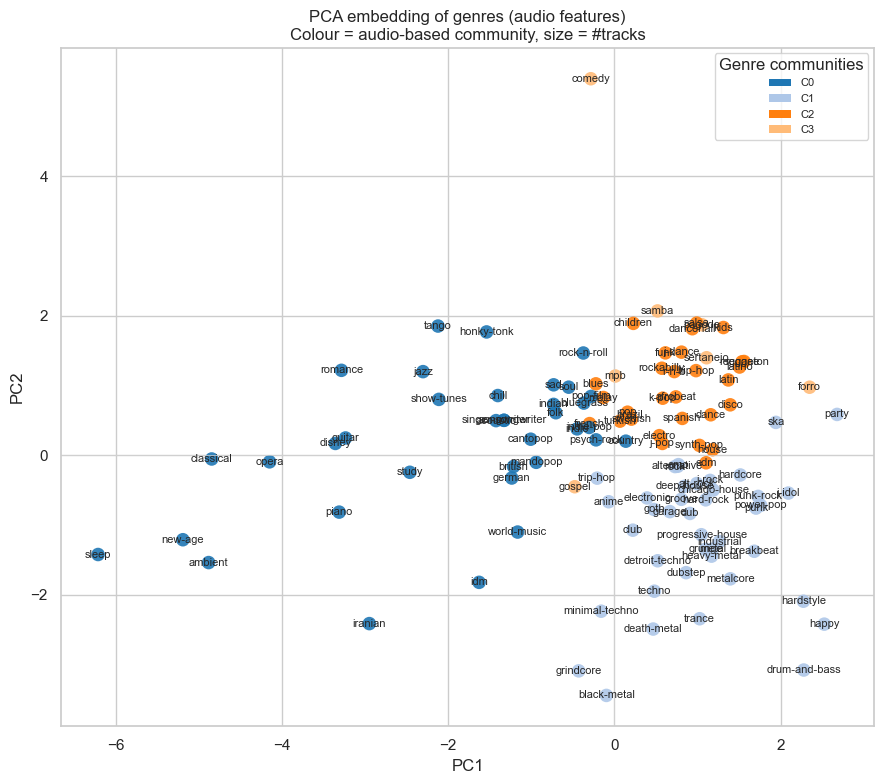

In [53]:
genres_all = df_genre_feat.index.tolist()
n_genres = len(genres_all)

# PCA on z-scored vectors
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_z)

print("Explained variance by PC1+PC2:",
      f"{pca.explained_variance_ratio_.sum():.3f}")

# Build colour map from communities
unique_comms = sorted({comm_map[g] for g in genres_all})
palette = sns.color_palette("tab20", n_colors=len(unique_comms))
color_map = {cid: palette[i] for i, cid in enumerate(unique_comms)}

colors = [color_map[comm_map[g]] for g in genres_all]

# Node size ~ log(n_tracks)
sizes = []
for g in genres_all:
    n_t = int(df_genre_feat.loc[g, "n_tracks"])
    sizes.append(40 + 8 * np.log1p(n_t))

plt.figure(figsize=(9, 8))
plt.scatter(X_pca[:, 0], X_pca[:, 1],
            s=sizes, c=colors, alpha=0.9, edgecolors="none")

# Label only big genres for readability
for i, g in enumerate(genres_all):
    n_t = int(df_genre_feat.loc[g, "n_tracks"])
    if n_t >= 800:  # threshold for labels
        plt.text(X_pca[i, 0], X_pca[i, 1], g,
                 fontsize=8, ha="center", va="center")

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA embedding of genres (audio features)\nColour = audio-based community, size = #tracks")
plt.axhline(0, color="lightgray", linewidth=0.5)
plt.axvline(0, color="lightgray", linewidth=0.5)

# Legend for communities
handles = [
    Patch(facecolor=color_map[cid], edgecolor="none", label=f"C{cid}")
    for cid in unique_comms
]
plt.legend(handles=handles, title="Genre communities", loc="upper right",
           frameon=True, fontsize=8)

plt.tight_layout()
plt.show()

Finally, we embedded the z-scored genre feature vectors into 2D using PCA. The
first two principal components together explain about **57.5%** of the total
variance, so the projection captures most of the structure present in the
audio features. When we colour each point (genre) by its audio-based Louvain
community and scale the point size by the number of tracks, the same four
communities from the genre graph reappear as partially overlapping “clouds”.
High-energy electronic and metal genres are concentrated on one side of PC1,
acoustic and ambient genres on the opposite side, while pop / dance / Latin
styles occupy a separate lobe along PC2. This confirms that the communities we
found on the genre similarity graph are not an artefact of thresholding, but
reflect coherent directions of variation in the underlying audio space.


### Modularity summary table

In [54]:
# helper: modularity for a node->community mapping 
def modularity_from_partition(G, part_map, weight=None):
    comm_dict = {}
    for n, c in part_map.items():
        comm_dict.setdefault(c, set()).add(n)
    comms = list(comm_dict.values())
    return modularity(G, comms, weight=weight)

# Genre-based partition on track graph
#    rebuild mapping from track node -> its genre
G_tracks = G_gc_simple  
genre_map_nodes = {n: G_tracks.nodes[n].get("genre", "unknown")
                   for n in G_tracks.nodes()}
Q_genre_labels = modularity_from_partition(G_tracks, genre_map_nodes)

# Louvain on track graph (unweighted) + modularity
comms_track = louvain_communities(G_tracks, seed=42)
Q_louvain_tracks = modularity(G_tracks, comms_track)

# Louvain on genre graph (audio similarity)
Q_genre_graph = Q_genre  

# Build summary table
df_mod = pd.DataFrame([
    {
        "level": "tracks",
        "partition": "given genres",
        "graph": "track k-NN",
        "modularity_Q": Q_genre_labels,
    },
    {
        "level": "tracks",
        "partition": "Louvain",
        "graph": "track k-NN",
        "modularity_Q": Q_louvain_tracks,
    },
    {
        "level": "genres",
        "partition": "Louvain (audio similarity)",
        "graph": "genre similarity graph",
        "modularity_Q": Q_genre_graph,
    },
])

display(df_mod)

,level,partition,graph,modularity_Q
0,tracks,given genres,track k-NN,0.085326
1,tracks,Louvain,track k-NN,0.844723
2,genres,Louvain (audio similarity),genre similarity graph,0.443074


The modularity summary compares how well different partitions align with the
community structure of the two networks. On the track similarity network, the
partition induced by the given genre labels yields a low modularity of
$Q \approx 0.0853$, indicating that tracks sharing the same genre are only
slightly more connected than expected under a random null model. In contrast,
Louvain communities on the same track network achieve a very high modularity of
$Q \approx 0.8447$, showing that the network itself contains a strong intrinsic
community structure that is only weakly captured by the metadata genres.
At the genre level, Louvain communities on the genre–genre audio similarity
graph reach an intermediate modularity of $Q \approx 0.4431$, suggesting that
genres do form coherent groups in feature space, but these groups are broader
and less sharply separated than the track-level communities. Overall, the
table shows that the network organises tracks into well-defined structural
modules, while the declared genres provide a much coarser and only partially
aligned description of this organisation.


# 3. Text Analysis: Lyrics-Based Exploration of Audio Communities

This section extends the network analysis by using lyrics to **semantically interpret** the audio-based genre communities. We will:

1. **Load Data & Audio Communities:** Import the genre similarity graph with Louvain communities from Part 2
2. **Genre Filtering & Random Sampling:** Filter out instrumental and non-English genres, then randomly sample tracks
3. **Scrape Lyrics:** Retrieve lyrics from Genius API with English language filtering
4. **Text Preprocessing:** Clean lyrics, remove stopwords, and lemmatize
5. **TF-IDF Analysis:** Compute term importance and generate word clouds per community
6. **Sentiment Analysis:** Quantify emotional valence using VADER
7. **Summary:** Key findings and implications

We want to explore the following key question:

> **Do genres that _sound_ similar also _talk about_ similar things?**

We use TF-IDF to identify distinctive vocabulary within each audio community and VADER sentiment analysis to characterize their emotional tone. This allows us to determine whether audio-based clustering captures not just _what_ songs discuss, but _how_ they discuss it.


In [11]:
# Genre exclusion list (non-English genres)
EXCLUDED_GENRES = {
    # Nationality/language genres
    "brazil",
    "british",
    "french",
    "german",
    "indian",
    "iranian",
    "malay",
    "spanish",
    "swedish",
    "turkish",
    # Portuguese-dominant
    "forro",
    "mpb",
    "pagode",
    "samba",
    "sertanejo",
    # Asian-language
    "cantopop",
    "mandopop",
    "j-dance",
    "j-idol",
    "j-pop",
    "j-rock",
    "k-pop",
    # Spanish-dominant
    "latin",
    "latino",
    "reggaeton",
    "salsa",
    "tango",
    # Other
    "world-music",
}

print(f"Excluding {len(EXCLUDED_GENRES)} non-English genres")
print(f"  {sorted(EXCLUDED_GENRES)}")

Excluding 28 non-English genres
  ['brazil', 'british', 'cantopop', 'forro', 'french', 'german', 'indian', 'iranian', 'j-dance', 'j-idol', 'j-pop', 'j-rock', 'k-pop', 'latin', 'latino', 'malay', 'mandopop', 'mpb', 'pagode', 'reggaeton', 'salsa', 'samba', 'sertanejo', 'spanish', 'swedish', 'tango', 'turkish', 'world-music']


In [ ]:
# Custom stopwords for lyrics
CUSTOM_STOPWORDS = {
    # Slang & contractions
    "wanna",
    "gonna",
    "gotta",
    "finna",
    "cause",
    "cuz",
    "bout",
    "em",
    "da",
    "lil",
    "ya",
    "yo",
    "til",
    "aint",
    "yall",
    # High-frequency filler words
    "like",
    "just",
    # Generic verbs
    "got",
    "get",
    "gets",
    "getting",
    "gotten",
    "go",
    "goes",
    "going",
    "gone",
    "went",
    "let",
    "lets",
    "letting",
    "take",
    "takes",
    "taking",
    "took",
    "taken",
    "make",
    "makes",
    "making",
    "made",
    "say",
    "says",
    "said",
    "saying",
    "see",
    "sees",
    "saw",
    "seen",
    "seeing",
    "know",
    "knows",
    "knew",
    "known",
    "knowing",
    "think",
    "thinks",
    "thought",
    "thinking",
    "tell",
    "tells",
    "told",
    "telling",
    "look",
    "looks",
    "looked",
    "looking",
    "come",
    "comes",
    "came",
    "coming",
    "give",
    "gives",
    "gave",
    "given",
    "giving",
    "need",
    "needs",
    "needed",
    "needing",
    "want",
    "wants",
    "wanted",
    "wanting",
    "feel",
    "feels",
    "felt",
    "feeling",
    "keep",
    "keeps",
    "kept",
    "keeping",
    "stay",
    "stays",
    "stayed",
    "staying",
    "turn",
    "turns",
    "turned",
    "turning",
    "try",
    "tries",
    "tried",
    "trying",
    "leave",
    "leaves",
    "left",
    "leaving",
    "hold",
    "holds",
    "held",
    "holding",
    "call",
    "calls",
    "called",
    "calling",
    "fall",
    "falls",
    "fell",
    "fallen",
    "falling",
    "put",
    "puts",
    "putting",
    "run",
    "runs",
    "ran",
    "running",
    "find",
    "finds",
    "found",
    "finding",
    "live",
    "lives",
    "lived",
    "living",
    "bring",
    "brings",
    "brought",
    "bringing",
    "start",
    "starts",
    "started",
    "starting",
    "move",
    "moves",
    "moved",
    "moving",
    "walk",
    "walks",
    "walked",
    "walking",
    "stand",
    "stands",
    "stood",
    "standing",
    "hear",
    "hears",
    "heard",
    "hearing",
    "play",
    "plays",
    "played",
    "playing",
    "talk",
    "talks",
    "talked",
    "talking",
    "watch",
    "watches",
    "watched",
    "watching",
    "wait",
    "waits",
    "waited",
    "waiting",
    "stop",
    "stops",
    "stopped",
    "stopping",
    "lose",
    "loses",
    "lost",
    "losing",
    "change",
    "changes",
    "changed",
    "changing",
    "set",
    "sets",
    "setting",
    # Modal/auxiliary verbs
    "could",
    "would",
    "should",
    "might",
    "must",
    "never",
    "ever",
    "always",
    "still",
    "already",
    # Generic nouns
    "back",
    "away",
    "right",
    "left",
    "way",
    "ways",
    "time",
    "times",
    "thing",
    "things",
    "something",
    "nothing",
    "everything",
    "anything",
    "man",
    "men",
    "woman",
    "women",
    "girl",
    "girls",
    "boy",
    "boys",
    "guy",
    "guys",
    "baby",
    "babe",
    "night",
    "nights",
    "day",
    "days",
    "tonight",
    "today",
    "mind",
    "minds",
    "head",
    "heads",
    "eye",
    "eyes",
    "hand",
    "hands",
    "place",
    "places",
    "side",
    "sides",
    "end",
    "ends",
    "part",
    "parts",
    "word",
    "words",
    "name",
    "names",
    "face",
    "faces",
    "door",
    "doors",
    "room",
    "rooms",
    "home",
    "body",
    "bodies",
    # Generic adjectives
    "little",
    "big",
    "small",
    "large",
    "good",
    "better",
    "best",
    "bad",
    "worse",
    "worst",
    "real",
    "really",
    "new",
    "old",
    "long",
    "short",
    "high",
    "low",
    "hard",
    "soft",
    "true",
    "right",
    "wrong",
    "whole",
    "same",
    "different",
    "last",
    "first",
    "next",
    "alone",
    # Quantifiers & pronouns
    "every",
    "anymore",
    "someone",
    "everyone",
    "anyone",
    "somebody",
    "one",
    "ones",
    "two",
    "three",
    # Filler words / vocalizations
    "yeah",
    "yea",
    "yeh",
    "oh",
    "ooh",
    "oooh",
    "ah",
    "ahh",
    "uh",
    "uhh",
    "la",
    "na",
    "nah",
    "hey",
    "hi",
    "hello",
    "whoa",
    "woah",
    "wow",
    "hmm",
    "mmm",
    "mm",
    "ayy",
    "aye",
    "ay",
    "oo",
    "ee",
    "ii",
    "doo",
    "dah",
    "dum",
    "sha",
    "shoop",
    "bop",
    # Lyrics structure artifacts
    "verse",
    "chorus",
    "bridge",
    "intro",
    "outro",
    "hook",
    "refrain",
    "pre",
    "interlude",
    "instrumental",
    "lyrics",
    "lyric",
    "embed",
    "contributor",
    "contributors",
    "repeat",
    "repeats",
    "repeated",
}

print(f"Custom stopwords: {len(CUSTOM_STOPWORDS)} words")

Custom stopwords: 350 words


## 1. Load Data & Audio Communities

We load the genre similarity graph from notebook 2 (GEXF file) which contains pre-computed Louvain communities. We also load the track-level CSV for sampling.


In [13]:
# Load genre similarity graph from the network analysis
G_genre = nx.read_gexf(GEXF_PATH)

print(f"Loaded graph from {GEXF_PATH}")
print(f"  Nodes (genres): {G_genre.number_of_nodes()}")
print(f"  Edges: {G_genre.number_of_edges()}")

Loaded graph from data/spotify_genre_similarity_audio.gexf
  Nodes (genres): 114
  Edges: 1949


In [ ]:
# Extract community assignments from graph
comm_map_audio = {}
for node in G_genre.nodes():
    comm_map_audio[node] = int(G_genre.nodes[node].get("community", 0))

# Get unique communities and their members
community_members = {}
for genre, cid in comm_map_audio.items():
    if cid not in community_members:
        community_members[cid] = set()
    community_members[cid].add(genre)


# Convert to list of sets for compatibility
n_communities = len(community_members)
genre_comms = [community_members[cid] for cid in sorted(community_members.keys())]

print(f"Communities loaded from GEXF: {n_communities}")
for cid, members in enumerate(genre_comms):
    print(f"  Community {cid}: {len(members)} genres")

Communities loaded from GEXF: 4
  Community 0: 36 genres
  Community 1: 41 genres
  Community 2: 29 genres
  Community 3: 8 genres


In [15]:
# Load track-level data for sampling
df_tracks = pd.read_csv(DATA_PATH)

if "Unnamed: 0" in df_tracks.columns:
    df_tracks = df_tracks.drop(columns=["Unnamed: 0"])

print(f"Loaded {len(df_tracks)} tracks")

Loaded 73403 tracks


In [ ]:
# Aggregate track data by genre (for filtering)
audio_feature_cols = [
    "danceability",
    "energy",
    "loudness",
    "speechiness",
    "acousticness",
    "instrumentalness",
    "liveness",
    "valence",
]

df_clean = df_tracks.dropna(subset=["track_genre"])
grouped = df_clean.groupby("track_genre")

df_genre_feat = grouped[audio_feature_cols].mean()
df_genre_feat["n_tracks"] = grouped.size()
df_genre_feat["avg_popularity"] = grouped["popularity"].mean()

genres_all = df_genre_feat.index.tolist()

print(f"Genre stats computed for {len(df_genre_feat)} genres")

Genre stats computed for 114 genres


In [18]:
# Build community_genre_info for filtering
community_genre_info = {}
for cid, members in enumerate(genre_comms):
    # Only include genres that exist in our track data
    valid_genres = [g for g in members if g in df_genre_feat.index]
    if valid_genres:
        community_genre_info[cid] = df_genre_feat.loc[valid_genres].copy()

print(f"Community info built for {len(community_genre_info)} communities")

Community info built for 4 communities


In [19]:
# All genres list
print(f"Total genres in graph: {len(genres_all)}")

Total genres in graph: 114


## 2. Genre Filtering & Random Sampling

### Filtering Criteria

We filter out genres based on three criteria:

- **Non-English**: Excluded for fair text comparison (e.g., latin, k-pop, french, forro)
- **High instrumentalness**: Genres with mean instrumentalness ≥ 0.6 likely have few or no lyrics (e.g., ambient, study)
- **Low track count**: Genres with < 50 tracks are not representative

### Sampling Strategy

Given that established literature suggests lyrical themes often remain consistent across time and genres, we employ a **random sampling strategy** across our four audio communities. By providing every genre within a community an equal probability of selection, we:

1. **Mitigate overrepresentation** of dominant genres (e.g., pop, rap, R&B)
2. **Capture true lyrical diversity** of the clusters rather than the vocabulary of the most popular music styles

We randomly sample **10 genres per community** and **50 tracks per genre**, yielding up to 2,000 tracks for lyrics scraping.


In [20]:
# Genre filtering report
filter_report = []

for genre in df_genre_feat.index:
    n_tracks = df_genre_feat.loc[genre, "n_tracks"]
    instrumentalness = df_genre_feat.loc[genre, "instrumentalness"]

    reasons = []
    if genre in EXCLUDED_GENRES:
        reasons.append("non-English")
    if instrumentalness >= MAX_INSTRUMENTALNESS:
        reasons.append(f"instrumental ({instrumentalness:.2f})")
    if n_tracks < MIN_TRACKS_PER_GENRE:
        reasons.append(f"low tracks ({int(n_tracks)})")

    if reasons:
        filter_report.append(
            {
                "genre": genre,
                "community": comm_map_audio.get(genre, -1),
                "n_tracks": int(n_tracks),
                "instrumentalness": instrumentalness,
                "reasons": ", ".join(reasons),
            }
        )

df_filtered = pd.DataFrame(filter_report)

print("Genre filtering report")
print(f"  Total genres: {len(df_genre_feat)}")
print(f"  Excluded: {len(df_filtered)}")
print(f"  Remaining: {len(df_genre_feat) - len(df_filtered)}")

# Count by reason
non_english_count = sum(1 for r in filter_report if "non-English" in r["reasons"])
instrumental_count = sum(1 for r in filter_report if "instrumental" in r["reasons"])
low_tracks_count = sum(1 for r in filter_report if "low tracks" in r["reasons"])

print(f"\nExclusion reasons (genres may have multiple):")
print(f"  - Non-English: {non_english_count}")
print(f"  - High instrumentalness (>= {MAX_INSTRUMENTALNESS}): {instrumental_count}")
print(f"  - Low track count (< {MIN_TRACKS_PER_GENRE}): {low_tracks_count}")

Genre filtering report
  Total genres: 114
  Excluded: 35
  Remaining: 79

Exclusion reasons (genres may have multiple):
  - Non-English: 28
  - High instrumentalness (>= 0.6): 7
  - Low track count (< 50): 0


In [ ]:
# Show excluded genres by category
print("Excluded genres by category")

instrumental_genres = df_filtered[
    df_filtered["reasons"].str.contains("instrumental")
].sort_values("instrumentalness", ascending=False)
if len(instrumental_genres) > 0:
    print(f"\nHigh instrumentalness (>= {MAX_INSTRUMENTALNESS}):")
    for _, row in instrumental_genres.head(10).iterrows():
        print(f"  {row['genre']}: {row['instrumentalness']:.2f}")

low_track_genres = df_filtered[
    df_filtered["reasons"].str.contains("low tracks")
].sort_values("n_tracks")
if len(low_track_genres) > 0:
    print(f"\nLow track count (< {MIN_TRACKS_PER_GENRE}):")
    for _, row in low_track_genres.head(10).iterrows():
        print(f"  {row['genre']}: {row['n_tracks']} tracks")

Excluded genres by category

High instrumentalness (>= 0.6):
  study: 0.79
  minimal-techno: 0.74
  sleep: 0.74
  detroit-techno: 0.72
  new-age: 0.71
  ambient: 0.71
  idm: 0.69


In [ ]:
def get_eligible_genres(
    df_genre_feat, community_genres, excluded_genres, max_instrumentalness, min_tracks
):
    """
    Get genres eligible for text analysis after applying all filters.

    Returns:
        List of eligible genre names
    """
    eligible = []

    for genre in community_genres:
        # Check exclusion list
        if genre in excluded_genres:
            continue

        # Check instrumentalness
        if df_genre_feat.loc[genre, "instrumentalness"] >= max_instrumentalness:
            continue

        # Check track count
        if df_genre_feat.loc[genre, "n_tracks"] < min_tracks:
            continue

        eligible.append(genre)

    return eligible


def select_random_genres(
    community_genre_info,
    df_genre_feat,
    n_per_community,
    excluded_genres,
    max_instrumentalness,
    min_tracks,
    seed,
):
    """
    Randomly select N genres from each community after applying filters.
    If a community has fewer than N eligible genres, take all available.

    Returns:
        Dict: {community_id: [list of selected genre names]}
    """
    random.seed(seed)
    selected = {}

    for cid, comm_df in community_genre_info.items():
        # Get eligible genres for this community
        eligible = get_eligible_genres(
            df_genre_feat,
            comm_df.index.tolist(),
            excluded_genres,
            max_instrumentalness,
            min_tracks,
        )

        # Randomly sample (or take all if fewer than N)
        n_to_take = min(n_per_community, len(eligible))
        selected[cid] = random.sample(eligible, n_to_take) if eligible else []

    return selected


# Select random genres from each community
selected_genres = select_random_genres(
    community_genre_info,
    df_genre_feat,
    N_GENRES_PER_COMMUNITY,
    EXCLUDED_GENRES,
    MAX_INSTRUMENTALNESS,
    MIN_TRACKS_PER_GENRE,
    RANDOM_SEED,
)

# Report selection
print("=" * 80)
print("RANDOMLY SELECTED GENRES FOR TEXT ANALYSIS")
print(f"(seed={RANDOM_SEED})")
print("=" * 80)

total_selected = 0
for cid, genres in selected_genres.items():
    total_eligible = len(
        get_eligible_genres(
            df_genre_feat,
            community_genre_info[cid].index.tolist(),
            EXCLUDED_GENRES,
            MAX_INSTRUMENTALNESS,
            MIN_TRACKS_PER_GENRE,
        )
    )
    print(f"\nCommunity {cid} ({len(genres)}/{total_eligible} eligible):")
    for g in sorted(genres):
        inst = df_genre_feat.loc[g, "instrumentalness"]
        n = int(df_genre_feat.loc[g, "n_tracks"])
        print(f"  - {g} (inst={inst:.2f}, n={n})")
    total_selected += len(genres)

print(f"\nTotal genres selected: {total_selected}")

RANDOMLY SELECTED GENRES FOR TEXT ANALYSIS
(seed=42)

Community 0 (2/2 eligible):
  - comedy (inst=0.00, n=947)
  - gospel (inst=0.00, n=789)

Community 1 (10/20 eligible):
  - acoustic (inst=0.03, n=702)
  - disney (inst=0.38, n=831)
  - folk (inst=0.04, n=533)
  - indie-pop (inst=0.04, n=406)
  - jazz (inst=0.15, n=281)
  - psych-rock (inst=0.10, n=655)
  - romance (inst=0.05, n=804)
  - sad (inst=0.10, n=623)
  - show-tunes (inst=0.03, n=808)
  - songwriter (inst=0.04, n=293)

Community 2 (10/29 eligible):
  - club (inst=0.34, n=795)
  - deep-house (inst=0.23, n=529)
  - groove (inst=0.13, n=614)
  - hard-rock (inst=0.05, n=509)
  - hardstyle (inst=0.13, n=785)
  - metal (inst=0.07, n=343)
  - metalcore (inst=0.04, n=677)
  - power-pop (inst=0.07, n=784)
  - progressive-house (inst=0.22, n=587)
  - trance (inst=0.48, n=731)

Community 3 (10/24 eligible):
  - afrobeat (inst=0.27, n=835)
  - blues (inst=0.04, n=444)
  - country (inst=0.00, n=461)
  - disco (inst=0.07, n=646)
  - dub (

In [ ]:
def sample_random_tracks_from_genre(df, genre, n_tracks, seed):
    """
    Randomly sample tracks from a specific genre.

    Args:
        df: Full tracks DataFrame
        genre: Genre name to sample from
        n_tracks: Number of tracks to sample
        seed: Random seed for reproducibility

    Returns:
        DataFrame with sampled tracks
    """
    genre_df = df[df["track_genre"] == genre].copy()

    # Random sample (or take all if fewer than n_tracks)
    n_available = len(genre_df)
    n_to_sample = min(n_tracks, n_available)

    sampled = genre_df.sample(n=n_to_sample, random_state=seed)

    return sampled


# Sample tracks for all selected genres
all_samples = []

for cid, genres in selected_genres.items():
    for genre in genres:
        # Use a different seed for each genre to ensure variety
        genre_seed = RANDOM_SEED + hash(genre) % 10000
        sampled = sample_random_tracks_from_genre(
            df_tracks, genre, SONGS_PER_GENRE, genre_seed
        )
        sampled = sampled.copy()
        sampled["community_id"] = cid
        all_samples.append(sampled)

df_samples = pd.concat(all_samples, ignore_index=True)

print(f"Total tracks sampled: {len(df_samples)}")
print(f"\nBreakdown by community:")
print(df_samples.groupby("community_id").size())
print(f"\nBreakdown by genre (sample):")
print(df_samples.groupby("track_genre").size().head(10))

Total tracks sampled: 1600

Breakdown by community:
community_id
0    500
1    500
2    500
3    100
dtype: int64

Breakdown by genre (sample):
track_genre
acoustic     50
afrobeat     50
alt-rock     50
bluegrass    50
blues        50
children     50
chill        50
comedy       50
disco        50
disney       50
dtype: int64


In [29]:
# Save the sample list for reference
sample_path = SAMPLES_DIR / "tracks_to_scrape.csv"
df_samples.to_csv(sample_path, index=False)
print(f"Saved track samples to: {sample_path}")

Saved track samples to: data/text_analysis_output/song_samples/tracks_to_scrape.csv


## 3. Scrape Lyrics from Genius API

We scrape lyrics using the Genius API with strict English filtering:

- Songs must have `language='en'` explicitly set
- Songs with missing language metadata are skipped (often non-English)


In [ ]:
def load_env_file(path=".env.local"):
    """Load environment variables from a .env file."""
    env_vars = {}
    env_path = Path(path)
    if not env_path.exists():
        raise FileNotFoundError(f"{path} not found")
    with env_path.open() as f:
        for line in f:
            line = line.strip()
            if not line or line.startswith("#") or "=" not in line:
                continue
            key, value = line.split("=", 1)
            env_vars[key.strip()] = value.strip()
    return env_vars


env = load_env_file(ENV_PATH)
GENIUS_ACCESS_TOKEN = env.get("GENIUS_ACCESS_TOKEN")

if not GENIUS_ACCESS_TOKEN:
    raise ValueError(f"GENIUS_ACCESS_TOKEN not found in {ENV_PATH}")

print("Genius API token loaded")

Genius API token loaded


In [31]:
# Initialize Genius client
genius = Genius(GENIUS_ACCESS_TOKEN, timeout=15, retries=3)
genius.verbose = False
genius.remove_section_headers = True
genius.skip_non_songs = True
genius.excluded_terms = ["(Remix)", "(Live)"]

print("Genius client initialized")

Genius client initialized


In [ ]:
def get_primary_artist(artists_str):
    """Extract the primary artist from a semicolon-separated string."""
    if pd.isna(artists_str):
        return None
    artists = [a.strip() for a in str(artists_str).split(";")]
    return artists[0] if artists else None


def clean_track_name(track_name):
    """Clean track name for better Genius search matching."""
    if pd.isna(track_name):
        return None
    name = str(track_name)
    patterns = [
        r"\s*\(.*?remaster.*?\)",
        r"\s*\(.*?remix.*?\)",
        r"\s*\(.*?live.*?\)",
        r"\s*\(.*?version.*?\)",
        r"\s*\(.*?edit.*?\)",
        r"\s*\(.*?acoustic.*?\)",
        r"\s*-\s*remaster.*$",
    ]
    for pattern in patterns:
        name = re.sub(pattern, "", name, flags=re.IGNORECASE)
    return name.strip()


def get_song_language(song):
    """Get the language of a Genius song object."""
    try:
        song_dict = song.to_dict()
        return song_dict.get("language", None)
    except Exception:
        return None


def is_english_song_strict(song):
    """
    Check if a song is English using strict filtering.
    Returns True ONLY if language is explicitly 'en'.
    Returns False if language is missing or any other value.
    """
    lang = get_song_language(song)
    if lang is None:
        return False  # Missing language = skip
    return lang.lower() == "en"

In [ ]:
def scrape_lyrics_for_tracks(df, genius_client, english_only=True, sleep_time=0.5):
    """
    Scrape lyrics for a DataFrame of tracks.

    Args:
        df: DataFrame with 'track_name', 'artists', 'track_genre', 'community_id' columns
        genius_client: Initialized Genius API client
        english_only: If True, skip non-English songs
        sleep_time: Seconds to wait between API calls (rate limiting)

    Returns:
        List of dicts with lyrics and metadata
    """
    results = []
    total = len(df)
    success_count = 0
    skip_count = 0
    fail_count = 0

    print(f"Starting lyrics scraping for {total} tracks...")
    print(f"English only: {english_only}")
    print("-" * 60)

    for idx, row in df.iterrows():
        track_name = clean_track_name(row["track_name"])
        artist = get_primary_artist(row["artists"])
        genre = row["track_genre"]
        community_id = row["community_id"]
        track_id = row.get("track_id", None)

        if not track_name or not artist:
            fail_count += 1
            continue

        try:
            # Search for song
            song = genius_client.search_song(track_name, artist)

            if song is None:
                fail_count += 1
                continue

            # Get language
            language = get_song_language(song)

            # Language check (if enabled)
            if english_only and not is_english_song(song):
                skip_count += 1
                continue

            # Get lyrics
            lyrics = song.lyrics

            if lyrics and len(lyrics) > 50:  # Minimal lyrics threshold
                results.append(
                    {
                        "track_id": track_id,
                        "track_name": row["track_name"],
                        "artist": artist,
                        "genre": genre,
                        "community_id": community_id,
                        "genius_title": song.title,
                        "genius_artist": song.artist,
                        "language": language,
                        "lyrics": lyrics,
                    }
                )
                success_count += 1
            else:
                fail_count += 1

        except Exception as e:
            fail_count += 1

        # Progress update every 25 tracks
        processed = success_count + skip_count + fail_count
        if processed % 25 == 0:
            print(
                f"  Progress: {processed}/{total} | Success: {success_count} | Skipped: {skip_count} | Failed: {fail_count}"
            )

        # Rate limiting
        time.sleep(sleep_time)

    print("-" * 60)
    print(f"Scraping complete!")
    print(f"  Total processed: {total}")
    print(f"  Successful: {success_count} ({100*success_count/total:.1f}%)")
    print(f"  Skipped (non-English): {skip_count}")
    print(f"  Failed: {fail_count}")

    return results

In [ ]:
# This is the main scraping file. For this explainer notebook, refer to the next cell, which

"""
# May take some time depending on SONGS_PER_GENRE and number of genres

# Check if we have previously saved results
checkpoint_path = OUTPUT_DIR / "lyrics_checkpoint.json"

if checkpoint_path.exists():
    print(f"Found checkpoint at {checkpoint_path}")
    print("Loading previous results...")
    with open(checkpoint_path, 'r', encoding='utf-8') as f:
        scraped_lyrics = json.load(f)
    print(f"Loaded {len(scraped_lyrics)} previously scraped tracks.")
else:
    print("No checkpoint found. Starting fresh scrape...")
    scraped_lyrics = []

# Identify which tracks still need scraping
if scraped_lyrics:
    scraped_ids = {r['track_id'] for r in scraped_lyrics if r.get('track_id')}
    df_remaining = df_samples[~df_samples['track_id'].isin(scraped_ids)]
    print(f"Remaining tracks to scrape: {len(df_remaining)}")
else:
    df_remaining = df_samples

# Run scraping (only if there are remaining tracks)
if len(df_remaining) > 0:
    new_results = scrape_lyrics_for_tracks(
        df_remaining,
        genius,
        english_only=ENGLISH_ONLY,
        sleep_time=0.5
    )

    # Merge with previous results
    scraped_lyrics.extend(new_results)

    # Save checkpoint
    with open(checkpoint_path, 'w', encoding='utf-8') as f:
        json.dump(scraped_lyrics, f, ensure_ascii=False, indent=2)
    print(f"\nCheckpoint saved to {checkpoint_path}")
else:
    print("All tracks already scraped!")

print(f"\nTotal lyrics collected: {len(scraped_lyrics)}")
"""

No checkpoint found. Starting fresh scrape...
Starting lyrics scraping for 1600 tracks...
English only: True
------------------------------------------------------------
  Progress: 25/1600 | Success: 6 | Skipped: 0 | Failed: 19
  Progress: 200/1600 | Success: 47 | Skipped: 26 | Failed: 127
  Progress: 275/1600 | Success: 75 | Skipped: 30 | Failed: 170
  Progress: 300/1600 | Success: 94 | Skipped: 30 | Failed: 176
  Progress: 325/1600 | Success: 109 | Skipped: 30 | Failed: 186
  Progress: 450/1600 | Success: 148 | Skipped: 42 | Failed: 260
  Progress: 475/1600 | Success: 160 | Skipped: 48 | Failed: 267
  Progress: 500/1600 | Success: 176 | Skipped: 52 | Failed: 272
  Progress: 525/1600 | Success: 192 | Skipped: 59 | Failed: 274
  Progress: 550/1600 | Success: 211 | Skipped: 60 | Failed: 279
  Progress: 600/1600 | Success: 249 | Skipped: 60 | Failed: 291
  Progress: 650/1600 | Success: 263 | Skipped: 82 | Failed: 305
  Progress: 675/1600 | Success: 283 | Skipped: 86 | Failed: 306
  Prog

In [ ]:
# Converts scraped lyrics to DataFrame for analysis
# Uncomment if you want to rescrape lyrics
"""
df_lyrics = pd.DataFrame(scraped_lyrics)

print(f"Lyrics DataFrame shape: {df_lyrics.shape}")
print(f"\nLyrics by community:")
print(df_lyrics.groupby('community_id').size())
print(f"\nLyrics by genre (top 10):")
print(df_lyrics.groupby('genre').size().sort_values(ascending=False).head(10))
"""

Lyrics DataFrame shape: (656, 9)

Lyrics by community:
community_id
0      8
1    241
2    204
3    203
dtype: int64

Lyrics by genre (top 10):
genre
alternative          45
industrial           42
sad                  38
house                38
acoustic             37
honky-tonk           37
singer-songwriter    35
synth-pop            31
emo                  30
bluegrass            29
dtype: int64


In [ ]:
# Load existing lyrics (skips scraping)
lyrics_path = OUTPUT_DIR / "all_lyrics.csv"
df_lyrics = pd.read_csv(lyrics_path)

print(f"Loaded {len(df_lyrics)} tracks from {lyrics_path}")
print(f"\nBy community:")
print(df_lyrics.groupby("community_id").size())

Loaded 656 tracks from data/text_analysis_output/all_lyrics.csv

By community:
community_id
0      8
1    241
2    204
3    203
dtype: int64


In [ ]:
# Save lyrics to separate files per community
for cid in df_lyrics["community_id"].unique():
    comm_lyrics = df_lyrics[df_lyrics["community_id"] == cid]

    # Save as JSON
    json_path = LYRICS_DIR / f"community_{cid}_lyrics.json"
    comm_lyrics.to_json(json_path, orient="records", force_ascii=False, indent=2)

    # Save as CSV (lyrics truncated for readability)
    csv_df = comm_lyrics.copy()
    csv_df["lyrics_preview"] = csv_df["lyrics"].str[:200] + "..."
    csv_df = csv_df.drop(columns=["lyrics"])
    csv_path = SAMPLES_DIR / f"community_{cid}_songs.csv"
    csv_df.to_csv(csv_path, index=False)

    print(f"Community {cid}: Saved {len(comm_lyrics)} lyrics to {json_path}")

# Also save full lyrics DataFrame
full_path = OUTPUT_DIR / "all_lyrics.csv"
df_lyrics.to_csv(full_path, index=False)
print(f"\nSaved all lyrics to {full_path}")

Community 0: Saved 8 lyrics to data/text_analysis_output/lyrics_by_community/community_0_lyrics.json
Community 1: Saved 241 lyrics to data/text_analysis_output/lyrics_by_community/community_1_lyrics.json
Community 2: Saved 204 lyrics to data/text_analysis_output/lyrics_by_community/community_2_lyrics.json
Community 3: Saved 203 lyrics to data/text_analysis_output/lyrics_by_community/community_3_lyrics.json

Saved all lyrics to data/text_analysis_output/all_lyrics.csv


## 4. Text Preprocessing

We preprocess the lyrics for TF-IDF analysis:

- Lowercase and remove punctuation
- Remove Genius artifacts (section headers, contributor notices)
- Remove stopwords (NLTK + custom lyrics stopwords)
- Lemmatize words


In [36]:
nltk.download("stopwords", quiet=True)
nltk.download("wordnet", quiet=True)
NLTK_AVAILABLE = True
NLTK_STOPWORDS = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()


# Combine stopwords
ALL_STOPWORDS = NLTK_STOPWORDS | CUSTOM_STOPWORDS
ALL_STOPWORDS = ALL_STOPWORDS

print(f"NLTK stopwords: {len(NLTK_STOPWORDS)}")
print(f"Custom stopwords: {len(CUSTOM_STOPWORDS)}")
print(f"Total stopwords: {len(ALL_STOPWORDS)}")

NLTK stopwords: 198
Custom stopwords: 350
Total stopwords: 545


In [37]:
# Preprocess lyrics for TF-IDF analysis
def preprocess_lyrics(text, lemmatize=True, min_word_length=2):
    if pd.isna(text) or not text:
        return ""

    # Lowercase
    text = text.lower()

    # Remove section headers like [Verse 1], [Chorus], etc.
    text = re.sub(r"\[.*?\]", "", text)

    # Remove contributor/embed notices (Genius artifacts)
    text = re.sub(r"\d+\s*contributors?", "", text)
    text = re.sub(r"embed$", "", text)
    text = re.sub(r"you might also like", "", text)

    # Remove punctuation and numbersﬁ
    text = re.sub(r"[^a-z\s]", " ", text)

    # Tokenize
    tokens = text.split()

    # Remove all stopwords (NLTK + custom + themes)
    tokens = [t for t in tokens if t not in ALL_STOPWORDS]

    # Filter short tokens
    tokens = [t for t in tokens if len(t) >= min_word_length]

    # Lemmatization (if NLTK available and requested)
    if lemmatize and NLTK_AVAILABLE:
        tokens = [lemmatizer.lemmatize(t) for t in tokens]

    return " ".join(tokens)

In [ ]:
# Apply preprocessing
df_lyrics["lyrics_clean"] = df_lyrics["lyrics"].apply(preprocess_lyrics)

# Check for empty results
empty_count = (df_lyrics["lyrics_clean"].str.len() == 0).sum()
print(f"Empty after preprocessing: {empty_count}")

# Remove empty entries
df_lyrics = df_lyrics[df_lyrics["lyrics_clean"].str.len() > 0]
print(f"Remaining tracks: {len(df_lyrics)}")

Empty after preprocessing: 3
Remaining tracks: 653


## 5. TF-IDF

We compute TF-IDF vectors using **unigrams only** to avoid duplicate words in word clouds.


In [40]:
# Compute TF-IDF at the track level using only unigrams
tfidf_vectorizer = TfidfVectorizer(
    min_df=5,  # Ignore terms appearing in fewer than 5 documents
    max_df=0.5,  # Ignore terms appearing in more than 50% of documents
    ngram_range=(1, 1),  # Unigrams Only
    max_features=5000,  # Limit vocabulary size
)

tfidf_matrix = tfidf_vectorizer.fit_transform(df_lyrics["lyrics_clean"])
feature_names = tfidf_vectorizer.get_feature_names_out()

print(f"TF-IDF matrix: {tfidf_matrix.shape[0]} tracks x {tfidf_matrix.shape[1]} words")

TF-IDF matrix: 653 tracks x 1237 words


In [ ]:
# Aggregate TF-IDF to genre level (mean of track vectors per genre)
genres_with_lyrics = df_lyrics["genre"].unique()
n_terms = tfidf_matrix.shape[1]

# Create genre-level TF-IDF matrix
genre_tfidf = np.zeros((len(genres_with_lyrics), n_terms))
genre_track_counts = {}

for i, genre in enumerate(genres_with_lyrics):
    genre_mask = df_lyrics["genre"] == genre
    genre_vectors = tfidf_matrix[genre_mask.values]

    # Mean TF-IDF vector for genre
    genre_tfidf[i] = genre_vectors.mean(axis=0).A1
    genre_track_counts[genre] = genre_mask.sum()

print(f"Genre-level TF-IDF matrix shape: {genre_tfidf.shape}")
print(f"\nTracks per genre:")
for genre, count in sorted(genre_track_counts.items(), key=lambda x: -x[1]):
    print(f"  {genre}: {count}")

Genre-level TF-IDF matrix shape: (31, 1237)

Tracks per genre:
  alternative: 45
  industrial: 42
  sad: 38
  house: 38
  acoustic: 37
  honky-tonk: 37
  singer-songwriter: 35
  synth-pop: 31
  emo: 30
  bluegrass: 29
  jazz: 28
  trip-hop: 26
  hardcore: 26
  disco: 26
  electronic: 21
  club: 20
  folk: 17
  alt-rock: 17
  trance: 16
  punk: 14
  hip-hop: 14
  groove: 12
  disney: 10
  comedy: 8
  opera: 8
  kids: 8
  punk-rock: 7
  r-n-b: 7
  guitar: 2
  party: 2
  afrobeat: 2


In [42]:
# Helper functions
def get_top_terms_for_genre(genre_idx, top_n=10):
    """Get top N terms by TF-IDF for a genre."""
    genre_vector = genre_tfidf[genre_idx]
    top_indices = genre_vector.argsort()[-top_n:][::-1]
    return [(feature_names[idx], genre_vector[idx]) for idx in top_indices]


def get_top_terms_for_genre_by_name(genre_name, top_n=10):
    """Get top N terms for a genre by name."""
    if genre_name not in genres_with_lyrics:
        return []
    idx = list(genres_with_lyrics).index(genre_name)
    return get_top_terms_for_genre(idx, top_n)

### 5.1 Word Clouds

We generate word clouds to visualize the **thematic vocabulary** of each audio community. Word size corresponds to TF-IDF weight, highlighting terms that are both frequent within a community and distinctive compared to others.

**What to look for:**

- Do communities have distinct vocabularies, or do they share common themes?
- Are there thematic patterns that align with what we'd expect from the genres?
- Which words are unique to specific communities vs. shared across all?

For TF-IDF vectorization, we supplemented standard NLTK stopwords with a **domain-specific list** targeting lyrical noise: slang contractions ("gonna", "wanna"), high-frequency filler words ("yeah", "oh"), and generic verbs that appear across all genres without thematic significance. We use **unigrams only** to avoid duplicate terms in our visualizations.


#### 5.1.1 Helper Functions


In [ ]:
# Community colors
n_communities = len(genre_comms)
COMMUNITY_COLORS = sns.color_palette("tab10", n_colors=n_communities)
COMMUNITY_COLOR_MAP = {cid: COMMUNITY_COLORS[cid] for cid in range(n_communities)}


def rgb_to_hex(rgb):
    return "#{:02x}{:02x}{:02x}".format(
        int(rgb[0] * 255), int(rgb[1] * 255), int(rgb[2] * 255)
    )


COMMUNITY_COLOR_HEX = {
    cid: rgb_to_hex(color) for cid, color in COMMUNITY_COLOR_MAP.items()
}

In [44]:
def get_community_tfidf_aggregated(df_lyrics_subset, tfidf_mat, community_id):
    """Aggregate TF-IDF for all tracks in a community."""
    comm_mask = df_lyrics_subset["community_id"] == community_id
    comm_vectors = tfidf_mat[comm_mask.values]
    if comm_vectors.shape[0] == 0:
        return None
    return comm_vectors.mean(axis=0).A1


def get_top_terms_from_vector(tfidf_vector, feat_names, top_n=10):
    """Get top N terms from a TF-IDF vector."""
    top_indices = tfidf_vector.argsort()[-top_n:][::-1]
    return {feat_names[idx]: tfidf_vector[idx] for idx in top_indices}


def create_wordcloud(word_weights, color, max_words=50):
    """Create a word cloud from word weights."""

    def color_func(*args, **kwargs):
        return color

    wc = WordCloud(
        width=800,
        height=400,
        background_color="white",
        max_words=max_words,
        color_func=color_func,
        prefer_horizontal=0.7,
        min_font_size=10,
    ).generate_from_frequencies(word_weights)
    return wc

#### 5.1.2 Community Word Clouds

These word clouds show the **most distinctive terms** for each audio community, revealing the thematic "personality" of genres that sound similar.

**Key Observations:**

- **Love dominates** across communities, appearing as the largest term in three of four clusters. This aligns with prior research showing love and relationships are the most referenced topics in popular music.

- However, the **surrounding vocabulary differs meaningfully**:
  - **Community 1 (orange)**: Features terms like _heart_, _friend_, _wish_, and _world_, suggesting **romantic and aspirational themes**
  - **Community 3 (red)**: While still centered on love, includes prominent profanity and terms like _money_, indicating a **more aggressive or explicit lyrical style**
  - **Community 0**: After filtering, consists primarily of profanity with little thematic coherence (reduced sample size)

This suggests that while the _topic_ of love is universal, audio communities may differ in _how_ they approach it emotionally.


In [ ]:
# Get unique communities in the lyrics data
communities_in_data = sorted(df_lyrics["community_id"].unique())
n_comms_wc = len(communities_in_data)

print(f"Generating word clouds for {n_comms_wc} communities...")
print(f"\nTracks per community:")
for cid in communities_in_data:
    n_tracks = (df_lyrics["community_id"] == cid).sum()
    n_genres = df_lyrics[df_lyrics["community_id"] == cid]["genre"].nunique()
    print(f"  Community {cid}: {n_tracks} tracks across {n_genres} genres")

Generating word clouds for 4 communities...

Tracks per community:
  Community 0: 8 tracks across 1 genres
  Community 1: 241 tracks across 10 genres
  Community 2: 201 tracks across 10 genres
  Community 3: 203 tracks across 10 genres


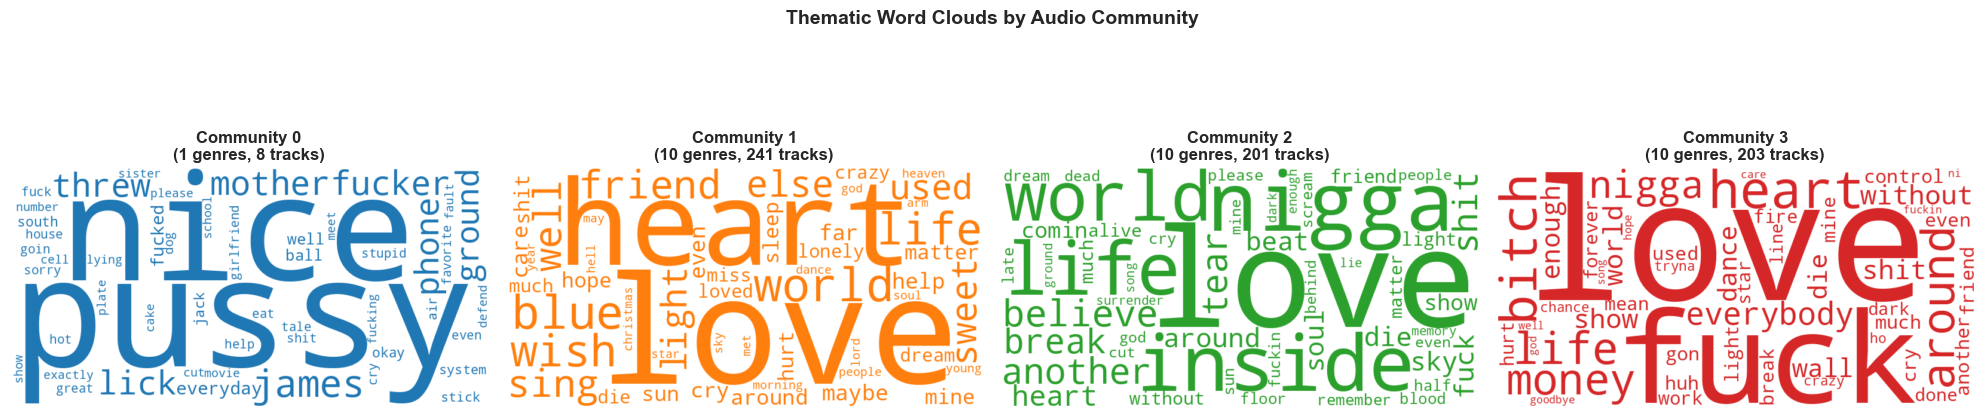

Saved to data/text_analysis_output/wordclouds_community.png


In [ ]:
# Generate community word clouds
fig, axes = plt.subplots(1, n_comms_wc, figsize=(5 * n_comms_wc, 5))
if n_comms_wc == 1:
    axes = [axes]

for i, cid in enumerate(communities_in_data):
    comm_vector = get_community_tfidf_aggregated(df_lyrics, tfidf_matrix, cid)

    if comm_vector is None:
        axes[i].text(0.5, 0.5, "No data", ha="center", va="center")
        axes[i].set_title(f"Community {cid}")
        axes[i].axis("off")
        continue

    top_terms = get_top_terms_from_vector(
        comm_vector, feature_names, top_n=WORDCLOUD_MAX_WORDS
    )
    color = COMMUNITY_COLOR_HEX.get(cid, "#333333")
    wc = create_wordcloud(top_terms, color, max_words=WORDCLOUD_MAX_WORDS)

    axes[i].imshow(wc, interpolation="bilinear")
    n_tracks = (df_lyrics["community_id"] == cid).sum()
    n_genres = df_lyrics[df_lyrics["community_id"] == cid]["genre"].nunique()
    axes[i].set_title(
        f"Community {cid}\n({n_genres} genres, {n_tracks} tracks)",
        fontsize=12,
        fontweight="bold",
    )
    axes[i].axis("off")

plt.suptitle(
    "Thematic Word Clouds by Audio Community", fontsize=14, fontweight="bold", y=1.02
)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "wordclouds_community.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Saved to {OUTPUT_DIR / 'wordclouds_community.png'}")

#### 5.1.3 Top Terms by Community

A cleaner comparison showing the top 10 words per community side-by-side. This visualization makes it easier to compare the relative TF-IDF weights across communities and identify which terms are shared versus unique.


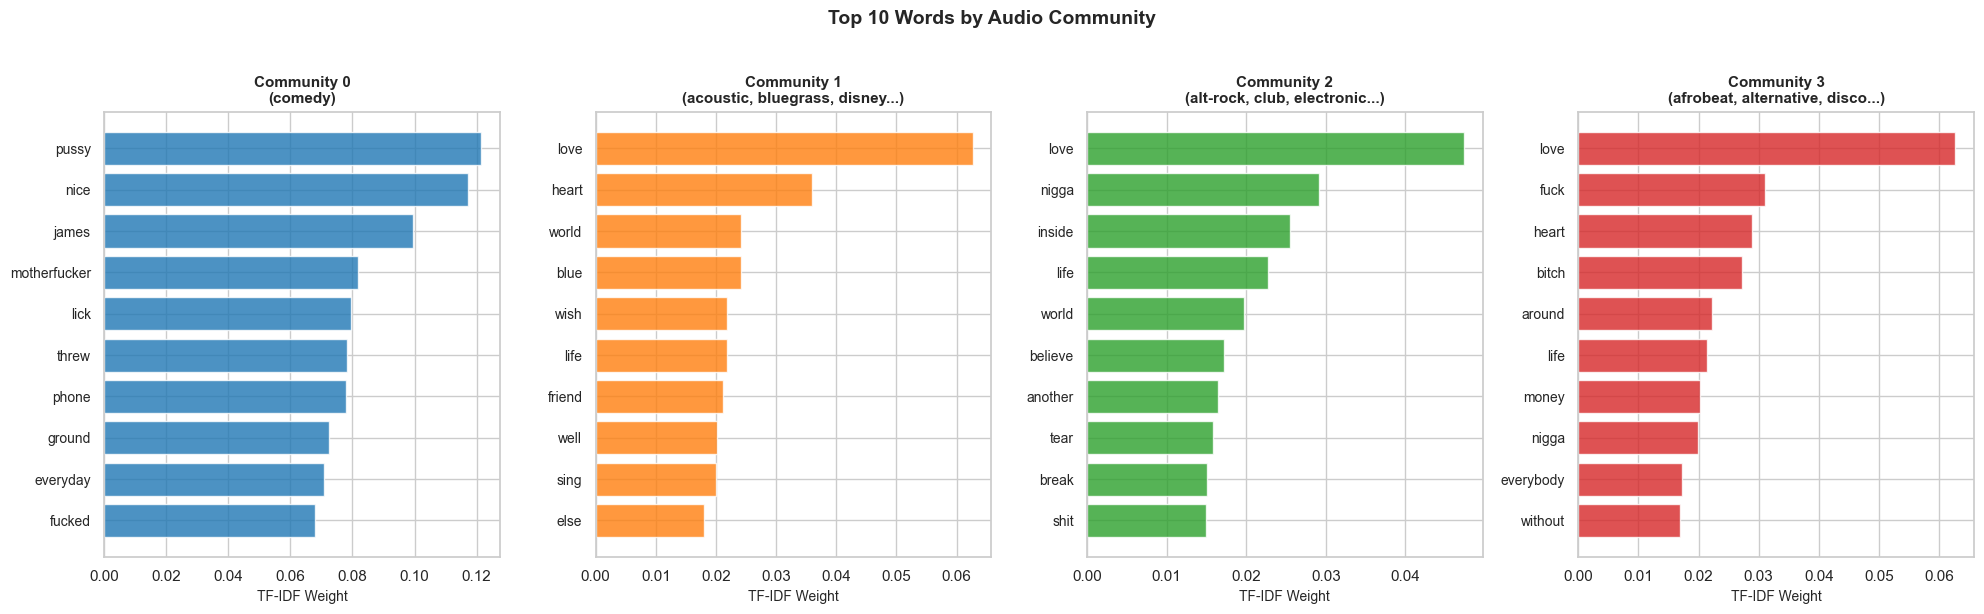


Saved to data/text_analysis_output/top_words_by_community.png


In [ ]:
# Create a side-by-side bar chart showing top 10 words per community
TOP_N_WORDS = 10

fig, axes = plt.subplots(1, n_comms_wc, figsize=(5 * n_comms_wc, 6), sharey=False)

if n_comms_wc == 1:
    axes = [axes]

for i, cid in enumerate(communities_in_data):
    ax = axes[i]

    # Get aggregated TF-IDF for community
    comm_vector = get_community_tfidf_aggregated(df_lyrics, tfidf_matrix, cid)

    if comm_vector is None:
        ax.text(0.5, 0.5, "No data", ha="center", va="center")
        ax.set_title(f"Community {cid}")
        continue

    # Get top terms
    top_terms = get_top_terms_from_vector(comm_vector, feature_names, top_n=TOP_N_WORDS)

    # Create horizontal bar chart
    words = list(top_terms.keys())
    weights = list(top_terms.values())

    # Reverse for top-to-bottom ordering
    words = words[::-1]
    weights = weights[::-1]

    color = COMMUNITY_COLOR_MAP[cid]
    ax.barh(words, weights, color=color, alpha=0.8)

    # Get genres in community for subtitle
    genres_in_comm = df_lyrics[df_lyrics["community_id"] == cid]["genre"].unique()
    genre_str = ", ".join(sorted(genres_in_comm)[:3]) + (
        "..." if len(genres_in_comm) > 3 else ""
    )

    ax.set_xlabel("TF-IDF Weight", fontsize=10)
    ax.set_title(f"Community {cid}\n({genre_str})", fontsize=11, fontweight="bold")
    ax.tick_params(axis="y", labelsize=10)

plt.suptitle(
    f"Top {TOP_N_WORDS} Words by Audio Community",
    fontsize=14,
    fontweight="bold",
    y=1.02,
)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "top_words_by_community.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\nSaved to {OUTPUT_DIR / 'top_words_by_community.png'}")

## 6. Sentiment Analysis

We analyze the **emotional tone** of lyrics using VADER (Valence Aware Dictionary and sEntiment Reasoner) sentiment analysis. VADER is specifically designed for social media and informal text, making it well-suited for song lyrics which often contain slang, emoticons, and non-standard grammar.

VADER produces a **compound score** ranging from -1 (most negative) to +1 (most positive), providing a single measure of overall sentiment polarity.

**What to look for:**

- Do audio communities differ in overall sentiment (positive vs. negative)?
- Which genres are most positive/negative?
- Does sentiment align with genre stereotypes (e.g., is punk more negative than jazz)?
- Do genres within the same audio community cluster together in sentiment?


### 7.1 Sentiment Analysis with VADER


In [50]:
nltk.download("vader_lexicon", quiet=True)
sia = SentimentIntensityAnalyzer()
print("VADER sentiment analyzer loaded")

VADER sentiment analyzer loaded


In [51]:
def get_sentiment(text):
    if pd.isna(text) or not text:
        return 0.0
    return sia.polarity_scores(text)["compound"]


df_lyrics["sentiment"] = df_lyrics["lyrics"].apply(get_sentiment)

print(f"Sentiment computed for {len(df_lyrics)} tracks")
print(f"  Mean: {df_lyrics['sentiment'].mean():.3f}")
print(
    f"  Range: [{df_lyrics['sentiment'].min():.3f}, {df_lyrics['sentiment'].max():.3f}]"
)

Sentiment computed for 653 tracks
  Mean: 0.172
  Range: [-1.000, 1.000]


### 6.2 Sentiment by Community

Box plots show the distribution of sentiment scores within each audio community.

**Key Observations:**

- **High variance within all communities**: All communities exhibit sentiment spanning the full [-1, +1] range, indicating that sentiment varies substantially even among sonically similar genres.

- **Community 1 skews more positive**: Its median and lower quartile exceed those of other communities, suggesting genres in this cluster tend toward more optimistic or uplifting lyrical content.

- **Genre-level patterns**: When examining individual genres:

  - **Jazz** emerges as most positive (mean ≈ 0.79)
  - **Punk** is the only genre with negative mean sentiment (-0.13)
  - **Metal** and **hip-hop** hover near neutral
  - **Rock** and **house** tend positive

- **Intra-community clustering**: Genres within the same audio community tend to cluster in sentiment, suggesting that sonic similarity correlates not just with shared themes, but with **shared emotional expression**.


Saved to data/text_analysis_output/sentiment_by_community.png

Sentiment by community:
  Community 0: mean=0.311, std=0.927
  Community 1: mean=0.289, std=0.835
  Community 2: mean=0.021, std=0.877
  Community 3: mean=0.178, std=0.889


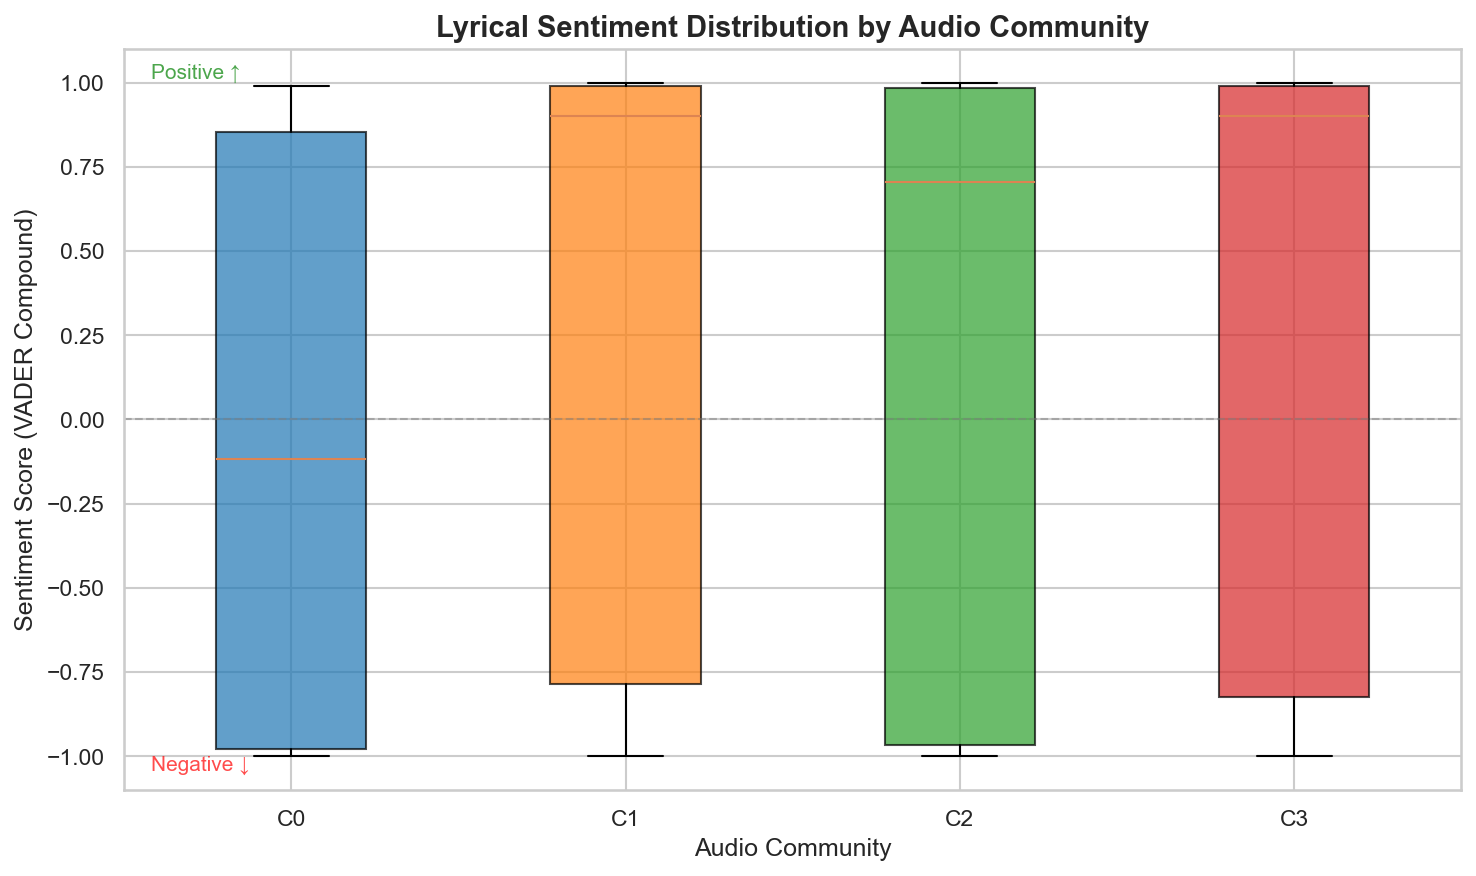

In [65]:
fig, ax = plt.subplots(figsize=(10, 6))

communities_sorted = sorted(df_lyrics["community_id"].unique())

bp = ax.boxplot(
    [
        df_lyrics[df_lyrics["community_id"] == cid]["sentiment"].values
        for cid in communities_sorted
    ],
    labels=[f"C{cid}" for cid in communities_sorted],
    patch_artist=True,
)

for i, cid in enumerate(communities_sorted):
    bp["boxes"][i].set_facecolor(COMMUNITY_COLOR_MAP[cid])
    bp["boxes"][i].set_alpha(0.7)

ax.axhline(y=0, color="gray", linestyle="--", linewidth=1, alpha=0.5)
ax.set_xlabel("Audio Community", fontsize=12)
ax.set_ylabel("Sentiment Score (VADER)", fontsize=12)
ax.set_title("Lyrical Sentiment by Audio Community", fontsize=14, fontweight="bold")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "sentiment_by_community.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Saved to {OUTPUT_DIR / 'sentiment_by_community.png'}")

# Summary
print("\nSentiment by community:")
for cid in communities_sorted:
    comm_sent = df_lyrics[df_lyrics["community_id"] == cid]["sentiment"]
    print(f"  Community {cid}: mean={comm_sent.mean():.3f}, std={comm_sent.std():.3f}")

## 7. Summary

### Text Analysis Pipeline

| Step            | Output                                                     |
| --------------- | ---------------------------------------------------------- |
| Sampling        | 10 genres × 4 communities × 50 tracks = up to 2,000 tracks |
| After filtering | 656 tracks with valid English lyrics                       |
| TF-IDF          | Unigram vectors with custom stopwords                      |
| Sentiment       | VADER compound scores per track                            |

### Key Findings

Our text analysis reveals a **nuanced answer** to whether sonic similarity implies thematic similarity:

1. **Universal themes, different framing**: Love permeates all communities, but the emotional framing differs. Some genre clusters approach love through positive, aspirational language, while others adopt angrier or more explicit tones.

2. **Sentiment clusters by audio similarity**: Genres within the same audio community tend to share not just vocabulary but emotional valence, suggesting that our audio-based clustering captures meaningful semantic structure.

3. **Beyond topics to tone**: Audio communities may reflect not just _what_ songs discuss, but _how_ they discuss it. This has implications for music recommendation systems that rely solely on genre labels or audio features.

### Implications

These findings suggest that network-based representations of music can improve the interpretability of recommendation systems. By combining audio similarity with lyrical analysis, we gain insight into how musical style, sound, and language interact.

### Future Work

- Filter out dominant themes (e.g., love) to uncover secondary thematic patterns
- Analyze temporal trends in lyrical themes within communities
- Expand to multilingual lyrics with appropriate NLP tools


In [67]:
print("Text Analysis Summary")
print()

print("Configuration:")
print(f"  Random seed: {RANDOM_SEED}")
print(f"  Genres per community: {N_GENRES_PER_COMMUNITY}")
print(f"  Songs per genre: {SONGS_PER_GENRE}")
print(f"  Min tracks threshold: {MIN_TRACKS_PER_GENRE}")
print(f"  Max instrumentalness: {MAX_INSTRUMENTALNESS}")
print()

print("Data:")
print(f"  Total genres in dataset: {len(genres_all)}")
print(f"  Genres excluded: {len(df_filtered)}")
print(f"  Genres with lyrics: {len(genres_with_lyrics)}")
print(f"  Tracks with lyrics: {len(df_lyrics)}")
print(f"  TF-IDF vocabulary: {len(feature_names)} words")
print()

print("Stopwords:")
print(f"  NLTK: {len(NLTK_STOPWORDS)}")
print(f"  Custom: {len(CUSTOM_STOPWORDS)}")
print(f"  Total: {len(ALL_STOPWORDS)}")
print()

print("Audio communities:")
print(f"  Source: {GEXF_PATH}")
print(f"  Number: {len(genre_comms)}")
print()


print("Sentiment:")
print(f"  Mean: {df_lyrics['sentiment'].mean():.3f}")
print(
    f"  Range: [{df_lyrics['sentiment'].min():.3f}, {df_lyrics['sentiment'].max():.3f}]"
)
print()

print("Outputs:")
print(f"  {OUTPUT_DIR / 'wordclouds_community.png'}")
print(f"  {OUTPUT_DIR / 'top_words_by_community.png'}")
print(f"  {OUTPUT_DIR / 'sentiment_by_community.png'}")
print(f"  {OUTPUT_DIR / 'sentiment_by_genre.png'}")
print(f"  {OUTPUT_DIR / 'all_lyrics.csv'}")

Text Analysis Summary

Configuration:
  Random seed: 42
  Genres per community: 10
  Songs per genre: 50
  Min tracks threshold: 50
  Max instrumentalness: 0.6

Data:
  Total genres in dataset: 114
  Genres excluded: 35
  Genres with lyrics: 31
  Tracks with lyrics: 653
  TF-IDF vocabulary: 1237 words

Stopwords:
  NLTK: 198
  Custom: 350
  Total: 545

Audio communities:
  Source: data/spotify_genre_similarity_audio.gexf
  Number: 4

Sentiment:
  Mean: 0.172
  Range: [-1.000, 1.000]

Outputs:
  data/text_analysis_output/wordclouds_community.png
  data/text_analysis_output/top_words_by_community.png
  data/text_analysis_output/sentiment_by_community.png
  data/text_analysis_output/sentiment_by_genre.png
  data/text_analysis_output/all_lyrics.csv


In [ ]:
# Save top terms per genre
top_terms_df = []
for i, genre in enumerate(genres_with_lyrics):
    top_terms = get_top_terms_for_genre(i, top_n=15)
    comm_id = comm_map_audio.get(genre, -1)
    for term, weight in top_terms:
        top_terms_df.append(
            {
                "genre": genre,
                "community_id": comm_id,
                "term": term,
                "tfidf_weight": weight,
            }
        )

pd.DataFrame(top_terms_df).to_csv(OUTPUT_DIR / "genre_top_tfidf_terms.csv", index=False)
print(f"Saved to {OUTPUT_DIR / 'genre_top_tfidf_terms.csv'}")

Saved to data/text_analysis_output/genre_top_tfidf_terms.csv


In [ ]:
# Save lyrics with sentiment
df_lyrics.to_csv(OUTPUT_DIR / "all_lyrics_with_sentiment.csv", index=False)
print(f"Saved to {OUTPUT_DIR / 'all_lyrics_with_sentiment.csv'}")

# Genre sentiment summary
genre_sent_summary = (
    df_lyrics.groupby("genre")
    .agg({"sentiment": ["mean", "std", "count"], "community_id": "first"})
    .round(3)
)
genre_sent_summary.columns = [
    "sentiment_mean",
    "sentiment_std",
    "n_tracks",
    "community_id",
]
genre_sent_summary = genre_sent_summary.sort_values("sentiment_mean", ascending=False)
genre_sent_summary.to_csv(OUTPUT_DIR / "genre_sentiment_summary.csv")
print(f"Saved to {OUTPUT_DIR / 'genre_sentiment_summary.csv'}")

Saved to data/text_analysis_output/all_lyrics_with_sentiment.csv
Saved to data/text_analysis_output/genre_sentiment_summary.csv


# References

- NetworkX (Spring, Kamada-Kawai, Circular, Random), for standard layouts for the visualizations
- Fruchterman, T. M. J., & Reingold, E. M. (1991). Graph drawing by force-directed placement. Software: Practice and Experience, 21(11), 1129–1164, for Spring layout
- Kamada, T., & Kawai, S. (1989). An algorithm for drawing general undirected graphs. Information Processing Letters, 31(1), 7–15, for Kamada-Kawai layout
- Newman, M. E. J. (2010). Networks: An Introduction. Oxford University Press. (Ch. 7 covers visualization basics), for general background on network visualizations
- Garlaschelli, D., & Loffredo, M. I. (2004). Patterns of link reciprocity in directed networks. Physical Review Letters, 93(26), 268701, for reciprocity analysis.
- Capocci, A., Servedio, V. D. P., Colaiori, F., Buriol, L. S., Donato, D., Leonardi, S., & Caldarelli, G. (2006). Preferential attachment in the growth of social networks: The internet encyclopedia Wikipedia. Physical Review E, 74(3), 036116, for preferential attachment and Wikipedia networks.
- Jackson, M. O. (2008). Social and economic networks. Princeton University Press, for general theory of network structure and dynamics.
